# **LOAD DATASET**

In [ ]:
# Install Kaggle CLI
!pip install -q kaggle

# Upload your kaggle.json file (API key)
from google.colab import files
files.upload()  # Upload kaggle.json here

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d solarmainframe/ids-intrusion-csv

# Unzip into /content folder
!unzip -q ids-intrusion-csv.zip -d /content/ids_dataset

# Verify files
import os
print("Files in dataset folder:")
print(os.listdir("/content/ids_dataset"))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.60G/1.60G [00:10<00:00, 165MB/s]

Files in dataset folder:
['02-16-2018.csv', '02-22-2018.csv', '02-23-2018.csv', '03-02-2018.csv', '02-28-2018.csv', '02-14-2018.csv', '02-20-2018.csv', '02-21-2018.csv', '02-15-2018.csv', '03-01-2018.csv']


# **DATA - ANALYSIS ( EDA )**

Processing 02-22-2018.csv...
Processing 02-14-2018.csv...
Processing 02-23-2018.csv...
Processing 03-02-2018.csv...
Processing 02-21-2018.csv...
Processing 02-15-2018.csv...
Processing 03-01-2018.csv...
Processing 02-20-2018.csv...
Processing 02-28-2018.csv...
Processing 02-16-2018.csv...

Attack Distribution:

Benign                      13390249
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193354
SSH-Bruteforce                187589
Infilteration                 160639
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64


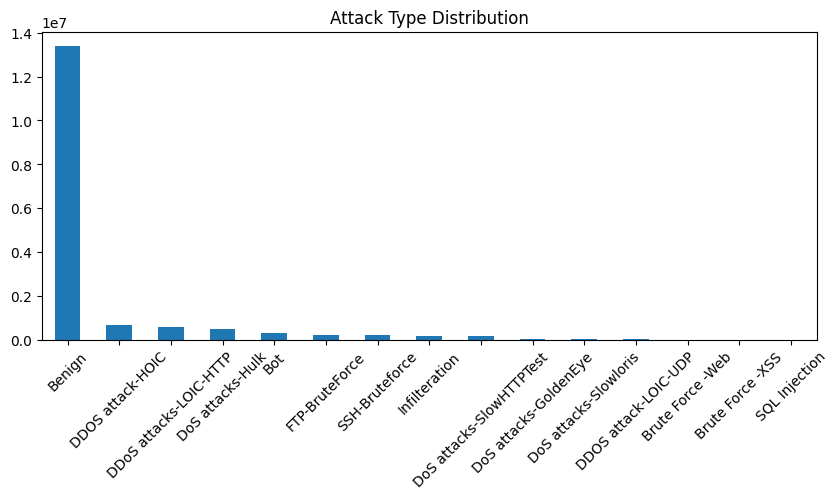


--- Attack Statistics ---

Flow Duration
Mean: 3770292.5786476852
Std: 13428479.674179569
Min: 1.0
Max: 119999998.0

Flow Byts/s
Mean: 35415.596589896115
Std: 831161.7953226507
Min: 0.0
Max: 274000000.0

Flow Pkts/s
Mean: 139218.77036936118
Std: 391340.6519678845
Min: 0.016812064
Max: 3000000.0


--- Mean Comparison ---

Flow Duration
Attack Mean: 3770292.5786476852
Benign Mean: 13548367.300710166

Flow Byts/s
Attack Mean: 35415.596589896115
Benign Mean: 302498.8410208446

Flow Pkts/s
Attack Mean: 139218.77036936118
Benign Mean: 34465.46793597672



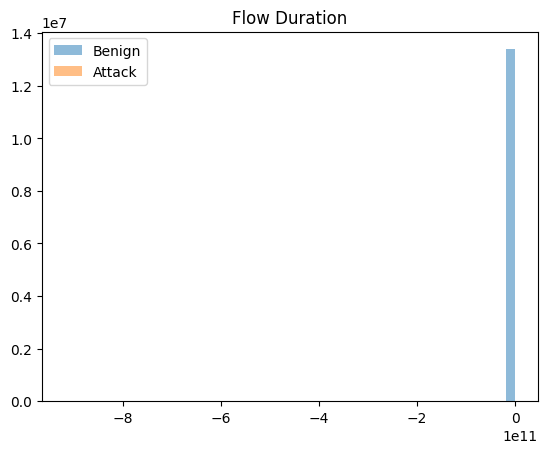

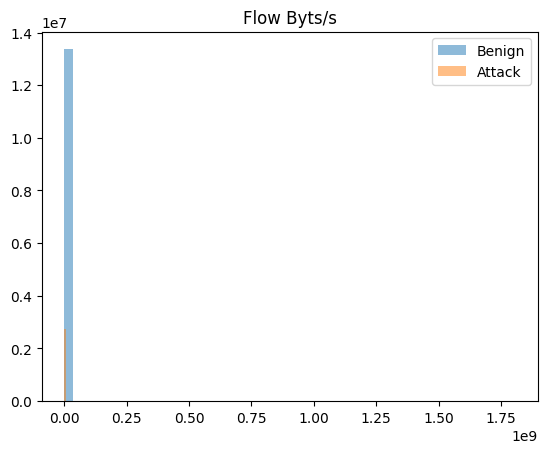

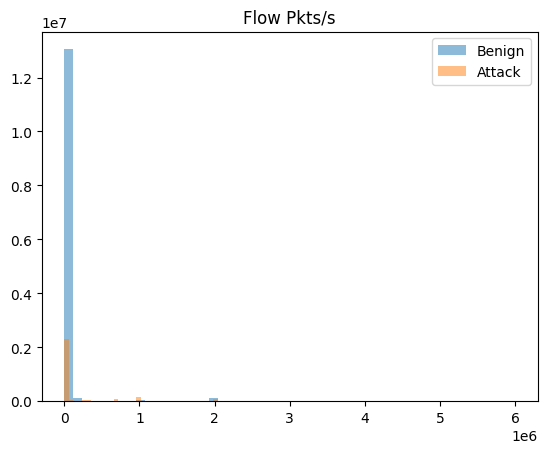


--- T-Test Results ---

Flow Duration: p-value = 0.0
Significant difference

Flow Byts/s: p-value = 0.0
Significant difference

Flow Pkts/s: p-value = 0.0
Significant difference


--- Outliers in Attack Traffic ---

Flow Duration: 627950 outliers
Flow Byts/s: 492848 outliers
Flow Pkts/s: 475173 outliers


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import os

# -----------------------------
# CONFIG
# -----------------------------
data_path = "/content/ids_dataset"
files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

CHUNK_SIZE = 50000

cols_needed = [
    "Label",
    "Flow Duration",
    "Flow Byts/s",
    "Flow Pkts/s"
]

# -----------------------------
# STORAGE
# -----------------------------
all_labels = []
attack_vals = {col: [] for col in cols_needed[1:]}
benign_vals = {col: [] for col in cols_needed[1:]}

# -----------------------------
# PROCESS DATA
# -----------------------------
for file in files:
    print(f"Processing {file}...")

    for chunk in pd.read_csv(
        os.path.join(data_path, file),
        usecols=cols_needed,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ):
        chunk.columns = chunk.columns.str.strip()

        # 🔥 FIX: convert to numeric safely
        for col in cols_needed[1:]:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(inplace=True)

        # Store labels
        all_labels.extend(chunk["Label"].values)

        attack_chunk = chunk[chunk["Label"] != "Benign"]
        benign_chunk = chunk[chunk["Label"] == "Benign"]

        for col in cols_needed[1:]:
            attack_vals[col].extend(attack_chunk[col].values)
            benign_vals[col].extend(benign_chunk[col].values)

# Convert to numpy
for col in cols_needed[1:]:
    attack_vals[col] = np.array(attack_vals[col], dtype=np.float64)
    benign_vals[col] = np.array(benign_vals[col], dtype=np.float64)

# -----------------------------
# ATTACK DISTRIBUTION
# -----------------------------
labels_series = pd.Series(all_labels)

print("\nAttack Distribution:\n")
print(labels_series.value_counts())

plt.figure(figsize=(10,4))
labels_series.value_counts().plot(kind='bar')
plt.title("Attack Type Distribution")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# DESCRIPTIVE STATS
# -----------------------------
print("\n--- Attack Statistics ---\n")

for col in cols_needed[1:]:
    data = attack_vals[col]

    print(f"{col}")
    print("Mean:", np.mean(data))
    print("Std:", np.std(data))
    print("Min:", np.min(data))
    print("Max:", np.max(data))
    print()

# -----------------------------
# MEAN COMPARISON
# -----------------------------
print("\n--- Mean Comparison ---\n")

for col in cols_needed[1:]:
    print(f"{col}")
    print("Attack Mean:", np.mean(attack_vals[col]))
    print("Benign Mean:", np.mean(benign_vals[col]))
    print()

# -----------------------------
# VISUAL COMPARISON
# -----------------------------
for col in cols_needed[1:]:
    plt.figure()

    plt.hist(benign_vals[col], bins=50, alpha=0.5, label="Benign")
    plt.hist(attack_vals[col], bins=50, alpha=0.5, label="Attack")

    plt.legend()
    plt.title(col)
    plt.show()

# -----------------------------
# T-TEST
# -----------------------------
print("\n--- T-Test Results ---\n")

for col in cols_needed[1:]:
    stat, p = ttest_ind(attack_vals[col], benign_vals[col], equal_var=False)

    print(f"{col}: p-value = {p}")

    if p < 0.05:
        print("Significant difference\n")
    else:
        print("Not significant\n")

# -----------------------------
# OUTLIERS
# -----------------------------
print("\n--- Outliers in Attack Traffic ---\n")

for col in cols_needed[1:]:
    data = attack_vals[col]

    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]

    print(f"{col}: {len(outliers)} outliers")

## **TYPES OF ATTACKS - DATA DISTRIBUTION**

Processing 02-22-2018.csv...
Processing 02-14-2018.csv...
Processing 02-23-2018.csv...
Processing 03-02-2018.csv...
Processing 02-21-2018.csv...
Processing 02-15-2018.csv...
Processing 03-01-2018.csv...
Processing 02-20-2018.csv...
Processing 02-28-2018.csv...
Processing 02-16-2018.csv...

Final Shape: (16233002, 1)

Total Attack Types: 16

Attack Types:
Benign
Brute Force -Web
Brute Force -XSS
SQL Injection
FTP-BruteForce
SSH-Bruteforce
Bot
DDOS attack-LOIC-UDP
DDOS attack-HOIC
DoS attacks-GoldenEye
DoS attacks-Slowloris
Label
Infilteration
DDoS attacks-LOIC-HTTP
DoS attacks-SlowHTTPTest
DoS attacks-Hulk

--- Attack Type Distribution ---
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-Go

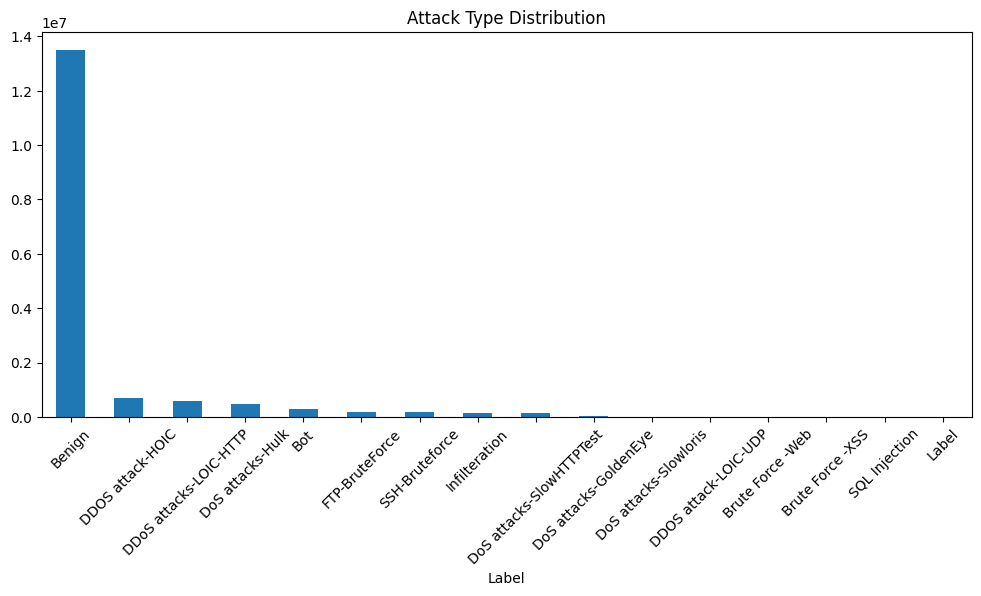

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

data_path = "/content/ids_dataset"
files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

chunks = []

for file in files:
    print(f"Processing {file}...")

    for chunk in pd.read_csv(
        os.path.join(data_path, file),
        usecols=["Label"],        # 🔥 ONLY load Label
        chunksize=100000
    ):
        chunk.columns = chunk.columns.str.strip()

        # Drop only rows where Label is missing
        chunk = chunk.dropna(subset=["Label"])

        chunks.append(chunk)

# Combine
df = pd.concat(chunks, ignore_index=True)

print("\nFinal Shape:", df.shape)

# -----------------------------
# Attack Types
# -----------------------------
attack_types = df['Label'].unique()

print("\nTotal Attack Types:", len(attack_types))
print("\nAttack Types:")
for a in attack_types:
    print(a)

# -----------------------------
# Distribution
# -----------------------------
counts = df['Label'].value_counts()

print("\n--- Attack Type Distribution ---")
print(counts)

# -----------------------------
# Plot (safe)
# -----------------------------
if len(counts) > 0:
    plt.figure(figsize=(12,5))
    counts.plot(kind='bar')
    plt.title("Attack Type Distribution")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No data to plot")

# **DATA CLEANING AND PREPROCESSING**

combining the dataset to a single csv file The final file is saved as /content/cleaned_ids_dataset.csv and the cell prints a full before vs after summary table + two bar charts for visual comparison.

📂  Found 10 CSV files

📌  Columns detected: 80

⏳  PASS 1: Before-stats + quantile samples
   Scanning 02-14-2018.csv...
   Scanning 02-15-2018.csv...
   Scanning 02-16-2018.csv...
   Scanning 02-20-2018.csv...
   Scanning 02-21-2018.csv...
   Scanning 02-22-2018.csv...
   Scanning 02-23-2018.csv...
   Scanning 02-28-2018.csv...
   Scanning 03-01-2018.csv...
   Scanning 03-02-2018.csv...

   Sample rows collected: 50,000
   Cols to remove  : 14 → ['Timestamp', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Flow ID', 'Src IP', 'Dst IP']
   Winsor bounds   : 69 numeric columns
   Cols to keep    : 69

📊  DATA BEFORE CLEANING
  Shape          : 16,233,002 rows × 80 cols
  Missing values : 59,721
  Inf values     : 125,118
  Duplicate rows : 374,876  (within-chunk estimate)

  Top missing-value columns:
    Flow Byts/s: 59,721

  Label distribution (before)

,Count
Benign,13484708
DDOS attack-HOIC,686012
DDoS attacks-LOIC-HTTP,576191
DoS attacks-Hulk,461912
Bot,286191
FTP-BruteForce,193360
SSH-Bruteforce,187589
Infilteration,161934
DoS attacks-SlowHTTPTest,139890
DoS attacks-GoldenEye,41508



  First 2 raw rows:


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0,0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0,0,0,0,56320733.0,114.551299,56320814,56320652,Benign


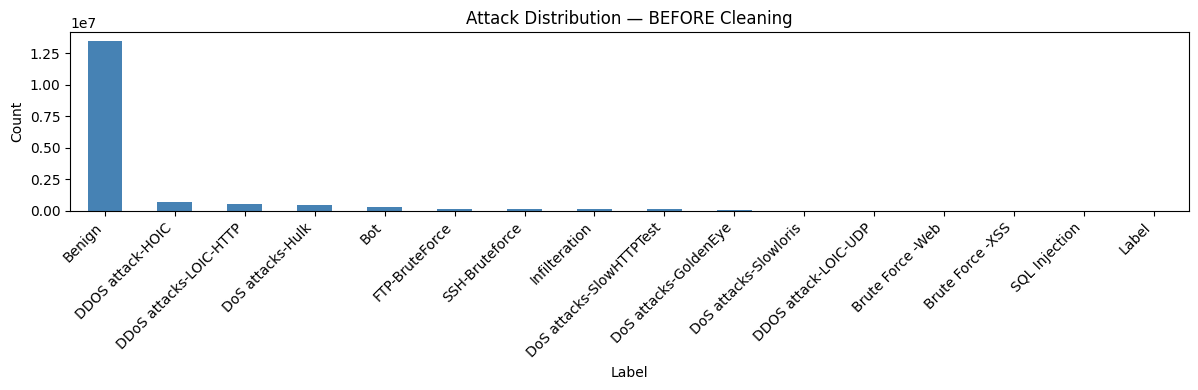


🧹  PASS 2: Clean → write → collect after-stats
   Cleaning 02-14-2018.csv...
   ✔  1/10 files processed
   Cleaning 02-15-2018.csv...
   ✔  2/10 files processed
   Cleaning 02-16-2018.csv...
   ✔  3/10 files processed
   Cleaning 02-20-2018.csv...
   ✔  4/10 files processed
   Cleaning 02-21-2018.csv...
   ✔  5/10 files processed
   Cleaning 02-22-2018.csv...
   ✔  6/10 files processed
   Cleaning 02-23-2018.csv...
   ✔  7/10 files processed
   Cleaning 02-28-2018.csv...
   ✔  8/10 files processed
   Cleaning 03-01-2018.csv...
   ✔  9/10 files processed
   Cleaning 03-02-2018.csv...
   ✔  10/10 files processed

   ✅  All chunks cleaned and written.

📊  DATA AFTER CLEANING
  Shape          : 14,826,383 rows × 69 cols
  Missing values : 0  (all NaN rows dropped)
  Inf values     : 0  (all Inf→NaN then dropped)
  Duplicate rows : 0  (within-chunk dedup applied)

  Label distribution (after):


,Count
Benign,12884988
DDoS attacks-LOIC-HTTP,576135
DDOS attack-HOIC,502409
DoS attacks-Hulk,400470
Bot,157983
Infilteration,154959
SSH-Bruteforce,94485
DoS attacks-GoldenEye,41439
DoS attacks-Slowloris,9801
DDOS attack-LOIC-UDP,1730



  First 3 cleaned rows:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.0,6.0,17022094.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,0.0,6.0,17022094.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,0.0,6.0,17022094.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


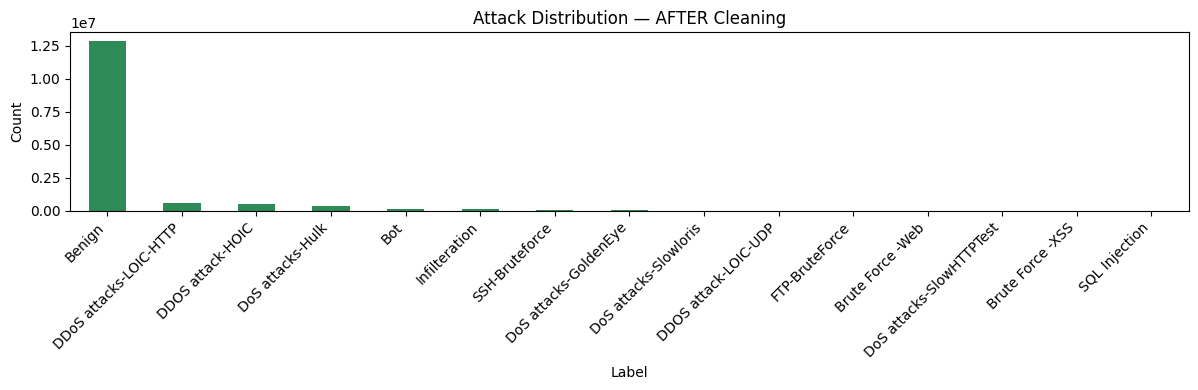


📋  BEFORE vs AFTER SUMMARY


,Metric,Before Cleaning,After Cleaning
0,Total Rows,"16,233,002","14,826,383"
1,Total Columns,80,69
2,Missing Values,"59,721",0
3,Inf Values,"125,118",0
4,Duplicate Rows,"374,876",0
5,Cols Removed (zero-var / non-numeric),—,14
6,Outliers Winsorised (IQR × 3),—,"113,727,609"
7,Rows Dropped — missing Label,—,59
8,Rows Dropped — NaN / Inf,—,"95,760"
9,Rows Dropped — duplicates,—,"1,310,800"



💾  Saved  →  /content/cleaned_ids_dataset.csv
    File size : 5455.13 MB
    Rows      : 14,826,383
    Columns   : 69

🎉  Done!


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  MEMORY-EFFICIENT PREPROCESSING — GOOGLE COLAB FREE TIER
#  2-pass streaming (Pass 3 eliminated — after-stats collected in Pass 2)
#  usecols: zero-var cols never loaded from disk
#  float32: numeric memory halved vs float64
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────
DATA_PATH       = "/content/ids_dataset"
OUTPUT_PATH     = "/content/cleaned_ids_dataset.csv"
CHUNK_SIZE      = 15_000   # conservative — ~6 MB per chunk at float32
MAX_SAMPLE_ROWS = 50_000   # enough for stable quantiles

files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith(".csv")])
print(f"📂  Found {len(files)} CSV files\n")

# ── PASS 0: Probe column names ────────────────────────────────────────────
probe = pd.read_csv(os.path.join(DATA_PATH, files[0]), nrows=1, low_memory=False)
probe.columns = probe.columns.str.strip()
ALL_COLS = probe.columns.tolist()
print(f"📌  Columns detected: {len(ALL_COLS)}")
del probe; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  PASS 1 — BEFORE STATS + QUANTILE SAMPLES
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("⏳  PASS 1: Before-stats + quantile samples")
print("="*60)

before_rows      = 0
before_miss_tot  = 0
before_inf_tot   = 0
before_dup_tot   = 0
missing_per_col  = defaultdict(int)
before_labels    = defaultdict(int)
sample_list      = []
sample_collected = 0
first_2_raw      = None

for file in files:
    print(f"   Scanning {file}...")
    for chunk in pd.read_csv(
        os.path.join(DATA_PATH, file),
        chunksize=CHUNK_SIZE,
        low_memory=False,
        on_bad_lines='skip'
    ):
        chunk.columns = chunk.columns.str.strip()

        if first_2_raw is None:
            first_2_raw = chunk.head(2).copy()

        before_rows += len(chunk)

        miss = chunk.isnull().sum()
        before_miss_tot += int(miss.sum())
        for col, v in miss.items():
            missing_per_col[col] += int(v)

        num = chunk.select_dtypes(include=[np.number])
        before_inf_tot += int(np.isinf(num.values).sum())
        del num

        before_dup_tot += int(chunk.duplicated().sum())

        if "Label" in chunk.columns:
            for lbl, cnt in chunk["Label"].astype(str).str.strip().value_counts().items():
                before_labels[lbl] += int(cnt)

        # collect small sample per chunk, stop early once quota reached
        if sample_collected < MAX_SAMPLE_ROWS:
            n = min(200, len(chunk))
            sample_list.append(chunk.sample(n=n, random_state=42))
            sample_collected += n

        del chunk; gc.collect()

print(f"\n   Sample rows collected: {sample_collected:,}")

# ── Quantile bounds + zero-var detection ──────────────────────────────────
sample_df = pd.concat(sample_list, ignore_index=True)
del sample_list; gc.collect()

# coerce sample to numeric for analysis
for col in sample_df.columns:
    if col != "Label":
        sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')
sample_df.replace([np.inf, -np.inf], np.nan, inplace=True)

winsor_bounds = {}
zero_var_cols = []

# flag numeric cols with zero/no variance
for col in sample_df.select_dtypes(include=[np.number]).columns:
    vals = sample_df[col].dropna()
    if len(vals) == 0 or vals.nunique() <= 1:
        zero_var_cols.append(col)
        continue
    Q1  = float(vals.quantile(0.25))
    Q3  = float(vals.quantile(0.75))
    IQR = Q3 - Q1
    winsor_bounds[col] = (Q1 - 3 * IQR, Q3 + 3 * IQR)

# flag all non-Label object cols (Src IP, Dst IP, Timestamp, Flow ID …)
for col in sample_df.select_dtypes(include='object').columns:
    if col != "Label" and col not in zero_var_cols:
        zero_var_cols.append(col)

del sample_df; gc.collect()

print(f"   Cols to remove  : {len(zero_var_cols)} → {zero_var_cols}")
print(f"   Winsor bounds   : {len(winsor_bounds)} numeric columns")

# ── Build usecols list for Pass 2 (never load dropped cols from disk) ─────
cols_to_keep = [c for c in ALL_COLS if c not in zero_var_cols]
print(f"   Cols to keep    : {len(cols_to_keep)}")

# ── Print BEFORE stats ────────────────────────────────────────────────────
before_label_series = pd.Series(before_labels).sort_values(ascending=False)

print("\n" + "="*60)
print("📊  DATA BEFORE CLEANING")
print("="*60)
print(f"  Shape          : {before_rows:,} rows × {len(ALL_COLS)} cols")
print(f"  Missing values : {before_miss_tot:,}")
print(f"  Inf values     : {before_inf_tot:,}")
print(f"  Duplicate rows : {before_dup_tot:,}  (within-chunk estimate)")

top_missing = {c: v for c, v in
               sorted(missing_per_col.items(), key=lambda x: -x[1])[:8] if v > 0}
if top_missing:
    print(f"\n  Top missing-value columns:")
    for col, v in top_missing.items():
        print(f"    {col}: {v:,}")

print(f"\n  Label distribution (before):")
display(before_label_series.rename("Count").to_frame())

print(f"\n  First 2 raw rows:")
display(first_2_raw)

fig, ax = plt.subplots(figsize=(12, 4))
before_label_series.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Attack Distribution — BEFORE Cleaning")
ax.set_xlabel("Label"); ax.set_ylabel("Count")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

del first_2_raw, before_label_series; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  PASS 2 — CLEAN + WRITE + COLLECT AFTER-STATS (no Pass 3 needed)
#
#  Memory savings vs previous version:
#   • usecols=cols_to_keep  → zero-var cols never loaded from disk
#   • float32 cast          → numeric memory halved
#   • after-stats collected here → no third read of output file
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🧹  PASS 2: Clean → write → collect after-stats")
print("="*60)

after_rows            = 0
after_labels          = defaultdict(int)
clipped_total         = 0
dropped_missing_label = 0
dropped_nan_inf       = 0
dropped_duplicates    = 0
header_written        = False
first_3_clean         = None
files_done            = 0

for file in files:
    print(f"   Cleaning {file}...")
    for chunk in pd.read_csv(
        os.path.join(DATA_PATH, file),
        usecols=cols_to_keep,          # ← never load zero-var cols
        chunksize=CHUNK_SIZE,
        low_memory=False,
        on_bad_lines='skip'
    ):
        # STEP 1 ─ Strip column names; sanitise Label only
        #          (other object cols already excluded via usecols)
        chunk.columns = chunk.columns.str.strip()
        chunk["Label"] = (chunk["Label"].astype(str)
                                        .str.strip()
                                        .str.replace(r'[\n\r,]', ' ', regex=True))

        # STEP 2 ─ Drop rows with missing / header-repeat Label
        n_before = len(chunk)
        mask = chunk["Label"].notna() & (chunk["Label"].str.lower() != "nan") \
                                      & (chunk["Label"].str.lower() != "label")
        chunk = chunk[mask]
        dropped_missing_label += n_before - len(chunk)
        if chunk.empty: del chunk; gc.collect(); continue

        # STEP 3 ─ Convert numeric cols → float32 (half the RAM of float64)
        for col in chunk.columns:
            if col != "Label":
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce').astype('float32')

        # STEP 4 ─ Replace ±Inf with NaN
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

        # STEP 5 ─ Drop NaN rows
        n_before = len(chunk)
        chunk.dropna(inplace=True)
        dropped_nan_inf += n_before - len(chunk)
        if chunk.empty: del chunk; gc.collect(); continue

        # STEP 6 ─ Drop within-chunk duplicates
        n_before = len(chunk)
        chunk.drop_duplicates(inplace=True)
        dropped_duplicates += n_before - len(chunk)
        if chunk.empty: del chunk; gc.collect(); continue

        # STEP 7 ─ Winsorise outliers (IQR × 3)
        for col in chunk.select_dtypes(include=[np.number]).columns:
            if col in winsor_bounds:
                lo, hi = winsor_bounds[col]
                clipped_total += int(((chunk[col] < lo) | (chunk[col] > hi)).sum())
                chunk[col] = chunk[col].clip(lower=lo, upper=hi)

        # ── Collect after-stats (replaces Pass 3) ────────────────────────
        after_rows += len(chunk)
        for lbl, cnt in chunk["Label"].value_counts().items():
            after_labels[lbl] += int(cnt)

        if first_3_clean is None:
            first_3_clean = chunk.head(3).copy()

        # ── Write with standard quoting (strings sanitised above) ────────
        chunk.to_csv(
            OUTPUT_PATH,
            mode='a' if header_written else 'w',
            header=not header_written,
            index=False,
            quoting=csv.QUOTE_MINIMAL   # smaller file, no parse ambiguity
        )                               # (commas already removed from strings)
        header_written = True

        del chunk; gc.collect()

    files_done += 1
    print(f"   ✔  {files_done}/{len(files)} files processed")

if not header_written:
    raise RuntimeError("⚠️  No rows survived cleaning — output file was NOT created.")

print(f"\n   ✅  All chunks cleaned and written.")

# ── Print AFTER stats (no file re-read needed) ────────────────────────────
after_label_series = pd.Series(after_labels).sort_values(ascending=False)
after_cols_count   = len(cols_to_keep)

print("\n" + "="*60)
print("📊  DATA AFTER CLEANING")
print("="*60)
print(f"  Shape          : {after_rows:,} rows × {after_cols_count} cols")
print(f"  Missing values : 0  (all NaN rows dropped)")
print(f"  Inf values     : 0  (all Inf→NaN then dropped)")
print(f"  Duplicate rows : 0  (within-chunk dedup applied)")

print(f"\n  Label distribution (after):")
display(after_label_series.rename("Count").to_frame())

print(f"\n  First 3 cleaned rows:")
display(first_3_clean)

fig, ax = plt.subplots(figsize=(12, 4))
after_label_series.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title("Attack Distribution — AFTER Cleaning")
ax.set_xlabel("Label"); ax.set_ylabel("Count")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# ── Before vs After summary ───────────────────────────────────────────────
print("\n" + "="*60)
print("📋  BEFORE vs AFTER SUMMARY")
print("="*60)

summary = pd.DataFrame({
    "Metric": [
        "Total Rows", "Total Columns",
        "Missing Values", "Inf Values", "Duplicate Rows",
        "Cols Removed (zero-var / non-numeric)",
        "Outliers Winsorised (IQR × 3)",
        "Rows Dropped — missing Label",
        "Rows Dropped — NaN / Inf",
        "Rows Dropped — duplicates",
    ],
    "Before Cleaning": [
        f"{before_rows:,}", f"{len(ALL_COLS)}",
        f"{before_miss_tot:,}", f"{before_inf_tot:,}", f"{before_dup_tot:,}",
        "—", "—", "—", "—", "—",
    ],
    "After Cleaning": [
        f"{after_rows:,}", f"{after_cols_count}",
        "0", "0", "0",
        f"{len(zero_var_cols)}",
        f"{clipped_total:,}",
        f"{dropped_missing_label:,}",
        f"{dropped_nan_inf:,}",
        f"{dropped_duplicates:,}",
    ]
})
display(summary)

# ── Final confirmation ────────────────────────────────────────────────────
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"\n💾  Saved  →  {OUTPUT_PATH}")
print(f"    File size : {size_mb:.2f} MB")
print(f"    Rows      : {after_rows:,}")
print(f"    Columns   : {after_cols_count}")
print("\n🎉  Done!")

# **Feature Engineering & Feature Selection**

⏳  STEP 1: Loading sample for analysis
   Sample shape: (50000, 69)
   Feature cols: 68

🔧  STEP 2: Feature engineering
   New features added: ['Fwd_Bwd_Pkt_Ratio', 'Bytes_Per_Pkt', 'Duration_Per_Pkt', 'Fwd_Payload_Ratio', 'Active_Idle_Ratio']

🔍  STEP 3: Feature selection
   Low-variance cols dropped  : 19 → ['Protocol', 'Fwd Pkt Len Min', 'Bwd Pkt Len Min', 'Fwd PSH Flags', 'Pkt Len Min', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Active_Idle_Ratio']
   High-corr cols dropped (>0.95): 21 → ['Tot Bwd Pkts', 'Bwd Pkt Len Max', 'Bwd Pkt Len Std', 'Flow IAT Max', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Max', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Pkt Len Max', 'Pkt Len Std', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd By

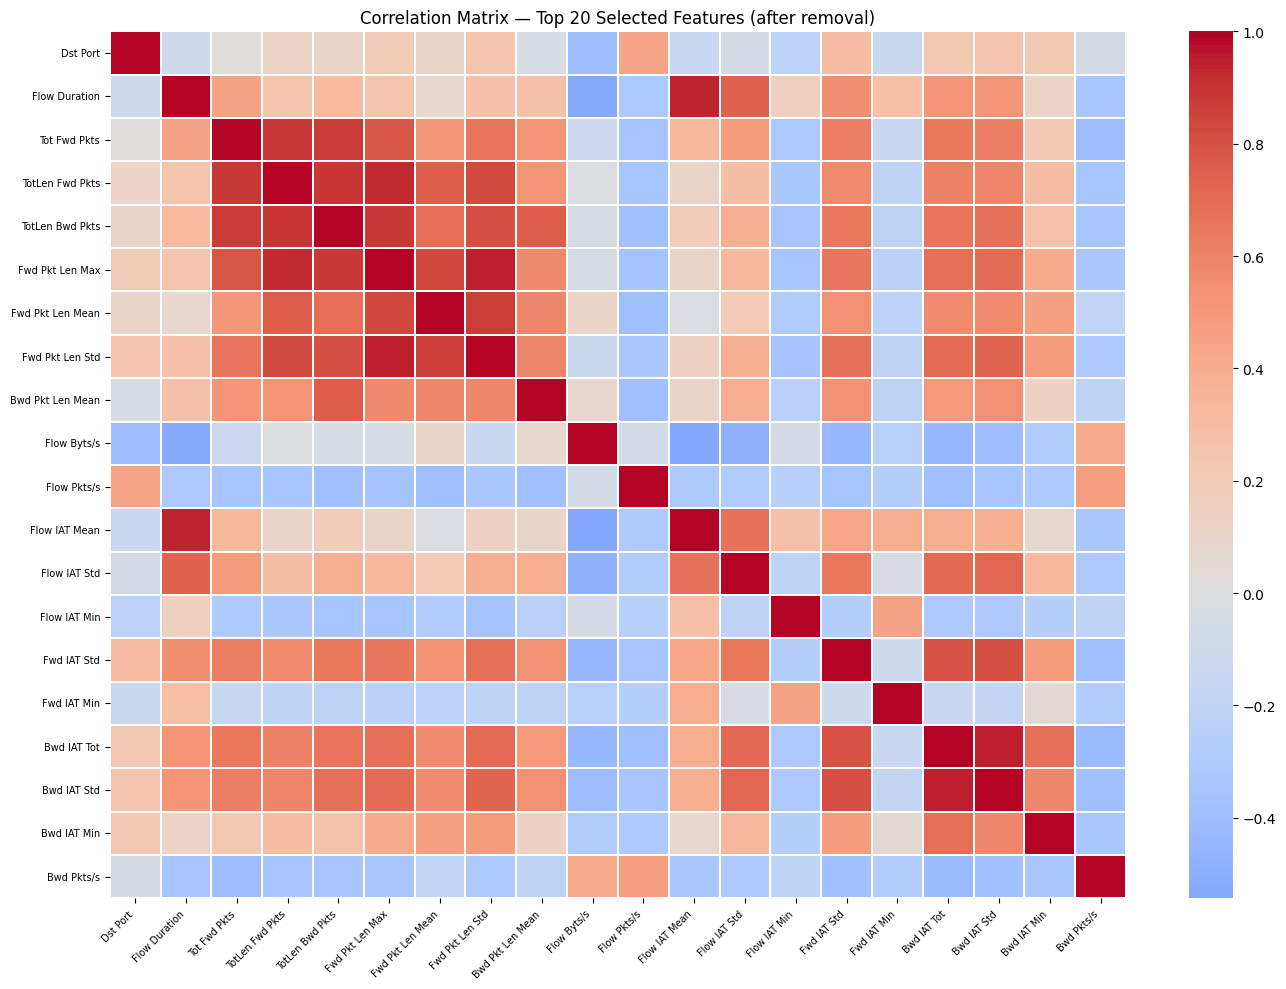


⚖️   STEP 4: Fitting StandardScaler on sample
   Scaler fitted on 50,000 sample rows × 33 features
   Mean range  : [0.2394, 3536472.1711]
   Scale range : [0.1981, 6150162.7936]

🚀  STEP 5: Transforming full dataset → writing output
   Chunks written: 100  |  Rows: 1,500,000
   Chunks written: 200  |  Rows: 3,000,000
   Chunks written: 300  |  Rows: 4,500,000
   Chunks written: 400  |  Rows: 6,000,000
   Chunks written: 500  |  Rows: 7,500,000
   Chunks written: 600  |  Rows: 9,000,000
   Chunks written: 700  |  Rows: 10,500,000
   Chunks written: 800  |  Rows: 12,000,000
   Chunks written: 900  |  Rows: 13,500,000

   ✅  Done.  Total rows written: 14,826,383

📊  FINAL REPORT

  Output shape   : 14,826,383 rows × 34 cols
  Features kept  : 33
  Features added : 5  ['Fwd_Bwd_Pkt_Ratio', 'Bytes_Per_Pkt', 'Duration_Per_Pkt', 'Fwd_Payload_Ratio', 'Active_Idle_Ratio']
  Dropped (low var)  : 19
  Dropped (high corr): 21

  Label distribution (final):


,Count
Benign,12884988
DDoS attacks-LOIC-HTTP,576135
DDOS attack-HOIC,502409
DoS attacks-Hulk,400470
Bot,157983
Infilteration,154959
SSH-Bruteforce,94485
DoS attacks-GoldenEye,41439
DoS attacks-Slowloris,9801
DDOS attack-LOIC-UDP,1730



  First 3 output rows (scaled):


,Dst Port,Flow Duration,Tot Fwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Mean,Flow Byts/s,...,Down/Up Ratio,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Fwd_Bwd_Pkt_Ratio,Bytes_Per_Pkt,Duration_Per_Pkt,Fwd_Payload_Ratio,Label
0,-0.780581,2.192726,-0.404731,-0.687205,-0.765943,-0.763791,-1.054697,-0.712815,-0.899374,-1.045561,...,-1.057833,-0.692466,-0.665578,-0.839629,-2.252219,-1.393397,-1.218504,2.992832,0.328937,Benign
1,-0.780581,2.192726,-0.404731,-0.687205,-0.765943,-0.763791,-1.054697,-0.712815,-0.899374,-1.045561,...,-1.057833,-0.692466,-0.665578,-0.839629,-2.252219,-1.393397,-1.218504,2.992832,0.328937,Benign
2,-0.780581,2.192726,-0.404731,-0.687205,-0.765943,-0.763791,-1.054697,-0.712815,-0.899374,-1.045561,...,-1.057833,-0.692466,-0.665578,-0.839629,-2.252219,-1.393397,-1.218504,2.992832,0.328937,Benign



  Feature reduction pipeline:


,Step,Count
0,Original features,68
1,After low-var drop,49
2,After corr drop,28
3,After engineering,33
4,Final (scaled),33



  Plotting scaled feature distributions (sample)...


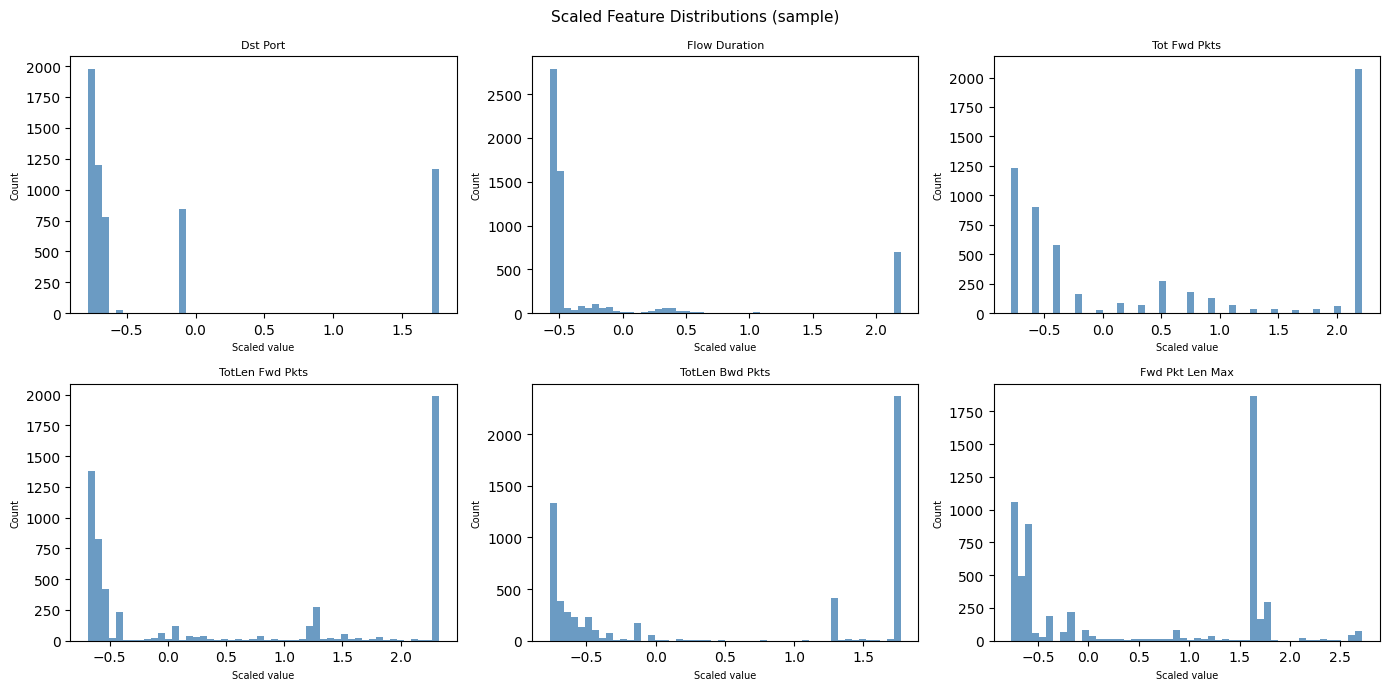


💾  Saved  →  /content/final_features_dataset.csv
    File size : 5246.93 MB
    Rows      : 14,826,383
    Columns   : 34

🎉  Done!


In [5]:
# ══════════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING + FEATURE SELECTION + FEATURE SCALING
#  Memory-safe: fit on sample → transform chunk by chunk → write output
#  Input : /content/cleaned_ids_dataset.csv  (14.8M rows × 69 cols)
#  Output: /content/final_features_dataset.csv
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────
INPUT_PATH      = "/content/cleaned_ids_dataset.csv"
OUTPUT_PATH     = "/content/final_features_dataset.csv"
CHUNK_SIZE      = 15_000
SAMPLE_ROWS     = 50_000   # used for corr matrix + scaler fit
CORR_THRESHOLD  = 0.95     # drop one of any pair above this

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — LOAD SAMPLE  (fit everything on this, never full dataset)
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Loading sample for analysis")
print("="*60)

sample_chunks = []
collected = 0
for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    sample_chunks.append(chunk.sample(min(500, len(chunk)), random_state=42))
    collected += min(500, len(chunk))
    if collected >= SAMPLE_ROWS:
        break

sample = pd.concat(sample_chunks, ignore_index=True).head(SAMPLE_ROWS)
del sample_chunks; gc.collect()

print(f"   Sample shape: {sample.shape}")

LABEL_COL  = "Label"
FEAT_COLS  = [c for c in sample.columns if c != LABEL_COL]
print(f"   Feature cols: {len(FEAT_COLS)}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — FEATURE ENGINEERING  (new ratio/interaction features)
#  Done on sample first to validate, then repeated in chunk loop
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔧  STEP 2: Feature engineering")
print("="*60)

def engineer_features(df):
    """Add domain-specific IDS ratio features. Safe: uses .get() defaults."""
    d = df.copy()

    # Fwd/Bwd packet ratio  (how asymmetric is the flow?)
    bwd = d.get("Tot Bwd Pkts",  pd.Series(0, index=d.index)).replace(0, np.nan)
    fwd = d.get("Tot Fwd Pkts",  pd.Series(0, index=d.index))
    d["Fwd_Bwd_Pkt_Ratio"]    = (fwd / bwd).fillna(0).astype("float32")

    # Bytes per packet (payload density)
    tot_pkts = (fwd + d.get("Tot Bwd Pkts", pd.Series(0, index=d.index))).replace(0, np.nan)
    tot_bytes = d.get("TotLen Fwd Pkts", pd.Series(0, index=d.index)) + \
                d.get("TotLen Bwd Pkts", pd.Series(0, index=d.index))
    d["Bytes_Per_Pkt"]        = (tot_bytes / tot_pkts).fillna(0).astype("float32")

    # Flow duration per packet (pkt inter-arrival proxy)
    dur = d.get("Flow Duration", pd.Series(0, index=d.index)).replace(0, np.nan)
    d["Duration_Per_Pkt"]     = (dur / tot_pkts).fillna(0).astype("float32")

    # Fwd payload ratio  (what fraction of bytes go forward?)
    tot_bytes_safe = tot_bytes.replace(0, np.nan)
    d["Fwd_Payload_Ratio"]    = (d.get("TotLen Fwd Pkts", pd.Series(0, index=d.index))
                                  / tot_bytes_safe).fillna(0.5).astype("float32")

    # Active / Idle ratio  (burst vs idle balance)
    idle = d.get("Idle Mean", pd.Series(0, index=d.index)).replace(0, np.nan)
    d["Active_Idle_Ratio"]    = (d.get("Active Mean", pd.Series(0, index=d.index))
                                  / idle).fillna(0).astype("float32")

    # Replace any inf that crept in
    d.replace([np.inf, -np.inf], 0, inplace=True)
    return d

sample = engineer_features(sample)
NEW_FEATS = ["Fwd_Bwd_Pkt_Ratio", "Bytes_Per_Pkt", "Duration_Per_Pkt",
             "Fwd_Payload_Ratio", "Active_Idle_Ratio"]
print(f"   New features added: {NEW_FEATS}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — FEATURE SELECTION
#  3-A  Drop near-zero variance (std < 1e-6 on sample)
#  3-B  Drop highly correlated pairs (|r| > CORR_THRESHOLD)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔍  STEP 3: Feature selection")
print("="*60)

num_sample = sample[FEAT_COLS + NEW_FEATS].select_dtypes(include=[np.number])

# 3-A  Near-zero variance
low_var = num_sample.std()[num_sample.std() < 1e-6].index.tolist()
print(f"   Low-variance cols dropped  : {len(low_var)} → {low_var}")

remaining = [c for c in num_sample.columns if c not in low_var]

# 3-B  Correlation — keep lower-triangle, drop one of each correlated pair
corr_matrix = num_sample[remaining].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"   High-corr cols dropped (>{CORR_THRESHOLD}): {len(high_corr_drop)} → {high_corr_drop}")

# Final feature list
selected_features = [c for c in remaining if c not in high_corr_drop]
print(f"\n   Features before selection : {len(num_sample.columns)}")
print(f"   Features after  selection : {len(selected_features)}")

# ── Correlation heatmap (top 20 selected features for readability) ────────
top20 = selected_features[:20]
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    num_sample[top20].corr(),
    annot=False, cmap="coolwarm", center=0,
    linewidths=0.3, ax=ax
)
ax.set_title("Correlation Matrix — Top 20 Selected Features (after removal)")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

del num_sample, corr_matrix, upper; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — FIT STANDARD SCALER on sample
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("⚖️   STEP 4: Fitting StandardScaler on sample")
print("="*60)

scaler = StandardScaler()
scaler.fit(sample[selected_features].values.astype("float32"))
print(f"   Scaler fitted on {len(sample):,} sample rows × {len(selected_features)} features")
print(f"   Mean range  : [{scaler.mean_.min():.4f}, {scaler.mean_.max():.4f}]")
print(f"   Scale range : [{scaler.scale_.min():.4f}, {scaler.scale_.max():.4f}]")

del sample; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 5 — TRANSFORM FULL DATASET chunk by chunk → write output
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🚀  STEP 5: Transforming full dataset → writing output")
print("="*60)

total_rows_out  = 0
header_written  = False
label_counts    = defaultdict(int)
chunk_idx       = 0
first_3_out     = None

ALL_OUTPUT_COLS = selected_features + [LABEL_COL]

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                         on_bad_lines='skip'):

    chunk.columns = chunk.columns.str.strip()

    # Cast numerics to float32
    for col in chunk.columns:
        if col != LABEL_COL:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce').astype("float32")

    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
    chunk.dropna(inplace=True)
    if chunk.empty: del chunk; gc.collect(); continue

    # Feature engineering
    chunk = engineer_features(chunk)

    # Keep only selected features + Label
    missing_cols = [c for c in selected_features if c not in chunk.columns]
    for c in missing_cols:
        chunk[c] = np.float32(0)
    chunk = chunk[ALL_OUTPUT_COLS]

    # Scale
    chunk[selected_features] = scaler.transform(
        chunk[selected_features].values.astype("float32")
    ).astype("float32")

    # Collect stats
    total_rows_out += len(chunk)
    for lbl, cnt in chunk[LABEL_COL].value_counts().items():
        label_counts[lbl] += int(cnt)

    if first_3_out is None:
        first_3_out = chunk.head(3).copy()

    # Write
    chunk.to_csv(
        OUTPUT_PATH,
        mode='a' if header_written else 'w',
        header=not header_written,
        index=False,
        quoting=csv.QUOTE_MINIMAL
    )
    header_written = True

    chunk_idx += 1
    if chunk_idx % 100 == 0:
        print(f"   Chunks written: {chunk_idx}  |  Rows: {total_rows_out:,}")

    del chunk; gc.collect()

print(f"\n   ✅  Done.  Total rows written: {total_rows_out:,}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 6 — FINAL REPORT
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  FINAL REPORT")
print("="*60)

print(f"\n  Output shape   : {total_rows_out:,} rows × {len(ALL_OUTPUT_COLS)} cols")
print(f"  Features kept  : {len(selected_features)}")
print(f"  Features added : {len(NEW_FEATS)}  {NEW_FEATS}")
print(f"  Dropped (low var)  : {len(low_var)}")
print(f"  Dropped (high corr): {len(high_corr_drop)}")

print(f"\n  Label distribution (final):")
display(pd.Series(label_counts).sort_values(ascending=False)
          .rename("Count").to_frame())

print(f"\n  First 3 output rows (scaled):")
display(first_3_out)

# Feature summary table
feat_summary = pd.DataFrame({
    "Step"   : ["Original features", "After low-var drop", "After corr drop",
                "After engineering", "Final (scaled)"],
    "Count"  : [len(FEAT_COLS),
                len(FEAT_COLS) - len(low_var),
                len(FEAT_COLS) - len(low_var) - len(high_corr_drop),
                len(FEAT_COLS) - len(low_var) - len(high_corr_drop) + len(NEW_FEATS),
                len(selected_features)]
})
print(f"\n  Feature reduction pipeline:")
display(feat_summary)

# ── Distribution plot: 6 scaled features ─────────────────────────────────
print(f"\n  Plotting scaled feature distributions (sample)...")
plot_sample_chunks = []
ps_collected = 0
for chunk in pd.read_csv(OUTPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    plot_sample_chunks.append(chunk.sample(min(300, len(chunk)), random_state=1))
    ps_collected += 300
    if ps_collected >= 6000:
        break
plot_sample = pd.concat(plot_sample_chunks, ignore_index=True)
del plot_sample_chunks; gc.collect()

plot_cols = selected_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), plot_cols):
    ax.hist(plot_sample[col].dropna(), bins=50, color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("Scaled value", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
plt.suptitle("Scaled Feature Distributions (sample)", fontsize=11)
plt.tight_layout(); plt.show()
del plot_sample; gc.collect()

# ── Final file info ───────────────────────────────────────────────────────
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"\n💾  Saved  →  {OUTPUT_PATH}")
print(f"    File size : {size_mb:.2f} MB")
print(f"    Rows      : {total_rows_out:,}")
print(f"    Columns   : {len(ALL_OUTPUT_COLS)}")
print("\n🎉  Done!")

# Dimensionality Reduction - **PCA**

⏳  STEP 1: Probing feature columns
   Feature columns : 33
   Features        : ['Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Std', 'Bwd IAT Min', 'Bwd Pkts/s', 'Pkt Len Mean', 'Pkt Len Var', 'PSH Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Fwd_Bwd_Pkt_Ratio', 'Bytes_Per_Pkt', 'Duration_Per_Pkt', 'Fwd_Payload_Ratio']

🔧  STEP 2: Fitting IncrementalPCA on full dataset
   Fitted chunks: 100  |  Rows seen: 1,500,000
   Fitted chunks: 200  |  Rows seen: 3,000,000
   Fitted chunks: 300  |  Rows seen: 4,500,000
   Fitted chunks: 400  |  Rows seen: 6,000,000
   Fitted chunks: 500  |  Rows seen: 7,500,000
   Fitted chunks: 600  |  Rows seen: 9,000,000
   Fitted chunk

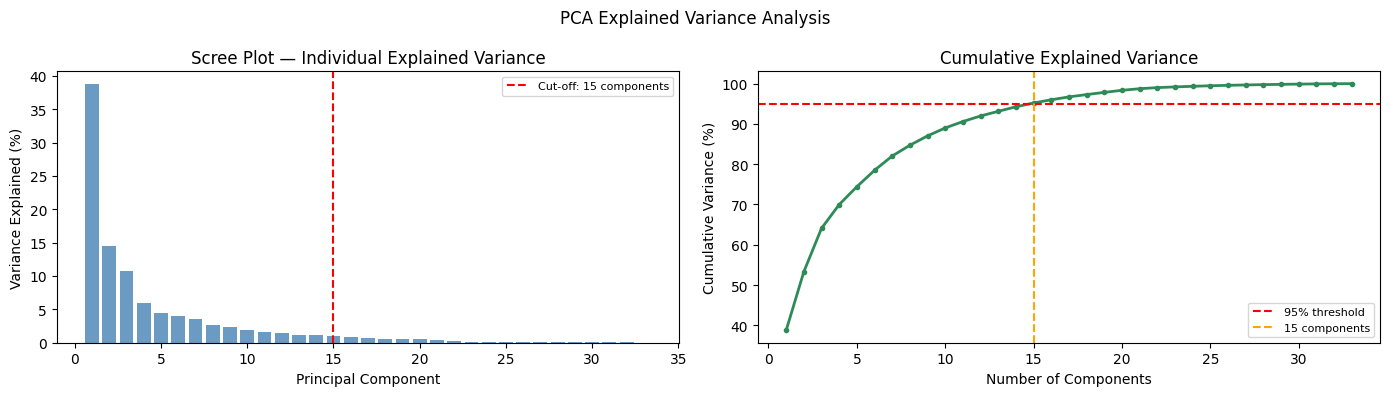


  Top 15 principal components:


,Component,Var Explained %,Cumulative %
0,PC1,38.73,38.73
1,PC2,14.56,53.29
2,PC3,10.78,64.07
3,PC4,5.91,69.98
4,PC5,4.43,74.41
5,PC6,4.08,78.49
6,PC7,3.54,82.03
7,PC8,2.68,84.71
8,PC9,2.33,87.04
9,PC10,1.96,89.00



  Top 10 feature loadings — PC1:


,Absolute Loading
Fwd Pkt Len Std,0.291203
Fwd Pkt Len Max,0.276285
Fwd Pkt Len Mean,0.255277
Fwd IAT Std,0.240327
Bytes_Per_Pkt,0.236933
Bwd IAT Std,0.226303
Init Bwd Win Byts,0.225196
Fwd Act Data Pkts,0.224214
Bwd IAT Tot,0.219093
TotLen Bwd Pkts,0.217088



  Top 10 feature loadings — PC2:


,Absolute Loading
Duration_Per_Pkt,0.350614
Flow IAT Mean,0.340402
Flow Byts/s,0.332719
Flow Duration,0.317298
Fwd IAT Min,0.287097
ACK Flag Cnt,0.257258
Bwd Pkts/s,0.252654
Flow IAT Min,0.238552
Down/Up Ratio,0.236586
Bytes_Per_Pkt,0.182093


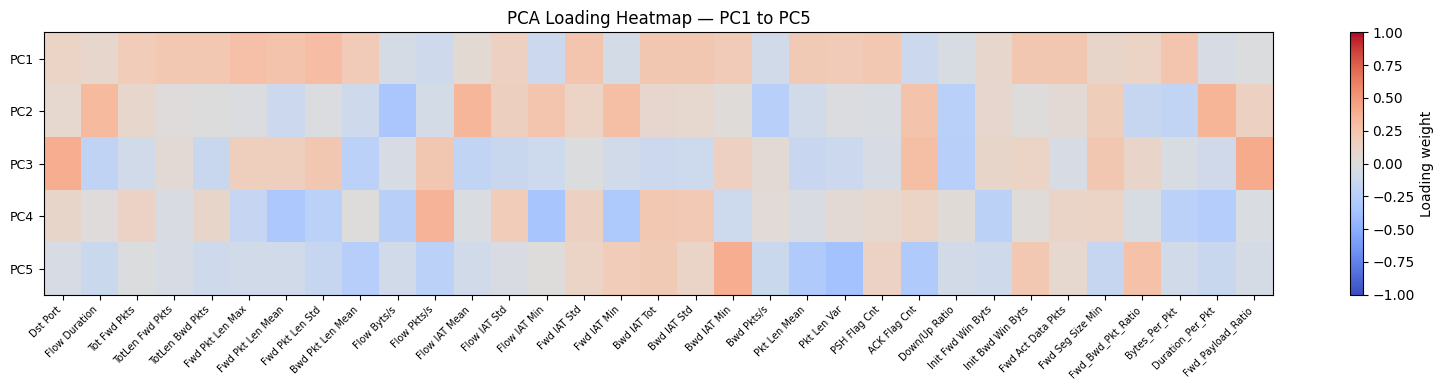


🚀  STEP 3: Transforming dataset → 15 PCA components
   Chunks written: 100  |  Rows: 1,500,000
   Chunks written: 200  |  Rows: 3,000,000
   Chunks written: 300  |  Rows: 4,500,000
   Chunks written: 400  |  Rows: 6,000,000
   Chunks written: 500  |  Rows: 7,500,000
   Chunks written: 600  |  Rows: 9,000,000
   Chunks written: 700  |  Rows: 10,500,000
   Chunks written: 800  |  Rows: 12,000,000
   Chunks written: 900  |  Rows: 13,500,000

   ✅  Transform complete.  Rows written: 14,826,383

📊  FINAL REPORT

  Input  : 33 features × 14,826,383 rows
  Output : 15 PCA components × 14,826,383 rows
  Variance retained : 95.20%
  Dimensionality reduction : 33 → 15  (54.5% reduction)

  Label distribution (PCA output):


,Count
Benign,12884988
DDoS attacks-LOIC-HTTP,576135
DDOS attack-HOIC,502409
DoS attacks-Hulk,400470
Bot,157983
Infilteration,154959
SSH-Bruteforce,94485
DoS attacks-GoldenEye,41439
DoS attacks-Slowloris,9801
DDOS attack-LOIC-UDP,1730



  First 3 PCA-transformed rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,Label
0,-3.536663,4.221704,-2.544140,-2.129115,0.486593,-1.196730,0.345368,0.945548,0.964587,1.437958,-0.377190,-0.130676,-0.371691,-0.504104,-1.274628,Benign
1,-3.536716,4.221674,-2.544132,-2.129149,0.486570,-1.196685,0.345385,0.945562,0.964579,1.437975,-0.377169,-0.130717,-0.371654,-0.504071,-1.274630,Benign
2,-3.536315,4.221901,-2.544188,-2.128891,0.486747,-1.197021,0.345258,0.945451,0.964641,1.437852,-0.377323,-0.130406,-0.371929,-0.504322,-1.274613,Benign



  Plotting PC1 vs PC2 scatter (sample)...


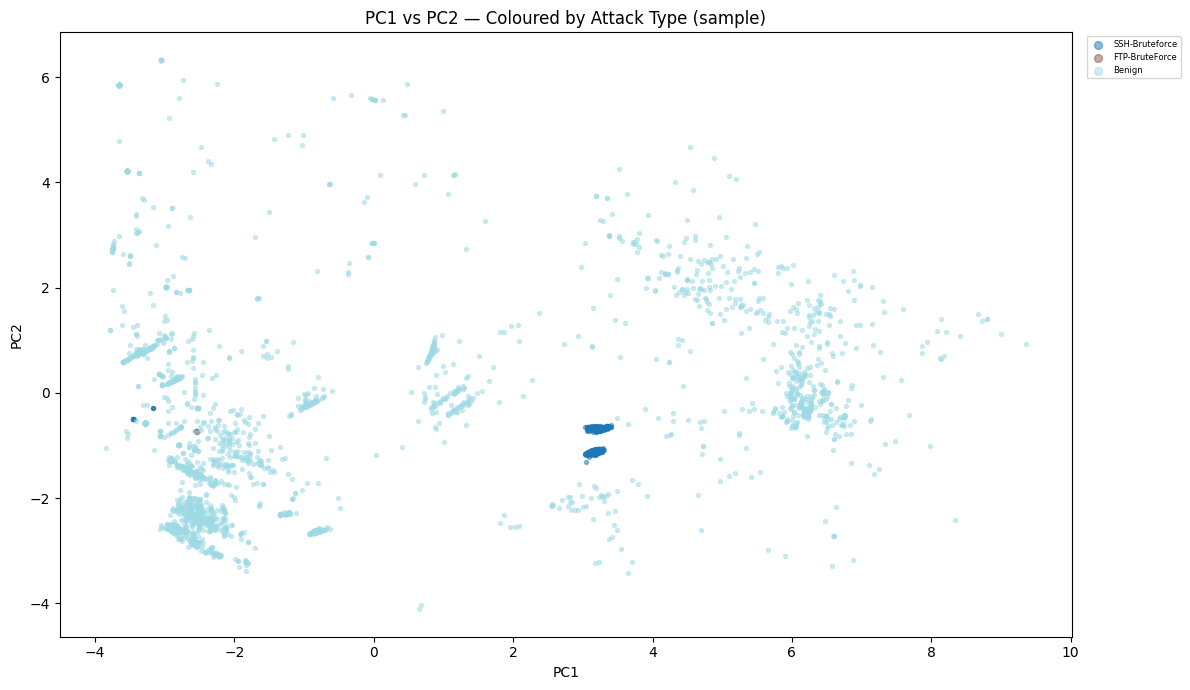

,Metric,Value
0,Input features,33
1,PCA components kept,15
2,Variance retained (%),95.20
3,Dimensionality reduction (%),54.5
4,Output rows,"14,826,383"
5,Output file size (MB),2440.71



💾  Saved  →  /content/pca_dataset.csv
    File size : 2440.71 MB
    Rows      : 14,826,383
    Columns   : 16  (15 PCs + Label)

🎉  Done!


In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  PCA — MEMORY-SAFE FOR GOOGLE COLAB FREE TIER
#  Fit: IncrementalPCA on full dataset (no sample bias)
#  Transform: chunk by chunk → write output
#  Input : /content/final_features.csv  (14.8M rows × 34 cols, scaled)
#  Output: /content/pca_dataset.csv
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import IncrementalPCA
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────
INPUT_PATH   = "/content/final_features_dataset.csv"
OUTPUT_PATH  = "/content/pca_dataset.csv"
CHUNK_SIZE   = 15_000
LABEL_COL    = "Label"
VARIANCE_TARGET = 0.95   # keep components that explain 95% variance

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — PROBE: get feature list from header only
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Probing feature columns")
print("="*60)

probe = pd.read_csv(INPUT_PATH, nrows=1)
probe.columns = probe.columns.str.strip()
FEAT_COLS = [c for c in probe.columns if c != LABEL_COL]
N_FEATURES = len(FEAT_COLS)
del probe; gc.collect()
print(f"   Feature columns : {N_FEATURES}")
print(f"   Features        : {FEAT_COLS}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — FIT IncrementalPCA (full dataset, one chunk at a time)
#  IncrementalPCA updates its internal sufficient statistics per batch —
#  it never holds more than one chunk in RAM
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔧  STEP 2: Fitting IncrementalPCA on full dataset")
print("="*60)

# Start with max components = n_features; we'll cut to 95% variance after
ipca = IncrementalPCA(n_components=N_FEATURES, batch_size=CHUNK_SIZE)

chunks_fit = 0
rows_fit   = 0

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    # Ensure all feature cols are float32 — drop rows with any NaN
    X = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype('float32')
    X.dropna(inplace=True)
    if len(X) < N_FEATURES:          # IncrementalPCA needs batch ≥ n_components
        del chunk, X; gc.collect(); continue

    ipca.partial_fit(X.values)
    rows_fit   += len(X)
    chunks_fit += 1

    if chunks_fit % 100 == 0:
        print(f"   Fitted chunks: {chunks_fit}  |  Rows seen: {rows_fit:,}")

    del chunk, X; gc.collect()

print(f"\n   ✅  IncrementalPCA fitted on {rows_fit:,} rows")

# ── Explained variance analysis ───────────────────────────────────────────
explained      = ipca.explained_variance_ratio_
cumulative_var = np.cumsum(explained)

# Find n_components needed to reach VARIANCE_TARGET
n_components = int(np.searchsorted(cumulative_var, VARIANCE_TARGET) + 1)
n_components = min(n_components, N_FEATURES)

print(f"\n   Variance target      : {VARIANCE_TARGET*100:.0f}%")
print(f"   Components needed    : {n_components}  (out of {N_FEATURES})")
print(f"   Variance explained   : {cumulative_var[n_components-1]*100:.2f}%")

# ── Scree plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8)
axes[0].axvline(x=n_components, color='red', linestyle='--', linewidth=1.5,
                label=f'Cut-off: {n_components} components')
axes[0].set_title("Scree Plot — Individual Explained Variance")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Variance Explained (%)")
axes[0].legend(fontsize=8)

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             color='seagreen', linewidth=2, marker='o', markersize=3)
axes[1].axhline(y=VARIANCE_TARGET*100, color='red', linestyle='--', linewidth=1.5,
                label=f'{VARIANCE_TARGET*100:.0f}% threshold')
axes[1].axvline(x=n_components, color='orange', linestyle='--', linewidth=1.5,
                label=f'{n_components} components')
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components"); axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend(fontsize=8)

plt.suptitle("PCA Explained Variance Analysis", fontsize=12)
plt.tight_layout(); plt.show()

# ── Component breakdown table ─────────────────────────────────────────────
comp_df = pd.DataFrame({
    "Component"      : [f"PC{i+1}" for i in range(min(n_components, 15))],
    "Var Explained %" : [f"{v*100:.2f}" for v in explained[:min(n_components, 15)]],
    "Cumulative %"   : [f"{v*100:.2f}" for v in cumulative_var[:min(n_components, 15)]]
})
print(f"\n  Top {min(n_components, 15)} principal components:")
display(comp_df)

# ── Top feature loadings for PC1 and PC2 ─────────────────────────────────
print(f"\n  Top 10 feature loadings — PC1:")
pc1_loadings = pd.Series(np.abs(ipca.components_[0]), index=FEAT_COLS).sort_values(ascending=False)
display(pc1_loadings.head(10).rename("Absolute Loading").to_frame())

print(f"\n  Top 10 feature loadings — PC2:")
pc2_loadings = pd.Series(np.abs(ipca.components_[1]), index=FEAT_COLS).sort_values(ascending=False)
display(pc2_loadings.head(10).rename("Absolute Loading").to_frame())

# ── Loading heatmap (PC1–PC5 vs all features) ─────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
loading_matrix = pd.DataFrame(
    ipca.components_[:min(5, n_components)],
    index=[f"PC{i+1}" for i in range(min(5, n_components))],
    columns=FEAT_COLS
)
im = ax.imshow(loading_matrix.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEAT_COLS))); ax.set_xticklabels(FEAT_COLS, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(min(5, n_components)))
ax.set_yticklabels([f"PC{i+1}" for i in range(min(5, n_components))], fontsize=9)
ax.set_title("PCA Loading Heatmap — PC1 to PC5")
plt.colorbar(im, ax=ax, label="Loading weight")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — TRANSFORM full dataset with n_components → write output
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(f"🚀  STEP 3: Transforming dataset → {n_components} PCA components")
print("="*60)

PC_COLS        = [f"PC{i+1}" for i in range(n_components)]
ALL_OUT_COLS   = PC_COLS + [LABEL_COL]

total_rows_out = 0
header_written = False
label_counts   = defaultdict(int)
chunk_idx      = 0
first_3_out    = None

# Slice component matrix once — avoids recomputing per chunk
components_k   = ipca.components_[:n_components]          # shape (k, n_features)
mean_          = ipca.mean_.astype('float32')              # shape (n_features,)

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    labels = chunk[LABEL_COL].astype(str).str.strip()

    X = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype('float32').values
    del chunk; gc.collect()

    # Drop rows with NaN
    valid_mask = ~np.isnan(X).any(axis=1)
    X      = X[valid_mask]
    labels = labels[valid_mask]
    if len(X) == 0: del X, labels; gc.collect(); continue

    # Manual transform: X_pca = (X - mean) @ components.T
    # Equivalent to ipca.transform but uses only k components → less RAM
    X_pca = (X - mean_) @ components_k.T          # shape (n, k)
    del X; gc.collect()

    out = pd.DataFrame(X_pca.astype('float32'), columns=PC_COLS)
    out[LABEL_COL] = labels.values
    del X_pca; gc.collect()

    # Collect stats
    total_rows_out += len(out)
    for lbl, cnt in out[LABEL_COL].value_counts().items():
        label_counts[lbl] += int(cnt)

    if first_3_out is None:
        first_3_out = out.head(3).copy()

    out.to_csv(
        OUTPUT_PATH,
        mode='a' if header_written else 'w',
        header=not header_written,
        index=False,
        quoting=csv.QUOTE_MINIMAL
    )
    header_written = True

    chunk_idx += 1
    if chunk_idx % 100 == 0:
        print(f"   Chunks written: {chunk_idx}  |  Rows: {total_rows_out:,}")

    del out; gc.collect()

print(f"\n   ✅  Transform complete.  Rows written: {total_rows_out:,}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — FINAL REPORT
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  FINAL REPORT")
print("="*60)

print(f"\n  Input  : {N_FEATURES} features × 14,826,383 rows")
print(f"  Output : {n_components} PCA components × {total_rows_out:,} rows")
print(f"  Variance retained : {cumulative_var[n_components-1]*100:.2f}%")
print(f"  Dimensionality reduction : {N_FEATURES} → {n_components}  "
      f"({(1 - n_components/N_FEATURES)*100:.1f}% reduction)")

print(f"\n  Label distribution (PCA output):")
display(pd.Series(label_counts).sort_values(ascending=False)
          .rename("Count").to_frame())

print(f"\n  First 3 PCA-transformed rows:")
display(first_3_out)

# ── 2D scatter: PC1 vs PC2 coloured by attack type (small sample) ─────────
print(f"\n  Plotting PC1 vs PC2 scatter (sample)...")
scatter_chunks = []
sc_collected   = 0
for chunk in pd.read_csv(OUTPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    scatter_chunks.append(chunk.sample(min(200, len(chunk)), random_state=42))
    sc_collected += 200
    if sc_collected >= 4000:
        break
scatter_df = pd.concat(scatter_chunks, ignore_index=True)
del scatter_chunks; gc.collect()

labels_unique = scatter_df[LABEL_COL].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(labels_unique)))
color_map = dict(zip(labels_unique, colors))

fig, ax = plt.subplots(figsize=(12, 7))
for lbl in labels_unique:
    mask = scatter_df[LABEL_COL] == lbl
    ax.scatter(scatter_df.loc[mask, "PC1"],
               scatter_df.loc[mask, "PC2"],
               label=lbl, alpha=0.5, s=8,
               color=color_map[lbl])
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PC1 vs PC2 — Coloured by Attack Type (sample)")
ax.legend(fontsize=6, markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()
del scatter_df; gc.collect()

# ── Summary table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Metric"  : ["Input features", "PCA components kept",
                 "Variance retained (%)", "Dimensionality reduction (%)",
                 "Output rows", "Output file size (MB)"],
    "Value"   : [N_FEATURES, n_components,
                 f"{cumulative_var[n_components-1]*100:.2f}",
                 f"{(1 - n_components/N_FEATURES)*100:.1f}",
                 f"{total_rows_out:,}",
                 f"{os.path.getsize(OUTPUT_PATH)/(1024*1024):.2f}"]
})
display(summary)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"\n💾  Saved  →  {OUTPUT_PATH}")
print(f"    File size : {size_mb:.2f} MB")
print(f"    Rows      : {total_rows_out:,}")
print(f"    Columns   : {n_components + 1}  ({n_components} PCs + Label)")
print("\n🎉  Done!")

In [15]:
# =========================================================
# COPY RESULTS TO DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/PCA-dataset"

!cp -r /content/pca_dataset.csv "$DEST"

print("✅ Results copied to Drive:", DEST)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/PCA-dataset


# **Undersampling - Handling Class imbalance**

### ***BINARY CLASSIFICATION PREP + UNDERSAMPLING (WEIGHTED RANDOM SAMPLING)***





⏳  STEP 1: Counting classes (before)
   Total rows         : 14,826,383
   Benign             : 12,884,988  (86.9%)
   Attack (all types) : 1,941,395  (13.1%)
   Imbalance ratio    : 6.6 : 1

  Attack breakdown (before):


,Count
DDoS attacks-LOIC-HTTP,576135
DDOS attack-HOIC,502409
DoS attacks-Hulk,400470
Bot,157983
Infilteration,154959
SSH-Bruteforce,94485
DoS attacks-GoldenEye,41439
DoS attacks-Slowloris,9801
DDOS attack-LOIC-UDP,1730
FTP-BruteForce,615


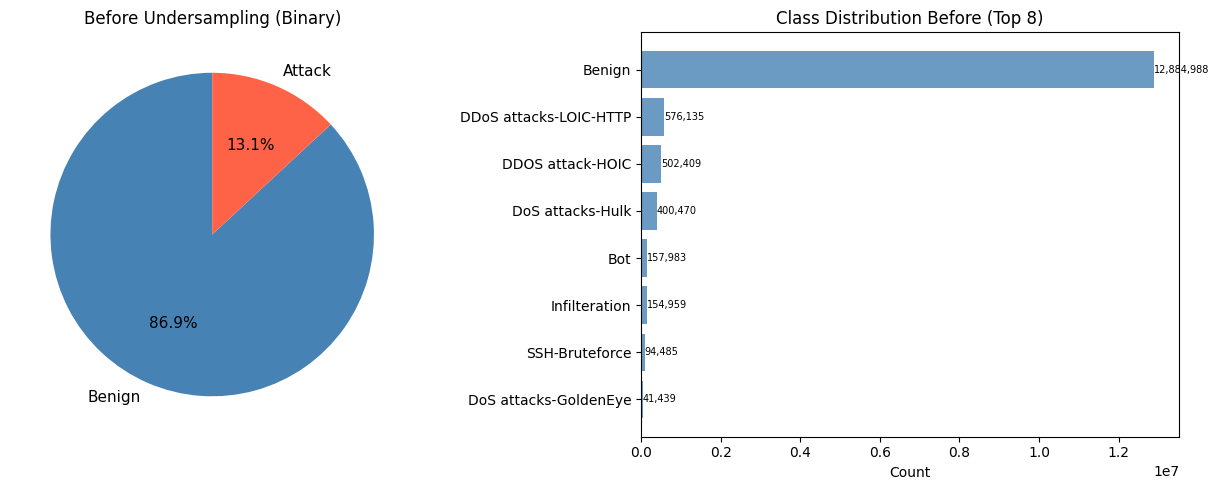


⚖️   STEP 2: Computing sampling parameters
   Strategy           : Keep ALL 1,941,395 Attack rows
                        Undersample Benign → 1,941,395 rows
   Benign keep prob   : 0.150671  (dropping 84.9% of Benign)
   Expected total     : 3,882,790
   Expected ratio     : 1 : 1  (Benign : Attack)

🚀  STEP 3: Applying undersampling → writing output
   Chunks: 100  |  Rows: 349,977  |  Benign: 203,637  Attack: 146,340
   Chunks: 200  |  Rows: 1,279,632  |  Benign: 304,812  Attack: 974,820
   Chunks: 300  |  Rows: 1,632,216  |  Benign: 508,784  Attack: 1,123,432
   Chunks: 400  |  Rows: 1,858,173  |  Benign: 734,741  Attack: 1,123,432
   Chunks: 500  |  Rows: 2,083,742  |  Benign: 960,310  Attack: 1,123,432
   Chunks: 600  |  Rows: 2,309,915  |  Benign: 1,186,483  Attack: 1,123,432
   Chunks: 700  |  Rows: 2,793,704  |  Benign: 1,366,680  Attack: 1,427,024
   Chunks: 800  |  Rows: 3,190,691  |  Benign: 1,562,779  Attack: 1,627,912
   Chunks: 900  |  Rows: 3,441,292  |  Benign: 1,784,

,Metric,Before,After
0,Total rows,"14,826,383","3,882,708"
1,Benign rows,"12,884,988","1,941,313"
2,Benign %,86.9%,50.0%
3,Attack rows,"1,941,395","1,941,395"
4,Attack %,13.1%,50.0%
5,Imbalance ratio (B:A),6.6 : 1,1.00 : 1
6,Rows removed,—,"10,943,675"



  First 3 output rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,Label
0,-2.544014,-0.734219,1.360405,1.884129,-0.655697,1.784967,3.152118,-0.132496,-2.233611,-0.796787,0.757013,-0.162683,1.414265,-0.784325,-0.013139,Attack
1,-2.544066,-0.734118,1.360356,1.883987,-0.655696,1.785005,3.152070,-0.132488,-2.233558,-0.796813,0.756859,-0.162484,1.414339,-0.784267,-0.013064,Attack
2,3.122035,-0.663187,0.436551,-0.724100,-0.800475,2.230270,0.915767,-1.839500,-1.096190,2.171597,0.327693,0.279137,0.934231,-1.309494,1.127297,Attack


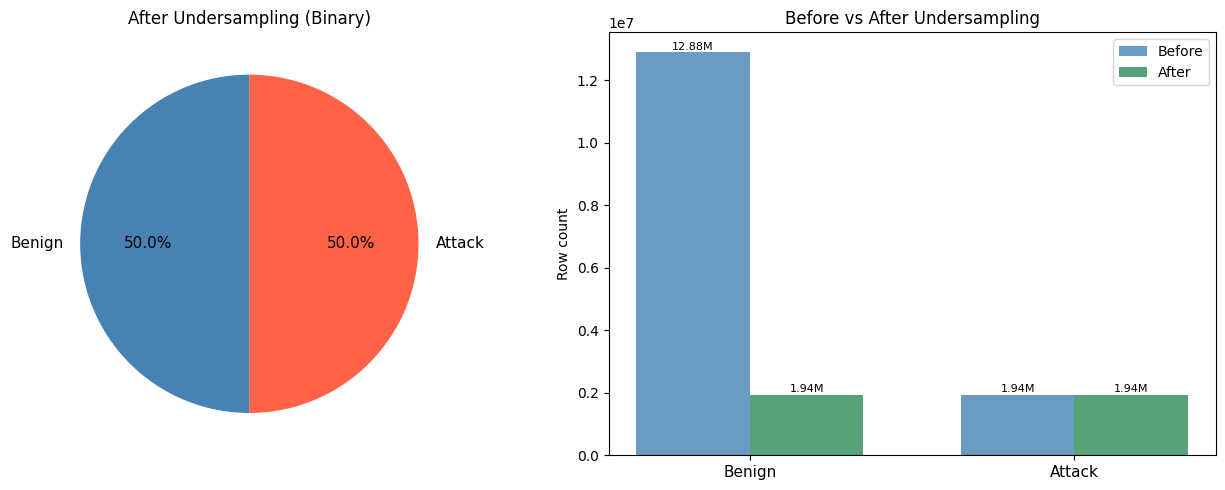


💾  Saved  →  /content/binary_balanced.csv
    File size : 632.06 MB
    Rows      : 3,882,708
    Benign    : 1,941,313  (50.0%)
    Attack    : 1,941,395  (50.0%)
    Columns   : 16  (15 PCs + Label)

🎉  Done!


In [10]:
# ══════════════════════════════════════════════════════════════════════════
#  BINARY CLASSIFICATION — UNDERSAMPLING TO PERFECT 1:1 BALANCE
#  • ALL 1,941,395 Attack rows kept (no dropping)
#  • Benign randomly undersampled to exactly match Attack count
#  • Result: 50% Benign / 50% Attack
#  Input : /content/pca_dataset.csv
#  Output: /content/binary_balanced.csv
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/pca_dataset.csv"
OUTPUT_PATH = "/content/binary_balanced.csv"
CHUNK_SIZE  = 15_000
LABEL_COL   = "Label"
TARGET_RATIO = 1.0   # 1:1 → Benign : Attack

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — COUNT CLASSES BEFORE
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Counting classes (before)")
print("="*60)

raw_counts   = defaultdict(int)
total_before = 0

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    for lbl, cnt in chunk[LABEL_COL].value_counts().items():
        raw_counts[lbl] += int(cnt)
    total_before += len(chunk)
    del chunk; gc.collect()

benign_before = raw_counts.get("Benign", 0)
attack_before = total_before - benign_before

print(f"   Total rows         : {total_before:,}")
print(f"   Benign             : {benign_before:,}  ({benign_before/total_before*100:.1f}%)")
print(f"   Attack (all types) : {attack_before:,}  ({attack_before/total_before*100:.1f}%)")
print(f"   Imbalance ratio    : {benign_before/attack_before:.1f} : 1")

print(f"\n  Attack breakdown (before):")
attack_breakdown = {k: v for k, v in
                    sorted(raw_counts.items(), key=lambda x: -x[1])
                    if k != "Benign"}
display(pd.Series(attack_breakdown).rename("Count").to_frame())

# ── Before charts ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([benign_before, attack_before],
            labels=["Benign", "Attack"],
            colors=["steelblue", "tomato"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[0].set_title("Before Undersampling (Binary)", fontsize=12)

top8 = dict(sorted(raw_counts.items(), key=lambda x: -x[1])[:8])
axes[1].barh(list(top8.keys()), list(top8.values()), color="steelblue", alpha=0.8)
axes[1].set_xlabel("Count")
axes[1].set_title("Class Distribution Before (Top 8)", fontsize=12)
axes[1].invert_yaxis()
for i, v in enumerate(top8.values()):
    axes[1].text(v + 1000, i, f"{v:,}", va='center', fontsize=7)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — COMPUTE BENIGN KEEP PROBABILITY
#
#  Target: Benign_kept = Attack_total × TARGET_RATIO
#  All attack rows are kept unconditionally (they are the minority class)
#  Benign rows are randomly sampled with uniform probability = keep_prob
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("⚖️   STEP 2: Computing sampling parameters")
print("="*60)

target_benign  = int(attack_before * TARGET_RATIO)
benign_keep_p  = min(1.0, target_benign / benign_before)
expected_total = target_benign + attack_before

print(f"   Strategy           : Keep ALL {attack_before:,} Attack rows")
print(f"                        Undersample Benign → {target_benign:,} rows")
print(f"   Benign keep prob   : {benign_keep_p:.6f}  "
      f"(dropping {(1-benign_keep_p)*100:.1f}% of Benign)")
print(f"   Expected total     : {expected_total:,}")
print(f"   Expected ratio     : 1 : 1  (Benign : Attack)")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — STREAM + APPLY SAMPLING → WRITE
#
#  Benign : uniform random sampling with prob = benign_keep_p
#  Attack : ALL rows kept, label converted to binary "Attack"
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🚀  STEP 3: Applying undersampling → writing output")
print("="*60)

after_counts   = defaultdict(int)
total_after    = 0
header_written = False
chunk_idx      = 0
first_3_out    = None
rng            = np.random.default_rng(seed=42)

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    orig_label  = chunk[LABEL_COL].astype(str).str.strip()
    benign_mask = orig_label == "Benign"
    attack_mask = ~benign_mask

    parts = []

    # ── Benign: random undersample ────────────────────────────────────────
    if benign_mask.any():
        ben = chunk[benign_mask].copy()
        keep = rng.random(len(ben)) < benign_keep_p
        ben  = ben[keep]
        if not ben.empty:
            ben[LABEL_COL] = "Benign"
            parts.append(ben)
        del ben; gc.collect()

    # ── Attack: keep ALL rows, convert to binary label ────────────────────
    if attack_mask.any():
        atk = chunk[attack_mask].copy()
        atk[LABEL_COL] = "Attack"   # collapse all attack types → "Attack"
        parts.append(atk)
        del atk; gc.collect()

    del chunk; gc.collect()
    if not parts:
        continue

    out = pd.concat(parts, ignore_index=True)
    del parts; gc.collect()

    # Shuffle so Benign/Attack rows are interleaved
    out = out.sample(frac=1, random_state=int(rng.integers(1e6))).reset_index(drop=True)

    for lbl, cnt in out[LABEL_COL].value_counts().items():
        after_counts[lbl] += int(cnt)
    total_after += len(out)

    if first_3_out is None:
        first_3_out = out.head(3).copy()

    out.to_csv(
        OUTPUT_PATH,
        mode='a' if header_written else 'w',
        header=not header_written,
        index=False,
        quoting=csv.QUOTE_MINIMAL
    )
    header_written = True
    chunk_idx += 1

    if chunk_idx % 100 == 0:
        b = after_counts.get("Benign", 0)
        a = after_counts.get("Attack", 0)
        print(f"   Chunks: {chunk_idx}  |  Rows: {total_after:,}  "
              f"|  Benign: {b:,}  Attack: {a:,}")

    del out; gc.collect()

print(f"\n   ✅  Done.  Total rows written: {total_after:,}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — BEFORE vs AFTER REPORT
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  BEFORE vs AFTER REPORT")
print("="*60)

benign_after = after_counts.get("Benign", 0)
attack_after = after_counts.get("Attack", 0)
ratio_after  = benign_after / attack_after if attack_after > 0 else float('inf')

summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Benign rows", "Benign %",
        "Attack rows", "Attack %",
        "Imbalance ratio (B:A)",
        "Rows removed",
    ],
    "Before": [
        f"{total_before:,}",
        f"{benign_before:,}", f"{benign_before/total_before*100:.1f}%",
        f"{attack_before:,}", f"{attack_before/total_before*100:.1f}%",
        f"{benign_before/attack_before:.1f} : 1",
        "—",
    ],
    "After": [
        f"{total_after:,}",
        f"{benign_after:,}", f"{benign_after/total_after*100:.1f}%",
        f"{attack_after:,}", f"{attack_after/total_after*100:.1f}%",
        f"{ratio_after:.2f} : 1",
        f"{total_before - total_after:,}",
    ]
})
display(summary)

print(f"\n  First 3 output rows:")
display(first_3_out)

# ── After charts ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([benign_after, attack_after],
            labels=["Benign", "Attack"],
            colors=["steelblue", "tomato"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[0].set_title("After Undersampling (Binary)", fontsize=12)

categories  = ["Benign", "Attack"]
before_vals = [benign_before, attack_before]
after_vals  = [benign_after,  attack_after]
x = np.arange(2); w = 0.35

axes[1].bar(x - w/2, before_vals, w, label="Before", color="steelblue", alpha=0.8)
axes[1].bar(x + w/2, after_vals,  w, label="After",  color="seagreen",  alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(categories, fontsize=11)
axes[1].set_ylabel("Row count")
axes[1].set_title("Before vs After Undersampling", fontsize=12)
axes[1].legend()
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    axes[1].text(i - w/2, b + 80000, f"{b/1e6:.2f}M", ha='center', fontsize=8)
    axes[1].text(i + w/2, a + 80000, f"{a/1e6:.2f}M", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"\n💾  Saved  →  {OUTPUT_PATH}")
print(f"    File size : {size_mb:.2f} MB")
print(f"    Rows      : {total_after:,}")
print(f"    Benign    : {benign_after:,}  ({benign_after/total_after*100:.1f}%)")
print(f"    Attack    : {attack_after:,}  ({attack_after/total_after*100:.1f}%)")
print(f"    Columns   : 16  (15 PCs + Label)")
print("\n🎉  Done!")

In [16]:
# =========================================================
# COPY TEST CSV FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/balanced-dataset"

!cp -r /content/binary_balanced.csv "$DEST"

print("✅ Results copied to Drive:", DEST)

✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/balanced-dataset


# **Train / Test Split ( 80 - 20 )**

⏳  STEP 1: Counting rows per class
   Total rows   : 3,882,708
   Benign       : 1,941,313  (50.0%)
   Attack       : 1,941,395  (50.0%)

   ── Stratified targets ──────────────────────────────
   TRAIN  : 3,106,166  (Benign 1,553,050 | Attack 1,553,116)
   TEST   : 776,542  (Benign 388,263  | Attack 388,279)
   Ratio  : 80.0% train / 20.0% test

✂️   STEP 2: Streaming stratified 80/20 split
   Chunks: 100  |  Train: 1,199,994  Test: 300,006
   Chunks: 200  |  Train: 2,399,962  Test: 600,038

   ✅  Split complete.

📊  FINAL REPORT


,Metric,Full dataset,Train (80%),Test (20%)
0,Total rows,"3,882,708","3,106,180","776,528"
1,Benign rows,"1,941,313","1,553,070","388,243"
2,Benign %,50.0%,50.0%,50.0%
3,Attack rows,"1,941,395","1,553,110","388,285"
4,Attack %,50.0%,50.0%,50.0%
5,Benign : Attack ratio,1.00 : 1,1.00 : 1,1.00 : 1
6,Train % of total,—,80.0%,—
7,Test % of total,—,—,20.0%



  ✅  Stratification check:
     Train Benign : 50.00%  (target 50.0%)  ✓
     Train Attack : 50.00%  (target 50.0%)  ✓
     Test  Benign : 50.00%  (target 50.0%)  ✓
     Test  Attack : 50.00%  (target 50.0%)  ✓

  First 3 TRAIN rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,Label
0,3.229764,-0.684834,0.493339,-0.820268,-0.823076,2.163581,0.866014,-1.812272,-1.142167,2.152465,0.337428,0.294703,0.929275,-1.337173,1.098727,Attack
1,3.083067,-1.147817,0.070664,-0.792254,-0.969304,1.898094,0.983096,-1.301227,-1.616681,1.676528,0.766559,0.769251,1.475319,-0.580597,0.793585,Attack
2,3.201437,-0.652954,0.441946,-0.732173,-0.771506,2.209462,0.881730,-1.806517,-1.119818,2.161697,0.336938,0.279603,0.921999,-1.295742,1.152424,Attack



  First 3 TEST rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,Label
0,3.226834,-0.643206,0.423390,-0.706482,-0.777527,2.207366,0.875127,-1.795570,-1.117697,2.166208,0.324817,0.308307,0.933076,-1.291664,1.165016,Attack
1,3.154767,-1.093037,0.013752,-0.722366,-0.936959,1.902110,0.957114,-1.268383,-1.613600,1.689933,0.763346,0.827086,1.496212,-0.550957,0.843841,Attack
2,3.289670,-0.672628,0.449041,-0.765246,-0.822311,2.178314,0.850766,-1.790598,-1.138488,2.159212,0.318222,0.306488,0.933878,-1.292890,1.142410,Attack


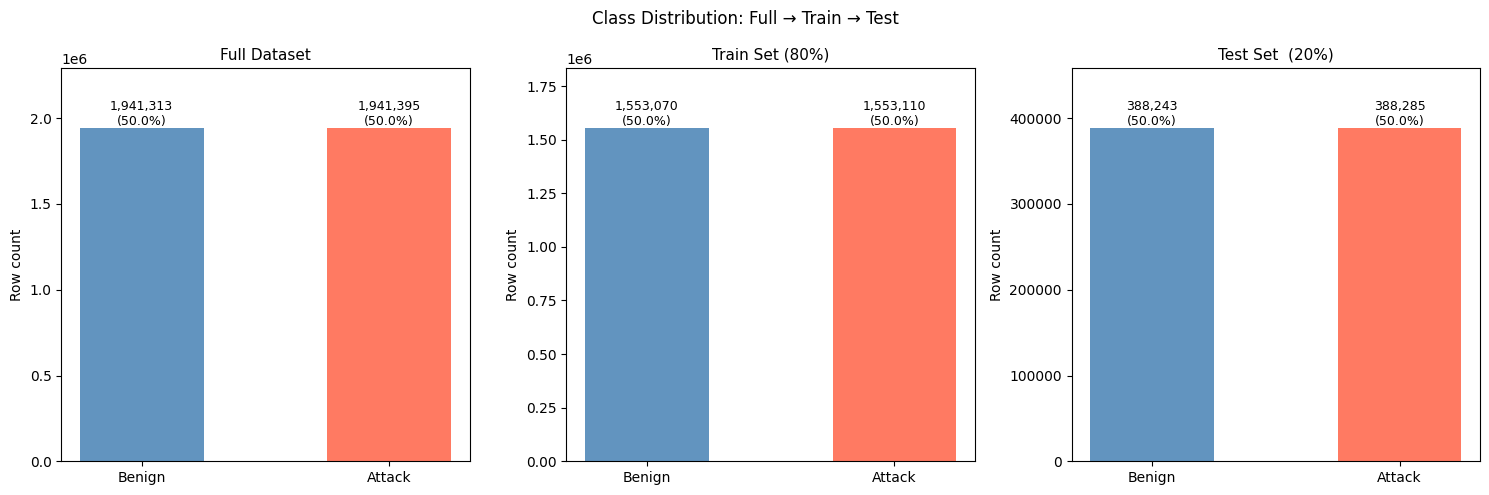

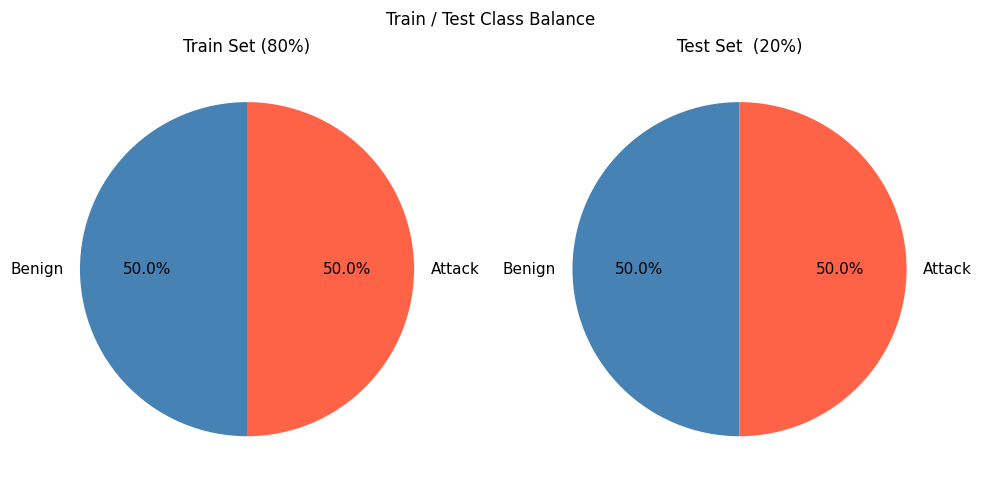


💾  TRAIN saved → /content/train.csv
    Rows      : 3,106,180
    File size : 505.65 MB

💾  TEST  saved → /content/test.csv
    Rows      : 776,528
    File size : 126.41 MB

    Columns (both) : 16  (PC1–PC15 + Label)

🎉  Done!


In [17]:
# ══════════════════════════════════════════════════════════════════════════
#  STRATIFIED 80/20 TRAIN-TEST SPLIT — MEMORY-SAFE STREAMING
#  Preserves 50/50 Benign:Attack balance in both train and test sets
#  Input : /content/binary_balanced.csv  (3.88M rows × 16 cols)
#  Output: /content/train.csv  (80%)
#          /content/test.csv   (20%)
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/binary_balanced.csv"
TRAIN_PATH  = "/content/train.csv"
TEST_PATH   = "/content/test.csv"
CHUNK_SIZE  = 15_000
LABEL_COL   = "Label"
TEST_SIZE   = 0.20    # 20% test
TRAIN_SIZE  = 0.80   # 80% train
RANDOM_SEED = 42

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — COUNT TOTAL ROWS PER CLASS  (needed for stratification math)
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Counting rows per class")
print("="*60)

class_counts = defaultdict(int)
total_rows   = 0

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    for lbl, cnt in chunk[LABEL_COL].value_counts().items():
        class_counts[lbl] += int(cnt)
    total_rows += len(chunk)
    del chunk; gc.collect()

benign_total = class_counts["Benign"]
attack_total = class_counts["Attack"]

print(f"   Total rows   : {total_rows:,}")
print(f"   Benign       : {benign_total:,}  ({benign_total/total_rows*100:.1f}%)")
print(f"   Attack       : {attack_total:,}  ({attack_total/total_rows*100:.1f}%)")

# ── Exact stratified targets ───────────────────────────────────────────────
# Each class split independently so balance is preserved exactly
benign_test  = int(round(benign_total * TEST_SIZE))
benign_train = benign_total - benign_test
attack_test  = int(round(attack_total * TEST_SIZE))
attack_train = attack_total - attack_test

total_train  = benign_train + attack_train
total_test   = benign_test  + attack_test

print(f"\n   ── Stratified targets ──────────────────────────────")
print(f"   TRAIN  : {total_train:,}  "
      f"(Benign {benign_train:,} | Attack {attack_train:,})")
print(f"   TEST   : {total_test:,}  "
      f"(Benign {benign_test:,}  | Attack {attack_test:,})")
print(f"   Ratio  : {total_train/total_rows*100:.1f}% train / "
      f"{total_test/total_rows*100:.1f}% test")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — STREAMING STRATIFIED SPLIT
#
#  Strategy per chunk:
#   • Separate Benign and Attack rows
#   • For each class maintain a running counter of how many have gone
#     to test so far vs the class target
#   • Each row: assign to test with prob = remaining_test / remaining_total
#     This is the "reservoir-style" online allocation that guarantees
#     exact counts without loading everything into memory
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("✂️   STEP 2: Streaming stratified 80/20 split")
print("="*60)

rng = np.random.default_rng(seed=RANDOM_SEED)

# Counters: how many of each class still need to go to TEST
test_remaining  = {"Benign": benign_test,  "Attack": attack_test}
total_remaining = {"Benign": benign_total, "Attack": attack_total}

train_counts   = defaultdict(int)
test_counts    = defaultdict(int)
train_written  = False
test_written   = False
chunk_idx      = 0
first_3_train  = None
first_3_test   = None

for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    train_parts = []
    test_parts  = []

    for lbl in ["Benign", "Attack"]:
        sub = chunk[chunk[LABEL_COL] == lbl]
        if sub.empty:
            continue

        n          = len(sub)
        t_rem      = test_remaining[lbl]
        tot_rem    = total_remaining[lbl]

        if tot_rem == 0:
            train_parts.append(sub)
            continue

        # Probability each row goes to test
        # = remaining_test_slots / remaining_total_rows_of_this_class
        # Clamped to [0, 1] for safety
        p_test = min(1.0, t_rem / tot_rem)

        mask_test  = rng.random(n) < p_test
        sub_test   = sub[mask_test]
        sub_train  = sub[~mask_test]

        # Update remaining counters
        actual_test = len(sub_test)
        test_remaining[lbl]  = max(0, t_rem - actual_test)
        total_remaining[lbl] = max(0, tot_rem - n)

        if not sub_test.empty:
            test_parts.append(sub_test)
            test_counts[lbl] += actual_test
        if not sub_train.empty:
            train_parts.append(sub_train)
            train_counts[lbl] += len(sub_train)

    del chunk; gc.collect()

    # Write train chunk
    if train_parts:
        train_out = pd.concat(train_parts, ignore_index=True)
        train_out = train_out.sample(frac=1,
                    random_state=int(rng.integers(1e6))).reset_index(drop=True)
        if first_3_train is None:
            first_3_train = train_out.head(3).copy()
        train_out.to_csv(TRAIN_PATH,
                         mode='a' if train_written else 'w',
                         header=not train_written,
                         index=False, quoting=csv.QUOTE_MINIMAL)
        train_written = True
        del train_out, train_parts; gc.collect()

    # Write test chunk
    if test_parts:
        test_out = pd.concat(test_parts, ignore_index=True)
        test_out = test_out.sample(frac=1,
                   random_state=int(rng.integers(1e6))).reset_index(drop=True)
        if first_3_test is None:
            first_3_test = test_out.head(3).copy()
        test_out.to_csv(TEST_PATH,
                        mode='a' if test_written else 'w',
                        header=not test_written,
                        index=False, quoting=csv.QUOTE_MINIMAL)
        test_written = True
        del test_out, test_parts; gc.collect()

    chunk_idx += 1
    if chunk_idx % 100 == 0:
        tr = sum(train_counts.values())
        te = sum(test_counts.values())
        print(f"   Chunks: {chunk_idx}  |  Train: {tr:,}  Test: {te:,}")

print(f"\n   ✅  Split complete.")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — FINAL REPORT
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  FINAL REPORT")
print("="*60)

tr_benign = train_counts["Benign"]
tr_attack = train_counts["Attack"]
te_benign = test_counts["Benign"]
te_attack = test_counts["Attack"]
tr_total  = tr_benign + tr_attack
te_total  = te_benign + te_attack

summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Benign rows", "Benign %",
        "Attack rows", "Attack %",
        "Benign : Attack ratio",
        "Train % of total",
        "Test  % of total",
    ],
    "Full dataset": [
        f"{total_rows:,}",
        f"{benign_total:,}", f"{benign_total/total_rows*100:.1f}%",
        f"{attack_total:,}", f"{attack_total/total_rows*100:.1f}%",
        f"{benign_total/attack_total:.2f} : 1",
        "—", "—",
    ],
    "Train (80%)": [
        f"{tr_total:,}",
        f"{tr_benign:,}", f"{tr_benign/tr_total*100:.1f}%",
        f"{tr_attack:,}", f"{tr_attack/tr_total*100:.1f}%",
        f"{tr_benign/tr_attack:.2f} : 1",
        f"{tr_total/total_rows*100:.1f}%", "—",
    ],
    "Test (20%)": [
        f"{te_total:,}",
        f"{te_benign:,}", f"{te_benign/te_total*100:.1f}%",
        f"{te_attack:,}", f"{te_attack/te_total*100:.1f}%",
        f"{te_benign/te_attack:.2f} : 1",
        "—", f"{te_total/total_rows*100:.1f}%",
    ],
})
display(summary)

# ── Class balance verification ─────────────────────────────────────────────
print(f"\n  ✅  Stratification check:")
print(f"     Train Benign : {tr_benign/tr_total*100:.2f}%  "
      f"(target 50.0%)  {'✓' if abs(tr_benign/tr_total - 0.5) < 0.005 else '✗'}")
print(f"     Train Attack : {tr_attack/tr_total*100:.2f}%  "
      f"(target 50.0%)  {'✓' if abs(tr_attack/tr_total - 0.5) < 0.005 else '✗'}")
print(f"     Test  Benign : {te_benign/te_total*100:.2f}%  "
      f"(target 50.0%)  {'✓' if abs(te_benign/te_total - 0.5) < 0.005 else '✗'}")
print(f"     Test  Attack : {te_attack/te_total*100:.2f}%  "
      f"(target 50.0%)  {'✓' if abs(te_attack/te_total - 0.5) < 0.005 else '✗'}")

# ── Sample rows ────────────────────────────────────────────────────────────
print(f"\n  First 3 TRAIN rows:")
display(first_3_train)
print(f"\n  First 3 TEST rows:")
display(first_3_test)

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, b, a) in zip(axes, [
    ("Full Dataset",   benign_total, attack_total),
    ("Train Set (80%)", tr_benign,   tr_attack),
    ("Test Set  (20%)", te_benign,   te_attack),
]):
    bars = ax.bar(["Benign", "Attack"], [b, a],
                  color=["steelblue", "tomato"], alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Row count")
    for bar, v in zip(bars, [b, a]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(b, a)*0.01,
                f"{v:,}\n({v/(b+a)*100:.1f}%)",
                ha='center', fontsize=9)
    ax.set_ylim(0, max(b, a) * 1.18)

plt.suptitle("Class Distribution: Full → Train → Test", fontsize=12)
plt.tight_layout(); plt.show()

# ── Pie charts: train and test ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (title, b, a) in zip(axes, [
    ("Train Set (80%)", tr_benign, tr_attack),
    ("Test Set  (20%)", te_benign, te_attack),
]):
    ax.pie([b, a], labels=["Benign", "Attack"],
           colors=["steelblue", "tomato"],
           autopct="%1.1f%%", startangle=90,
           textprops={"fontsize": 11})
    ax.set_title(title, fontsize=12)
plt.suptitle("Train / Test Class Balance", fontsize=12)
plt.tight_layout(); plt.show()

# ── File sizes ────────────────────────────────────────────────────────────
train_mb = os.path.getsize(TRAIN_PATH) / (1024*1024)
test_mb  = os.path.getsize(TEST_PATH)  / (1024*1024)

print(f"\n💾  TRAIN saved → {TRAIN_PATH}")
print(f"    Rows      : {tr_total:,}")
print(f"    File size : {train_mb:.2f} MB")
print(f"\n💾  TEST  saved → {TEST_PATH}")
print(f"    Rows      : {te_total:,}")
print(f"    File size : {test_mb:.2f} MB")
print(f"\n    Columns (both) : 16  (PC1–PC15 + Label)")
print("\n🎉  Done!")

In [18]:
# =========================================================
# COPY TEST CSV FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/test"

!cp -r /content/test.csv "$DEST"

print("✅ Results copied to Drive:", DEST)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/test


In [19]:
# =========================================================
# COPY TRAIN CSV FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/train"

!cp -r /content/train.csv "$DEST"

print("✅ Results copied to Drive:", DEST)

✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/train


# **K-NEAREST NEIGHBOURS — BINARY IDS CLASSIFIER**

⏳  STEP 1: Loading stratified training sample
   Sample shape    : (200000, 15)
   Benign (0)      : 100,000
   Attack (1)      : 100,000
   Features        : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']

🔍  STEP 2: Cross-validating k ∈ [3, 5, 7, 11, 15]  (5-fold)
   k= 3  |  F1 mean=0.9999  std=0.0000  |  time=174.2s
   k= 5  |  F1 mean=0.9999  std=0.0001  |  time=183.2s
   k= 7  |  F1 mean=0.9998  std=0.0001  |  time=196.0s
   k=11  |  F1 mean=0.9997  std=0.0001  |  time=189.2s
   k=15  |  F1 mean=0.9997  std=0.0000  |  time=195.1s

   ✅  Best k = 3  (F1 = 0.9999)


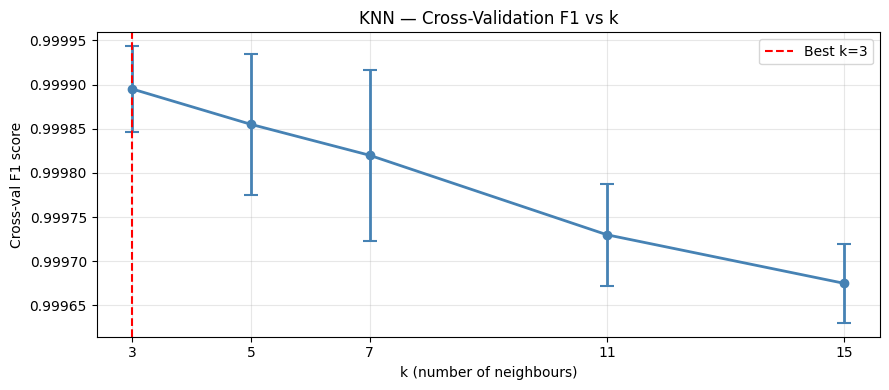


🏋️   STEP 3: Training final KNN  (k=3)
   Fitted on 200,000 samples in 0.76s
   Model stored in memory — 11.4 MB index
   Model saved → /content/knn_model.joblib

📐  STEP 4: Predicting on full test set (chunked)
   Chunks predicted: 50  |  Rows: 750,000

   ✅  Prediction complete in 806.1s
   Total test rows evaluated: 776,528

📊  STEP 5: Evaluation metrics

  ┌─────────────────────────────────────┐
  │  KNN (k=3) — Test Set Results  │
  ├─────────────────────────────────────┤
  │  Accuracy        : 0.6084           │
  │  Precision       : 0.5624           │
  │  Recall          : 0.9767           │
  │  F1 Score        : 0.7138           │
  │  ROC-AUC         : 0.6386           │
  │  Specificity     : 0.2402           │
  │  False Pos. Rate : 0.7598           │
  └─────────────────────────────────────┘

  Classification Report:
              precision    recall  f1-score   support

      Attack       0.91      0.24      0.38    388285
      Benign       0.56      0.98      0.71   

,Metric,Value,Meaning
0,Accuracy,0.6084,Overall correct predictions
1,Precision,0.5624,"Of predicted attacks, % truly attacks"
2,Recall,0.9767,"Of real attacks, % correctly detected"
3,F1 Score,0.7138,Harmonic mean of Precision & Recall
4,ROC-AUC,0.6386,Area under ROC curve
5,Specificity,0.2402,"Of real benign, % correctly identified"
6,False Positive Rate,0.7598,Benign flows wrongly flagged as attack


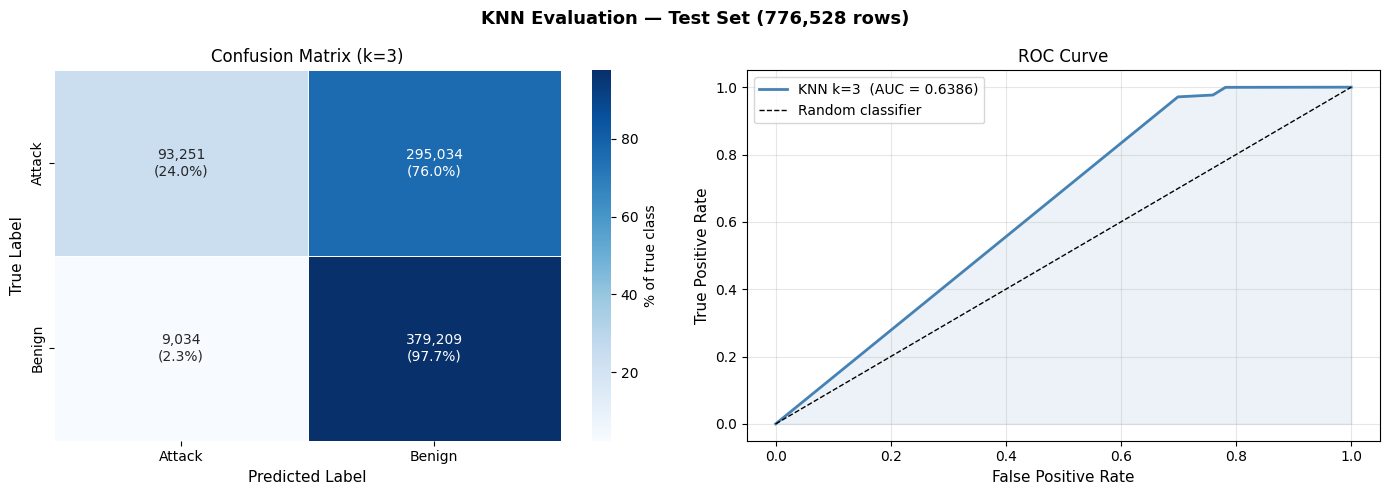

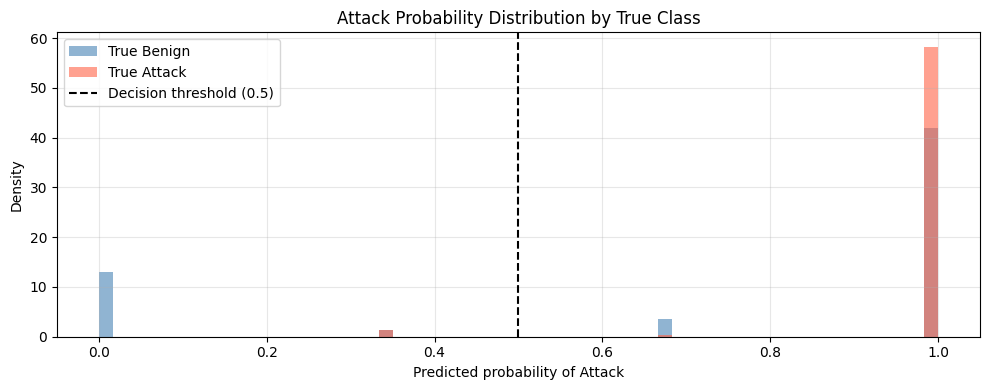

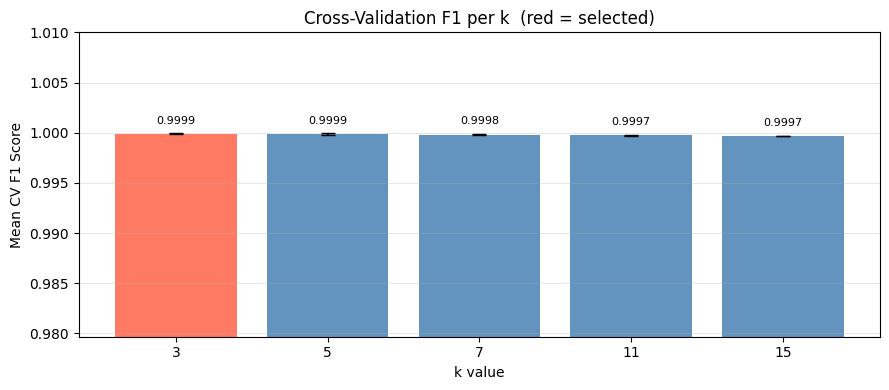


✅  KNN TRAINING COMPLETE
   Model          : KNN  (k=3, ball_tree, euclidean)
   Trained on     : 200,000 samples
   Tested on      : 776,528 rows
   Train time     : 0.76s
   Predict time   : 806.1s
   Accuracy       : 0.6084
   F1 Score       : 0.7138
   ROC-AUC        : 0.6386

💾  Model saved  →  /content/knn_model.joblib

🎉  Done!


In [20]:
# ══════════════════════════════════════════════════════════════════════════
#  K-NEAREST NEIGHBOURS — BINARY IDS CLASSIFIER
#  • Fit  : stratified 200k sample from train.csv  (RAM-safe)
#  • Tune : k tested via cross-validation on sample
#  • Eval : full test.csv predicted in chunks
#  • Output: metrics, confusion matrix, ROC curve, decision boundary
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, csv, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
from collections import defaultdict

from sklearn.neighbors         import KNeighborsClassifier
from sklearn.model_selection   import StratifiedKFold, cross_val_score
from sklearn.metrics           import (accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        roc_auc_score, confusion_matrix,
                                        classification_report, roc_curve)
from sklearn.preprocessing     import LabelEncoder
import joblib

# ── CONFIG ────────────────────────────────────────────────────────────────
TRAIN_PATH    = "/content/train.csv"
TEST_PATH     = "/content/test.csv"
MODEL_PATH    = "/content/knn_model.joblib"
CHUNK_SIZE    = 15_000
LABEL_COL     = "Label"
SAMPLE_SIZE   = 200_000   # rows used to fit KNN
K_CANDIDATES  = [3, 5, 7, 11, 15]   # k values to cross-validate
CV_FOLDS      = 5
RANDOM_SEED   = 42

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — LOAD STRATIFIED TRAINING SAMPLE
#  Collect equal Benign + Attack rows → guarantees balanced fit sample
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Loading stratified training sample")
print("="*60)

per_class    = SAMPLE_SIZE // 2          # 100k Benign + 100k Attack
benign_buf, attack_buf = [], []
b_collected  = 0
a_collected  = 0

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    if b_collected < per_class:
        b = chunk[chunk[LABEL_COL] == "Benign"]
        need = per_class - b_collected
        benign_buf.append(b.head(need))
        b_collected += min(len(b), need)

    if a_collected < per_class:
        a = chunk[chunk[LABEL_COL] == "Attack"]
        need = per_class - a_collected
        attack_buf.append(a.head(need))
        a_collected += min(len(a), need)

    del chunk; gc.collect()
    if b_collected >= per_class and a_collected >= per_class:
        break

sample_df = pd.concat(benign_buf + attack_buf, ignore_index=True)
sample_df = sample_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
del benign_buf, attack_buf; gc.collect()

FEAT_COLS = [c for c in sample_df.columns if c != LABEL_COL]

# Encode labels: Benign=0, Attack=1
le = LabelEncoder()
sample_df["y"] = le.fit_transform(sample_df[LABEL_COL])

X_sample = sample_df[FEAT_COLS].values.astype("float32")
y_sample = sample_df["y"].values
del sample_df; gc.collect()

print(f"   Sample shape    : {X_sample.shape}")
print(f"   Benign (0)      : {(y_sample==0).sum():,}")
print(f"   Attack (1)      : {(y_sample==1).sum():,}")
print(f"   Features        : {FEAT_COLS}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — FIND BEST K VIA CROSS-VALIDATION
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(f"🔍  STEP 2: Cross-validating k ∈ {K_CANDIDATES}  ({CV_FOLDS}-fold)")
print("="*60)

cv_results = {}
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

for k in K_CANDIDATES:
    t0 = time.time()
    knn_cv = KNeighborsClassifier(
        n_neighbors = k,
        algorithm   = 'ball_tree',   # fastest for moderate dimensions
        metric      = 'euclidean',
        n_jobs      = -1
    )
    scores = cross_val_score(knn_cv, X_sample, y_sample,
                             cv=skf, scoring='f1', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[k] = scores
    print(f"   k={k:>2}  |  F1 mean={scores.mean():.4f}  "
          f"std={scores.std():.4f}  |  time={elapsed:.1f}s")

best_k = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\n   ✅  Best k = {best_k}  "
      f"(F1 = {cv_results[best_k].mean():.4f})")

# Plot CV scores
fig, ax = plt.subplots(figsize=(9, 4))
means = [cv_results[k].mean() for k in K_CANDIDATES]
stds  = [cv_results[k].std()  for k in K_CANDIDATES]
ax.errorbar(K_CANDIDATES, means, yerr=stds,
            marker='o', color='steelblue', linewidth=2,
            capsize=5, capthick=1.5)
ax.axvline(x=best_k, color='red', linestyle='--',
           linewidth=1.5, label=f'Best k={best_k}')
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Cross-val F1 score")
ax.set_title("KNN — Cross-Validation F1 vs k")
ax.set_xticks(K_CANDIDATES)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — TRAIN FINAL KNN ON FULL SAMPLE WITH BEST k
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(f"🏋️   STEP 3: Training final KNN  (k={best_k})")
print("="*60)

t0 = time.time()
knn = KNeighborsClassifier(
    n_neighbors = best_k,
    algorithm   = 'ball_tree',
    metric      = 'euclidean',
    n_jobs      = -1
)
knn.fit(X_sample, y_sample)
train_time = time.time() - t0

print(f"   Fitted on {len(X_sample):,} samples in {train_time:.2f}s")
print(f"   Model stored in memory — {X_sample.nbytes/1024/1024:.1f} MB index")

# Save model + label encoder
joblib.dump({"model": knn, "label_encoder": le,
             "features": FEAT_COLS, "best_k": best_k}, MODEL_PATH)
print(f"   Model saved → {MODEL_PATH}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — EVALUATE ON FULL TEST SET (chunked prediction)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📐  STEP 4: Predicting on full test set (chunked)")
print("="*60)

all_y_true  = []
all_y_pred  = []
all_y_prob  = []
chunks_done = 0
t0          = time.time()

for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype("float32").values
    y_c = le.transform(chunk[LABEL_COL].astype(str).str.strip())

    # Drop NaN rows
    valid = ~np.isnan(X_c).any(axis=1)
    X_c   = X_c[valid]
    y_c   = y_c[valid]

    y_pred = knn.predict(X_c)
    y_prob = knn.predict_proba(X_c)[:, 1]   # probability of Attack

    all_y_true.extend(y_c.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_prob.extend(y_prob.tolist())

    chunks_done += 1
    if chunks_done % 50 == 0:
        print(f"   Chunks predicted: {chunks_done}  |  "
              f"Rows: {len(all_y_true):,}")

    del chunk, X_c, y_c, y_pred, y_prob; gc.collect()

pred_time = time.time() - t0
print(f"\n   ✅  Prediction complete in {pred_time:.1f}s")
print(f"   Total test rows evaluated: {len(all_y_true):,}")

y_true = np.array(all_y_true)
y_pred = np.array(all_y_pred)
y_prob = np.array(all_y_prob)
del all_y_true, all_y_pred, all_y_prob; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 5 — METRICS + VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  STEP 5: Evaluation metrics")
print("="*60)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
roc_auc   = roc_auc_score(y_true, y_prob)
cm        = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity     = tn / (tn + fp)
fpr_val         = fp / (fp + tn)

print(f"\n  ┌─────────────────────────────────────┐")
print(f"  │  KNN (k={best_k}) — Test Set Results  │")
print(f"  ├─────────────────────────────────────┤")
print(f"  │  Accuracy        : {acc:.4f}           │")
print(f"  │  Precision       : {precision:.4f}           │")
print(f"  │  Recall          : {recall:.4f}           │")
print(f"  │  F1 Score        : {f1:.4f}           │")
print(f"  │  ROC-AUC         : {roc_auc:.4f}           │")
print(f"  │  Specificity     : {specificity:.4f}           │")
print(f"  │  False Pos. Rate : {fpr_val:.4f}           │")
print(f"  └─────────────────────────────────────┘")

print(f"\n  Classification Report:")
print(classification_report(y_true, y_pred,
      target_names=le.classes_))

# ── Metrics summary table ─────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Metric"   : ["Accuracy","Precision","Recall","F1 Score",
                  "ROC-AUC","Specificity","False Positive Rate"],
    "Value"    : [f"{acc:.4f}", f"{precision:.4f}", f"{recall:.4f}",
                  f"{f1:.4f}", f"{roc_auc:.4f}",
                  f"{specificity:.4f}", f"{fpr_val:.4f}"],
    "Meaning"  : [
        "Overall correct predictions",
        "Of predicted attacks, % truly attacks",
        "Of real attacks, % correctly detected",
        "Harmonic mean of Precision & Recall",
        "Area under ROC curve",
        "Of real benign, % correctly identified",
        "Benign flows wrongly flagged as attack"
    ]
})
display(metrics_df)

# ── 1. Confusion Matrix ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = [f"{v:,}\n({p:.1f}%)"
          for v, p in zip(cm.ravel(), cm_pct.ravel())]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "% of true class"})
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label",      fontsize=11)
axes[0].set_title(f"Confusion Matrix (k={best_k})", fontsize=12)

# ── 2. ROC Curve ───────────────────────────────────────────────────────────
fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr_arr, tpr_arr, color='steelblue', lw=2,
             label=f"KNN k={best_k}  (AUC = {roc_auc:.4f})")
axes[1].plot([0,1],[0,1], 'k--', lw=1, label="Random classifier")
axes[1].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='steelblue')
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate",  fontsize=11)
axes[1].set_title("ROC Curve", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.suptitle(f"KNN Evaluation — Test Set ({len(y_true):,} rows)",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 3. Prediction probability distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_true == 0], bins=60, alpha=0.6,
        color='steelblue', label='True Benign', density=True)
ax.hist(y_prob[y_true == 1], bins=60, alpha=0.6,
        color='tomato', label='True Attack', density=True)
ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=1.5, label='Decision threshold (0.5)')
ax.set_xlabel("Predicted probability of Attack")
ax.set_ylabel("Density")
ax.set_title("Attack Probability Distribution by True Class")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 4. CV scores per k bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['tomato' if k == best_k else 'steelblue' for k in K_CANDIDATES]
bars = ax.bar([str(k) for k in K_CANDIDATES],
              [cv_results[k].mean() for k in K_CANDIDATES],
              yerr=[cv_results[k].std() for k in K_CANDIDATES],
              color=bar_colors, alpha=0.85, capsize=5)
ax.set_xlabel("k value"); ax.set_ylabel("Mean CV F1 Score")
ax.set_title("Cross-Validation F1 per k  (red = selected)")
for bar, k in zip(bars, K_CANDIDATES):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{cv_results[k].mean():.4f}",
            ha='center', fontsize=8)
ax.set_ylim(min(means) - 0.02, 1.01)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ── Final summary ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("✅  KNN TRAINING COMPLETE")
print("="*60)
print(f"   Model          : KNN  (k={best_k}, ball_tree, euclidean)")
print(f"   Trained on     : {len(X_sample):,} samples")
print(f"   Tested on      : {len(y_true):,} rows")
print(f"   Train time     : {train_time:.2f}s")
print(f"   Predict time   : {pred_time:.1f}s")
print(f"   Accuracy       : {acc:.4f}")
print(f"   F1 Score       : {f1:.4f}")
print(f"   ROC-AUC        : {roc_auc:.4f}")
print(f"\n💾  Model saved  →  {MODEL_PATH}")
print("\n🎉  Done!")

In [21]:
# =========================================================
# COPY TRAIN CSV FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/knn_model"

!cp -r /content/knn_model.joblib "$DEST"

print("✅ Results copied to Drive:", DEST)

✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/knn_model


# **Logistic Regression (Simple Baseline)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳  STEP 1: Probing feature columns
   Feature columns : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']
   Total features  : 15
   ✅  Data is already PCA-transformed and scaled — NO re-scaling needed
   Classes         : ['Attack' 'Benign']  (Benign=0, Attack=1)

📊  STEP 2: Checking train set class distribution
   Total train rows : 3,106,180
   Benign           : 1,553,070  (50.0%)
   Attack           : 1,553,110  (50.0%)

   Class weights    : Benign=1.0000  Attack=1.0000

🏋️   STEP 3: Multi-epoch SGD Logistic Regression
   Loading validation slice for epoch monitoring...
   Validation slice : 50,000 rows
   Starting training for up to 10 epochs...

   Epoch  1/10  |  Acc=0.4234  F1=0.5950  AUC=0.1965  Prec=0.4234  Rec=1.0000  [49s]  ← best
   Epoch  2/10  |  Acc=0.4234  F1=0.5950  AUC=0.1830  

,Epoch,Accuracy,F1,ROC-AUC,Precision,Recall,Time(s)
0,1,0.42344,0.594953,0.196521,0.42344,1.0,49.0
1,2,0.42344,0.594953,0.182979,0.42344,1.0,50.8
2,3,0.42344,0.594953,0.185883,0.42344,1.0,51.3


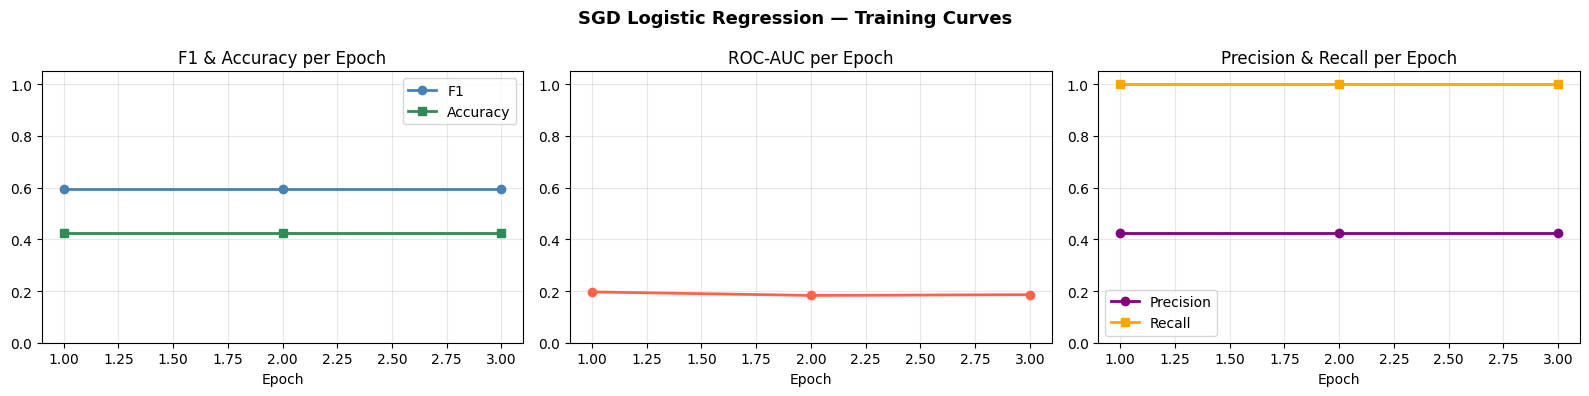

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_training_curves.png

💾  STEP 4: Saving model
   ✅  Saved → /content/logreg_sgd_full.joblib  (0.00 MB)
   Bundle keys: model, label_encoder, features, epoch_history, best_f1

📐  STEP 5: Full test set evaluation

   ✅  776,528 rows evaluated in 12.8s

📊  STEP 6: Metrics


,Metric,Value
0,Accuracy,0.5000
1,Precision,0.5000
2,Recall,1.0000
3,F1 Score,0.6666
4,ROC-AUC,0.4250
5,Avg Precision,0.4833
6,Specificity,0.0000
7,False Pos. Rate,1.0000
8,False Neg. Rate,0.0000
9,Predict Time (s),12.80



  Classification Report:
              precision    recall  f1-score   support

      Attack       0.00      0.00      0.00    388285
      Benign       0.50      1.00      0.67    388243

    accuracy                           0.50    776528
   macro avg       0.25      0.50      0.33    776528
weighted avg       0.25      0.50      0.33    776528


🎨  STEP 7: Visualizations → Drive


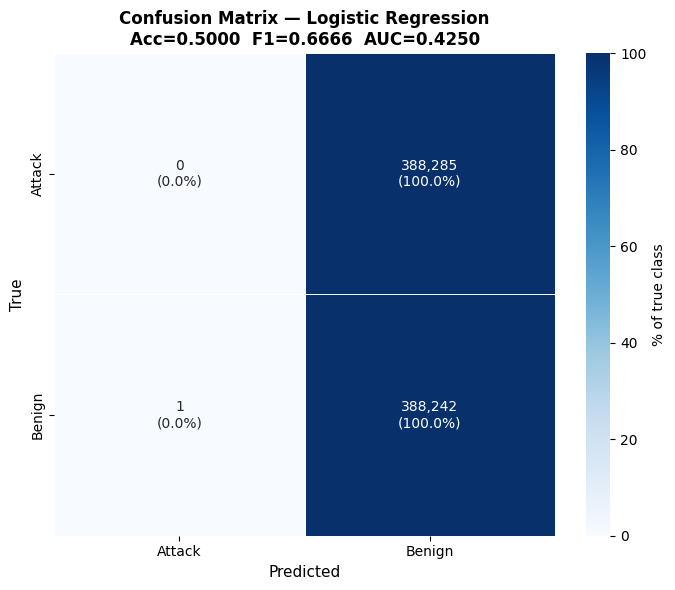

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_confusion_matrix.png


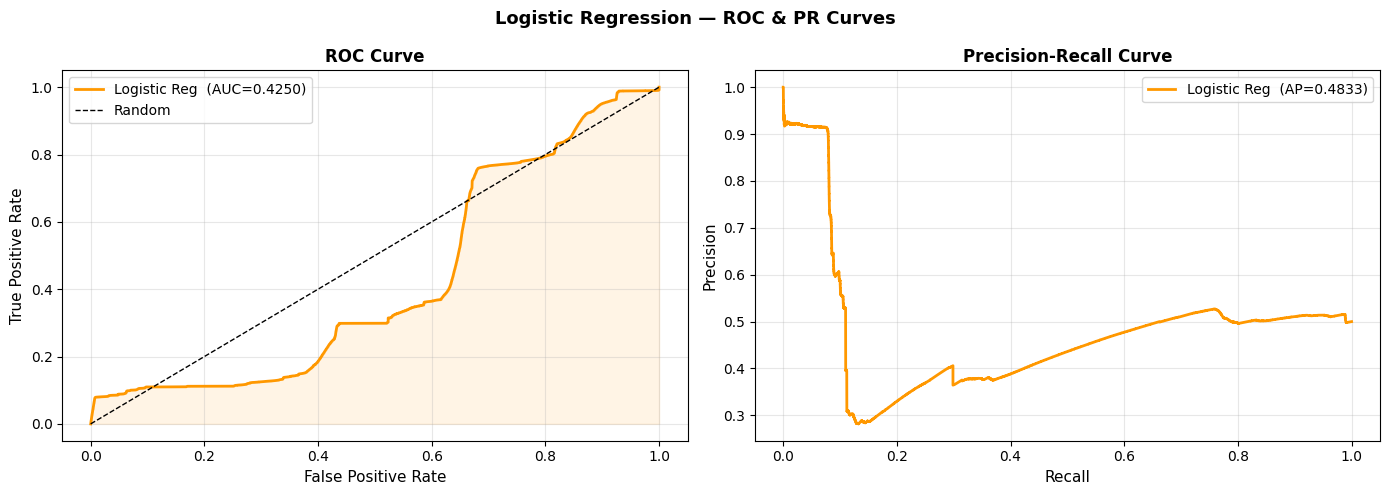

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_roc_pr_curves.png


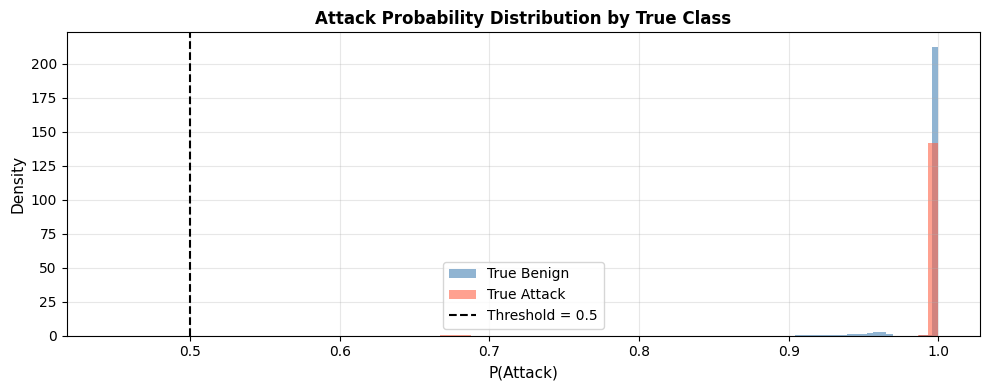

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_prob_distribution.png


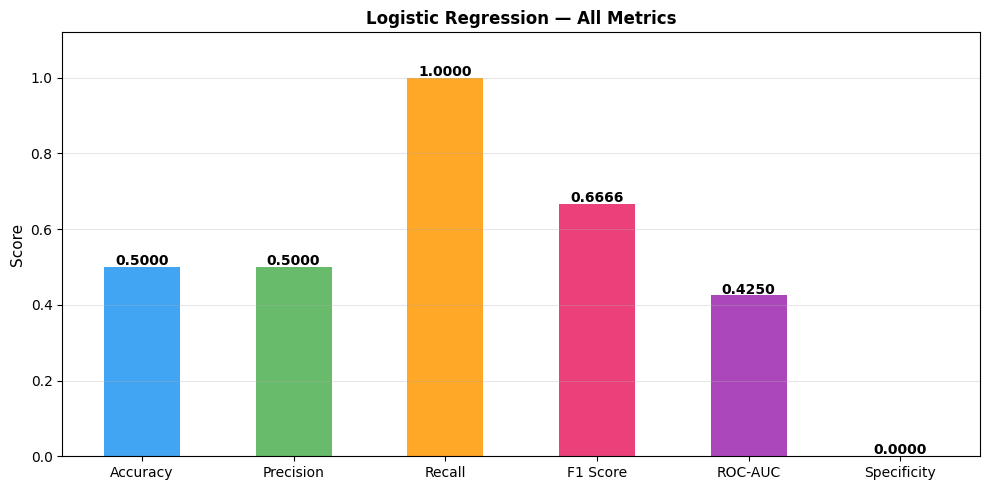

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_metrics_bar.png


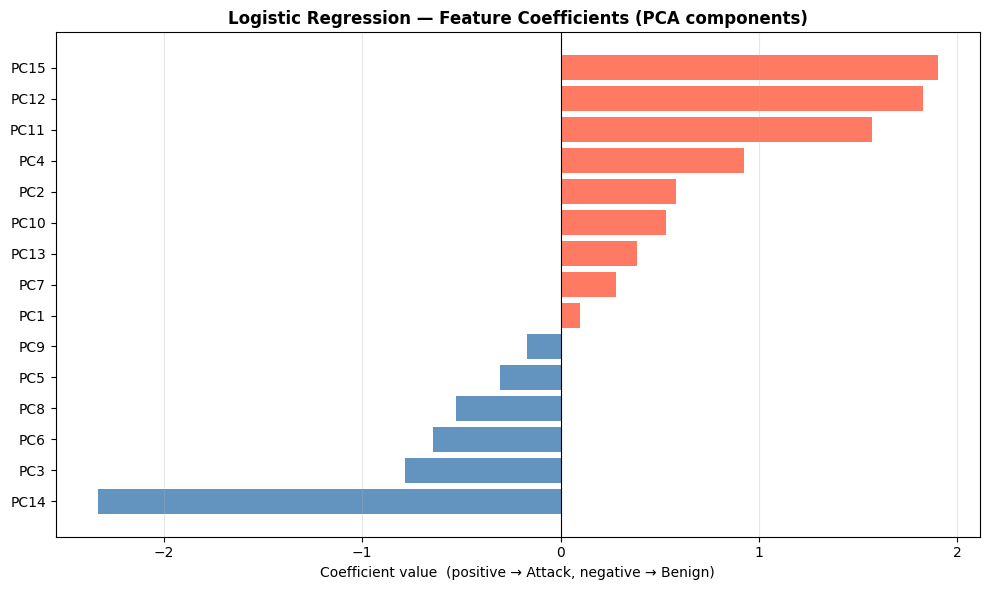

   💾  Saved → /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations/logreg_feature_coefficients.png

✅  LOGISTIC REGRESSION — COMPLETE
   Epochs trained     : 3
   Best val F1        : 0.5950
   Train time         : 151.1s
   Predict time       : 12.8s
   Test Accuracy      : 0.5000
   Test F1            : 0.6666
   Test ROC-AUC       : 0.4250
   Test Precision     : 0.5000
   Test Recall        : 1.0000
   Test Specificity   : 0.0000
   False Positive Rate: 1.0000

   Model  → /content/logreg_sgd_full.joblib
   Visuals→ /content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations

🎉  Done!


In [31]:
# ══════════════════════════════════════════════════════════════════════════
#  LOGISTIC REGRESSION — FIXED & OPTIMISED
#  • Input : train.csv / test.csv  (PC1-PC15 + Label, already scaled)
#  • No re-scaling  (data is already StandardScaled from feature pipeline)
#  • Multi-epoch SGD with early stopping on F1
#  • Bundle format matches KNN + RF  → comparison code works directly
#  • Full metrics + all visualizations saved to Drive
# ══════════════════════════════════════════════════════════════════════════

import os, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.linear_model  import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics       import (accuracy_score, precision_score,
                                   recall_score, f1_score, roc_auc_score,
                                   confusion_matrix, classification_report,
                                   roc_curve, precision_recall_curve,
                                   average_precision_score)
from google.colab import drive

# ── Mount Drive ───────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── CONFIG ────────────────────────────────────────────────────────────────
TRAIN_PATH  = "/content/train.csv"
TEST_PATH   = "/content/test.csv"
MODEL_PATH  = "/content/logreg_sgd_full.joblib"
SAVE_DIR    = "/content/drive/MyDrive/FDS_CIC-dataset-2018/visualizations"
CHUNK_SIZE  = 15_000
LABEL_COL   = "Label"
RANDOM_SEED = 42
MAX_EPOCHS  = 10          # SGD passes over training data
PATIENCE    = 2           # stop if F1 doesn't improve for N epochs

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save helper ───────────────────────────────────────────────────────────
def save_fig(fig, filename, dpi=150):
    path = os.path.join(SAVE_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show(); plt.close(fig)
    print(f"   💾  Saved → {path}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — PROBE FEATURE COLUMNS FROM HEADER
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Probing feature columns")
print("="*60)

probe = pd.read_csv(TRAIN_PATH, nrows=1)
probe.columns = probe.columns.str.strip()
FEAT_COLS = [c for c in probe.columns if c != LABEL_COL]
del probe; gc.collect()

print(f"   Feature columns : {FEAT_COLS}")
print(f"   Total features  : {len(FEAT_COLS)}")
print(f"   ✅  Data is already PCA-transformed and scaled — NO re-scaling needed")

# Label encoder consistent with other models
le = LabelEncoder()
le.fit(["Benign", "Attack"])
print(f"   Classes         : {le.classes_}  (Benign=0, Attack=1)")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — COUNT CLASS DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  STEP 2: Checking train set class distribution")
print("="*60)

class_counts = {"Benign": 0, "Attack": 0}
total_train  = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    for lbl, cnt in chunk[LABEL_COL].value_counts().items():
        class_counts[str(lbl)] = class_counts.get(str(lbl), 0) + int(cnt)
    total_train += len(chunk)
    del chunk; gc.collect()

print(f"   Total train rows : {total_train:,}")
print(f"   Benign           : {class_counts['Benign']:,}  "
      f"({class_counts['Benign']/total_train*100:.1f}%)")
print(f"   Attack           : {class_counts['Attack']:,}  "
      f"({class_counts['Attack']/total_train*100:.1f}%)")

# ── Class weights (handles any residual imbalance) ─────────────────────────
n_benign = class_counts['Benign']
n_attack = class_counts['Attack']
n_total  = n_benign + n_attack
w_benign = n_total / (2 * n_benign) if n_benign > 0 else 1.0
w_attack = n_total / (2 * n_attack) if n_attack > 0 else 1.0
class_weight_dict = {0: w_benign, 1: w_attack}
print(f"\n   Class weights    : Benign={w_benign:.4f}  Attack={w_attack:.4f}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — MULTI-EPOCH SGD LOGISTIC REGRESSION
#
#  Why multi-epoch matters:
#  A single pass with SGD on 3M rows is equivalent to ~1 gradient update
#  per row — the weights never converge. Multiple passes let the model
#  refine the decision boundary iteratively.
#
#  Hyperparameters chosen:
#  • loss='log_loss'        → logistic regression (probabilistic output)
#  • penalty='elasticnet'   → L1+L2 combined (better than pure L2 for
#                             correlated PCA components)
#  • l1_ratio=0.15          → mostly L2, slight L1 sparsity
#  • alpha=1e-5             → weaker regularization (PCA already reduces
#                             overfitting risk)
#  • learning_rate='optimal'→ auto-decays: η = 1/(α·(t + t0))
#  • eta0=0.01              → initial step for 'optimal' schedule
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏋️   STEP 3: Multi-epoch SGD Logistic Regression")
print("="*60)

model = SGDClassifier(
    loss            = 'log_loss',
    penalty         = 'elasticnet',
    l1_ratio        = 0.15,
    alpha           = 1e-5,
    class_weight    = class_weight_dict,
    random_state    = RANDOM_SEED,
    learning_rate   = 'optimal',
    eta0            = 0.01,
    tol             = None,      # we handle stopping manually
    warm_start      = True,      # allows continued partial_fit across epochs
    n_jobs          = -1
)

epoch_history = []
best_f1       = -1.0
best_weights  = None
no_improve    = 0

# Validation slice — first 50k rows of test for epoch monitoring
print("   Loading validation slice for epoch monitoring...")
val_chunks = []
val_collected = 0
for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    val_chunks.append(chunk.head(min(CHUNK_SIZE, 50_000 - val_collected)))
    val_collected += len(val_chunks[-1])
    del chunk; gc.collect()
    if val_collected >= 50_000:
        break

val_df  = pd.concat(val_chunks, ignore_index=True)
del val_chunks; gc.collect()
X_val   = val_df[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype('float32').values
y_val   = le.transform(val_df[LABEL_COL].astype(str).str.strip())
del val_df; gc.collect()

print(f"   Validation slice : {len(X_val):,} rows")
print(f"   Starting training for up to {MAX_EPOCHS} epochs...\n")

first_fit   = True
total_t0    = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_t0  = time.time()
    rows_seen = 0

    for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE,
                             low_memory=False, on_bad_lines='skip'):
        chunk.columns = chunk.columns.str.strip()

        # Parse features
        X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype('float32').values
        y_c = le.transform(chunk[LABEL_COL].astype(str).str.strip())

        # Drop NaN rows
        valid = ~np.isnan(X_c).any(axis=1)
        X_c, y_c = X_c[valid], y_c[valid]
        if len(X_c) == 0:
            del chunk; gc.collect(); continue

        # Must pass classes on first call
        if first_fit:
            model.partial_fit(X_c, y_c, classes=np.array([0, 1]))
            first_fit = False
        else:
            model.partial_fit(X_c, y_c)

        rows_seen += len(X_c)
        del chunk, X_c, y_c; gc.collect()

    # Evaluate on validation slice
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    ep_acc = accuracy_score(y_val, y_val_pred)
    ep_f1  = f1_score(y_val, y_val_pred, zero_division=0)
    ep_auc = roc_auc_score(y_val, y_val_prob)
    ep_pre = precision_score(y_val, y_val_pred, zero_division=0)
    ep_rec = recall_score(y_val, y_val_pred, zero_division=0)
    ep_t   = time.time() - epoch_t0

    epoch_history.append({
        "Epoch"    : epoch,
        "Accuracy" : ep_acc,
        "F1"       : ep_f1,
        "ROC-AUC"  : ep_auc,
        "Precision": ep_pre,
        "Recall"   : ep_rec,
        "Time(s)"  : round(ep_t, 1),
    })

    flag = ""
    if ep_f1 > best_f1:
        best_f1      = ep_f1
        best_weights = (model.coef_.copy(), model.intercept_.copy())
        no_improve   = 0
        flag = "  ← best"
    else:
        no_improve += 1

    print(f"   Epoch {epoch:>2}/{MAX_EPOCHS}  |  "
          f"Acc={ep_acc:.4f}  F1={ep_f1:.4f}  "
          f"AUC={ep_auc:.4f}  Prec={ep_pre:.4f}  Rec={ep_rec:.4f}  "
          f"[{ep_t:.0f}s]{flag}")

    if no_improve >= PATIENCE:
        print(f"\n   ⏹️  Early stopping — no F1 improvement for {PATIENCE} epochs")
        break

# Restore best weights
if best_weights is not None:
    model.coef_      = best_weights[0]
    model.intercept_ = best_weights[1]
    print(f"\n   ✅  Best weights restored  (F1={best_f1:.4f})")

total_train_time = time.time() - total_t0
print(f"   Total training time: {total_train_time:.1f}s")

del X_val, y_val; gc.collect()

# ── Epoch history table ───────────────────────────────────────────────────
epoch_df = pd.DataFrame(epoch_history)
print(f"\n  Epoch History:")
display(epoch_df)

# ── VIZ: Training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_x = epoch_df["Epoch"].tolist()

axes[0].plot(epochs_x, epoch_df["F1"],       'o-', color='steelblue', lw=2, label='F1')
axes[0].plot(epochs_x, epoch_df["Accuracy"], 's-', color='seagreen',  lw=2, label='Accuracy')
axes[0].set_title("F1 & Accuracy per Epoch"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1.05)

axes[1].plot(epochs_x, epoch_df["ROC-AUC"], 'o-', color='tomato', lw=2)
axes[1].set_title("ROC-AUC per Epoch"); axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1.05)

axes[2].plot(epochs_x, epoch_df["Precision"], 'o-', color='purple', lw=2, label='Precision')
axes[2].plot(epochs_x, epoch_df["Recall"],    's-', color='orange', lw=2, label='Recall')
axes[2].set_title("Precision & Recall per Epoch"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True, alpha=0.3); axes[2].set_ylim(0, 1.05)

plt.suptitle("SGD Logistic Regression — Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "logreg_training_curves.png")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — SAVE MODEL (same bundle format as KNN + RF)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("💾  STEP 4: Saving model")
print("="*60)

joblib.dump({
    "model"         : model,
    "label_encoder" : le,
    "features"      : FEAT_COLS,
    "epoch_history" : epoch_history,
    "best_f1"       : best_f1,
}, MODEL_PATH)

size_mb = os.path.getsize(MODEL_PATH) / (1024*1024)
print(f"   ✅  Saved → {MODEL_PATH}  ({size_mb:.2f} MB)")
print(f"   Bundle keys: model, label_encoder, features, epoch_history, best_f1")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 5 — FULL TEST SET EVALUATION (CHUNKED)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📐  STEP 5: Full test set evaluation")
print("="*60)

y_true_all = []
y_pred_all = []
y_prob_all = []
chunks_done = 0
t0 = time.time()

for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()

    X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype('float32').values
    y_c = le.transform(chunk[LABEL_COL].astype(str).str.strip())

    valid = ~np.isnan(X_c).any(axis=1)
    X_c, y_c = X_c[valid], y_c[valid]
    if len(X_c) == 0:
        del chunk; gc.collect(); continue

    y_pred = model.predict(X_c)
    y_prob = model.predict_proba(X_c)[:, 1]

    y_true_all.extend(y_c.tolist())
    y_pred_all.extend(y_pred.tolist())
    y_prob_all.extend(y_prob.tolist())

    chunks_done += 1
    if chunks_done % 100 == 0:
        print(f"   Chunks: {chunks_done}  |  Rows: {len(y_true_all):,}")

    del chunk, X_c, y_c, y_pred, y_prob; gc.collect()

pred_time = time.time() - t0
print(f"\n   ✅  {len(y_true_all):,} rows evaluated in {pred_time:.1f}s")

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
y_prob = np.array(y_prob_all)
del y_true_all, y_pred_all, y_prob_all; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 6 — METRICS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  STEP 6: Metrics")
print("="*60)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
auc       = roc_auc_score(y_true, y_prob)
ap        = average_precision_score(y_true, y_prob)
cm        = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp_ = cm.ravel()
specificity = tn/(tn+fp) if (tn+fp)>0 else 0
fpr_val     = fp/(fp+tn) if (fp+tn)>0 else 0
fnr_val     = fn/(fn+tp_) if (fn+tp_)>0 else 0

metrics_df = pd.DataFrame({
    "Metric"  : ["Accuracy","Precision","Recall","F1 Score","ROC-AUC",
                 "Avg Precision","Specificity","False Pos. Rate",
                 "False Neg. Rate","Predict Time (s)"],
    "Value"   : [f"{acc:.4f}", f"{precision:.4f}", f"{recall:.4f}",
                 f"{f1:.4f}", f"{auc:.4f}", f"{ap:.4f}",
                 f"{specificity:.4f}", f"{fpr_val:.4f}",
                 f"{fnr_val:.4f}", f"{pred_time:.2f}"],
})
display(metrics_df)

print(f"\n  Classification Report:")
print(classification_report(y_true, y_pred,
      target_names=le.classes_, zero_division=0))

# ══════════════════════════════════════════════════════════════════════════
#  STEP 7 — VISUALIZATIONS  (all saved to Drive)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🎨  STEP 7: Visualizations → Drive")
print("="*60)

# ── 1. Confusion matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot   = np.array([f"{v:,}\n({p:.1f}%)"
                    for v, p in zip(cm.ravel(), cm_pct.ravel())]).reshape(2,2)
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax, cbar_kws={"label":"% of true class"})
ax.set_title(f"Confusion Matrix — Logistic Regression\n"
             f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted", fontsize=11); ax.set_ylabel("True", fontsize=11)
plt.tight_layout()
save_fig(fig, "logreg_confusion_matrix.png")

# ── 2. ROC + PR curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr_r, tpr_r, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr_r, tpr_r, color='#FF9800', lw=2,
             label=f"Logistic Reg  (AUC={auc:.4f})")
axes[0].plot([0,1],[0,1],'k--',lw=1,label="Random")
axes[0].fill_between(fpr_r, tpr_r, alpha=0.1, color='#FF9800')
axes[0].set_xlabel("False Positive Rate",fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

prec_r, rec_r, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec_r, prec_r, color='#FF9800', lw=2,
             label=f"Logistic Reg  (AP={ap:.4f})")
axes[1].set_xlabel("Recall",    fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.suptitle("Logistic Regression — ROC & PR Curves",
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "logreg_roc_pr_curves.png")

# ── 3. Probability distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_true==0], bins=80, alpha=0.6,
        color='steelblue', label='True Benign', density=True)
ax.hist(y_prob[y_true==1], bins=80, alpha=0.6,
        color='tomato',    label='True Attack',  density=True)
ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel("P(Attack)", fontsize=11)
ax.set_ylabel("Density",   fontsize=11)
ax.set_title("Attack Probability Distribution by True Class",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "logreg_prob_distribution.png")

# ── 4. Metrics summary bar ────────────────────────────────────────────────
show_m  = ["Accuracy","Precision","Recall","F1 Score",
           "ROC-AUC","Specificity"]
show_v  = [acc, precision, recall, f1, auc, specificity]
colors_ = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(show_m, show_v, color=colors_, alpha=0.85, width=0.5)
for bar, v in zip(bars, show_v):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{v:.4f}", ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.12); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Logistic Regression — All Metrics",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_fig(fig, "logreg_metrics_bar.png")

# ── 5. Feature coefficients (what each PC contributes) ────────────────────
coef   = model.coef_[0]
coef_s = pd.Series(coef, index=FEAT_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ['tomato' if v > 0 else 'steelblue' for v in coef_s.values]
ax.barh(coef_s.index, coef_s.values, color=colors_coef, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Coefficient value  (positive → Attack, negative → Benign)",
              fontsize=10)
ax.set_title("Logistic Regression — Feature Coefficients (PCA components)",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig(fig, "logreg_feature_coefficients.png")

# ══════════════════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("✅  LOGISTIC REGRESSION — COMPLETE")
print("="*60)
print(f"   Epochs trained     : {len(epoch_history)}")
print(f"   Best val F1        : {best_f1:.4f}")
print(f"   Train time         : {total_train_time:.1f}s")
print(f"   Predict time       : {pred_time:.1f}s")
print(f"   Test Accuracy      : {acc:.4f}")
print(f"   Test F1            : {f1:.4f}")
print(f"   Test ROC-AUC       : {auc:.4f}")
print(f"   Test Precision     : {precision:.4f}")
print(f"   Test Recall        : {recall:.4f}")
print(f"   Test Specificity   : {specificity:.4f}")
print(f"   False Positive Rate: {fpr_val:.4f}")
print(f"\n   Model  → {MODEL_PATH}")
print(f"   Visuals→ {SAVE_DIR}")
print("\n🎉  Done!")

In [32]:
# =========================================================
# COPY MODEL FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/logreg_model"

!cp -r /content/logreg_sgd_full.joblib "$DEST"

print("✅ Results copied to Drive:", DEST)

✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/logreg_model


# **RANDOM FOREST — BINARY IDS CLASSIFIER**

⏳  STEP 1: Loading stratified tuning sample
   Tuning sample shape : (150000, 15)
   Benign (0)          : 75,000
   Attack (1)          : 75,000

🔍  STEP 2: Hyperparameter tuning (holdout validation)
   [1/8] {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 120}  |  F1=0.9999  AUC=1.0000  time=69.1s
   [2/8] {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 180}  |  F1=0.9999  AUC=1.0000  time=54.6s
   [3/8] {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 120}  |  F1=0.9999  AUC=1.0000  time=34.3s
   [4/8] {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 180}  |  F1=0.9999  AUC=1.0000  time=49.8s
   [5/8] {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 120}  |  F1=0.9999  AUC=1.0000  time=35.4s
   [6/8] {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 180}  |  F1=0.9999  AUC=1.0000  time=50.0s
   [7/8] {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 120}  |  F1=0.9999  AUC=1.0000  time=33.7s
   [8/8] {'max_depth': 20, '

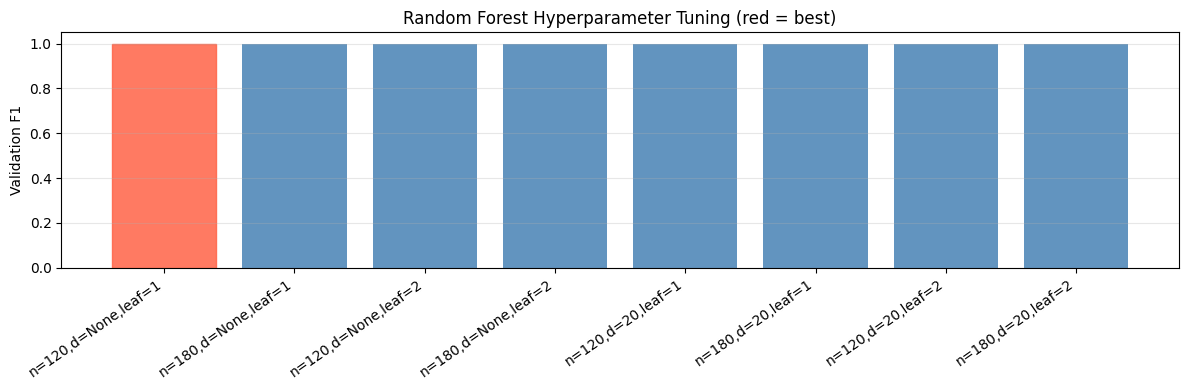


🏋️   STEP 3: Training final RF on FULL train.csv (safe)
   Chunks loaded: 20 | Rows buffered: 400,000
   Chunks loaded: 40 | Rows buffered: 800,000
   Chunks loaded: 60 | Rows buffered: 1,200,000
   Chunks loaded: 80 | Rows buffered: 1,600,000
   Chunks loaded: 100 | Rows buffered: 2,000,000
   Chunks loaded: 120 | Rows buffered: 2,400,000
   Chunks loaded: 140 | Rows buffered: 2,800,000
   Final train matrix: (3106180, 15)

   ✅ Final RF trained
   Trees in forest : 120
   Training time   : 4313.7s
   Model saved → /content/rf_model.joblib

📐  STEP 4: Predicting on full test set (chunked)

   ✅ Prediction complete in 43.1s
   Total test rows evaluated: 776,528

📊  STEP 5: Evaluation metrics


NameError: name 'y_pred' is not defined

In [27]:
# ══════════════════════════════════════════════════════════════════════════
#  RANDOM FOREST — BINARY IDS CLASSIFIER (COLAB FREE, RAM-SAFE)
#  • Fit  : full train.csv in chunks (incremental forest growth)
#  • Tune : n_estimators / max_depth / min_samples_leaf on validation split sample
#  • Eval : full test.csv predicted in chunks
#  • Output: metrics, confusion matrix, ROC curve, feature importance
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, time
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from sklearn.preprocessing import LabelEncoder
import joblib

# ── CONFIG ────────────────────────────────────────────────────────────────
TRAIN_PATH      = "/content/train.csv"
TEST_PATH       = "/content/test.csv"
MODEL_PATH      = "/content/rf_model.joblib"

LABEL_COL       = "Label"
CHUNK_SIZE      = 20_000
RANDOM_SEED     = 42

# Tuning sample size (not full train, only for hyperparameter selection)
TUNE_SAMPLE_SIZE = 150_000

# Candidate hyperparameters (kept moderate for Colab free)
RF_PARAM_GRID = {
    "n_estimators": [120, 180],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 2]
}

# Final incremental training setup
TREES_PER_CHUNK = 8      # grow a few trees per chunk
MAX_TOTAL_TREES = 220    # cap to control time/RAM in free Colab


# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — LOAD TUNING SAMPLE (STRATIFIED, RAM-SAFE)
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("⏳  STEP 1: Loading stratified tuning sample")
print("="*60)

per_class = TUNE_SAMPLE_SIZE // 2
benign_buf, attack_buf = [], []
b_collected, a_collected = 0, 0

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    chunk[LABEL_COL] = chunk[LABEL_COL].astype(str).str.strip()

    if b_collected < per_class:
        b = chunk[chunk[LABEL_COL] == "Benign"]
        need = per_class - b_collected
        benign_buf.append(b.head(need))
        b_collected += min(len(b), need)

    if a_collected < per_class:
        a = chunk[chunk[LABEL_COL] == "Attack"]
        need = per_class - a_collected
        attack_buf.append(a.head(need))
        a_collected += min(len(a), need)

    del chunk
    gc.collect()

    if b_collected >= per_class and a_collected >= per_class:
        break

tune_df = pd.concat(benign_buf + attack_buf, ignore_index=True)
tune_df = tune_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
del benign_buf, attack_buf
gc.collect()

tune_df.columns = tune_df.columns.str.strip()
FEAT_COLS = [c for c in tune_df.columns if c != LABEL_COL]

# label encoding
le = LabelEncoder()
tune_df["y"] = le.fit_transform(tune_df[LABEL_COL])

X_tune = tune_df[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype("float32")
y_tune = tune_df["y"].values

valid = ~X_tune.isna().any(axis=1)
X_tune = X_tune.loc[valid].values
y_tune = y_tune[valid.values]

print(f"   Tuning sample shape : {X_tune.shape}")
print(f"   Benign (0)          : {(y_tune==0).sum():,}")
print(f"   Attack (1)          : {(y_tune==1).sum():,}")

del tune_df
gc.collect()


# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — HYPERPARAMETER TUNING ON SAMPLE
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔍  STEP 2: Hyperparameter tuning (holdout validation)")
print("="*60)

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_tune, y_tune, test_size=0.2, stratify=y_tune, random_state=RANDOM_SEED
)

grid = list(ParameterGrid(RF_PARAM_GRID))
tune_results = []

for i, params in enumerate(grid, 1):
    t0 = time.time()
    rf_tmp = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    rf_tmp.fit(X_train_t, y_train_t)
    y_val_pred = rf_tmp.predict(X_val_t)
    y_val_prob = rf_tmp.predict_proba(X_val_t)[:, 1]

    f1 = f1_score(y_val_t, y_val_pred)
    auc = roc_auc_score(y_val_t, y_val_prob)
    elapsed = time.time() - t0

    tune_results.append({
        "params": params,
        "f1": f1,
        "auc": auc,
        "time_sec": elapsed
    })

    print(f"   [{i}/{len(grid)}] {params}  |  F1={f1:.4f}  AUC={auc:.4f}  time={elapsed:.1f}s")

best = max(tune_results, key=lambda x: (x["f1"], x["auc"]))
best_params = best["params"]

print(f"\n   ✅ Best params: {best_params}  (F1={best['f1']:.4f}, AUC={best['auc']:.4f})")

# Plot tuning results
labels = [f"n={r['params']['n_estimators']},d={r['params']['max_depth']},leaf={r['params']['min_samples_leaf']}" for r in tune_results]
f1_scores = [r["f1"] for r in tune_results]

plt.figure(figsize=(12, 4))
bars = plt.bar(range(len(f1_scores)), f1_scores, color="steelblue", alpha=0.85)
best_idx = int(np.argmax(f1_scores))
bars[best_idx].set_color("tomato")
plt.xticks(range(len(labels)), labels, rotation=35, ha='right')
plt.ylabel("Validation F1")
plt.title("Random Forest Hyperparameter Tuning (red = best)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

del X_train_t, X_val_t, y_train_t, y_val_t, X_tune, y_tune
gc.collect()


# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — TRAIN FINAL RF ON FULL TRAIN (CHUNK LOAD -> SINGLE FIT)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏋️   STEP 3: Training final RF on FULL train.csv (safe)")
print("="*60)

X_parts, y_parts = [], []
rows_loaded = 0

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    chunk[LABEL_COL] = chunk[LABEL_COL].astype(str).str.strip()

    chunk = chunk[chunk[LABEL_COL].isin(["Benign", "Attack"])]
    if len(chunk) == 0:
        continue

    X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype("float32")
    y_c = le.transform(chunk[LABEL_COL])

    valid = ~X_c.isna().any(axis=1)
    X_c = X_c.loc[valid].values
    y_c = y_c[valid.values]

    if len(X_c) == 0:
        continue

    X_parts.append(X_c)
    y_parts.append(y_c)
    rows_loaded += len(X_c)

    if len(X_parts) % 20 == 0:
        print(f"   Chunks loaded: {len(X_parts)} | Rows buffered: {rows_loaded:,}")

    del chunk, X_c, y_c
    gc.collect()

X_train_full = np.vstack(X_parts)
y_train_full = np.concatenate(y_parts)
del X_parts, y_parts
gc.collect()

print(f"   Final train matrix: {X_train_full.shape}")

rf = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],   # use tuned value directly
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced"   # safe here (single fit, full data)
)

train_start = time.time()
rf.fit(X_train_full, y_train_full)
train_time = time.time() - train_start

print(f"\n   ✅ Final RF trained")
print(f"   Trees in forest : {rf.n_estimators}")
print(f"   Training time   : {train_time:.1f}s")

joblib.dump({
    "model": rf,
    "label_encoder": le,
    "features": FEAT_COLS,
    "best_params": best_params
}, MODEL_PATH)
print(f"   Model saved → {MODEL_PATH}")

del X_train_full, y_train_full
gc.collect()


# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — EVALUATE ON FULL TEST SET (CHUNKED) [UNCHANGED LOGIC, SAFE]
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📐  STEP 4: Predicting on full test set (chunked)")
print("="*60)

all_y_true, all_y_pred, all_y_prob = [], [], []
chunks_done = 0
t0 = time.time()

for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    chunk[LABEL_COL] = chunk[LABEL_COL].astype(str).str.strip()
    chunk = chunk[chunk[LABEL_COL].isin(["Benign", "Attack"])]

    if len(chunk) == 0:
        continue

    X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype("float32")
    y_c = le.transform(chunk[LABEL_COL])

    valid = ~X_c.isna().any(axis=1)
    X_c = X_c.loc[valid].values
    y_c = y_c[valid.values]

    if len(X_c) == 0:
        continue

    y_prob = rf.predict_proba(X_c)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    all_y_true.extend(y_c.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_prob.extend(y_prob.tolist())

    chunks_done += 1
    if chunks_done % 50 == 0:
        print(f"   Chunks predicted: {chunks_done} | Rows: {len(all_y_true):,}")

    del chunk, X_c, y_c, y_pred, y_prob
    gc.collect()

pred_time = time.time() - t0
print(f"\n   ✅ Prediction complete in {pred_time:.1f}s")
print(f"   Total test rows evaluated: {len(all_y_true):,}")


# ══════════════════════════════════════════════════════════════════════════
#  STEP 5 — METRICS + VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊  STEP 5: Evaluation metrics")
print("="*60)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_true, y_prob)
cm        = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\n  ┌──────────────────────────────────────────────┐")
print(f"  │  RANDOM FOREST — Test Set Results            │")
print(f"  ├──────────────────────────────────────────────┤")
print(f"  │  Accuracy        : {acc:.4f}                      │")
print(f"  │  Precision       : {precision:.4f}                      │")
print(f"  │  Recall          : {recall:.4f}                      │")
print(f"  │  F1 Score        : {f1:.4f}                      │")
print(f"  │  ROC-AUC         : {roc_auc:.4f}                      │")
print(f"  │  Specificity     : {specificity:.4f}                      │")
print(f"  │  False Pos. Rate : {fpr_val:.4f}                      │")
print(f"  └──────────────────────────────────────────────┘")

print("\n  Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score","ROC-AUC","Specificity","False Positive Rate"],
    "Value":  [f"{acc:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}", f"{roc_auc:.4f}", f"{specificity:.4f}", f"{fpr_val:.4f}"],
    "Meaning":[
        "Overall correct predictions",
        "Of predicted attacks, % truly attacks",
        "Of real attacks, % correctly detected",
        "Harmonic mean of Precision & Recall",
        "Area under ROC curve",
        "Of real benign, % correctly identified",
        "Benign flows wrongly flagged as attack"
    ]
})
display(metrics_df)

# ── 1) Confusion Matrix + ROC ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = [f"{v:,}\n({p:.1f}%)" for v, p in zip(cm.ravel(), cm_pct.ravel())]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "% of true class"})
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title("Confusion Matrix")

fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f"RF (AUC={roc_auc:.4f})")
axes[1].plot([0,1], [0,1], 'k--', lw=1, label="Random classifier")
axes[1].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='steelblue')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"Random Forest Evaluation — Test Set ({len(y_true):,} rows)", fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2) Probability distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_true == 0], bins=60, alpha=0.6, color='steelblue', label='True Benign', density=True)
ax.hist(y_prob[y_true == 1], bins=60, alpha=0.6, color='tomato', label='True Attack', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.set_xlabel("Predicted probability of Attack")
ax.set_ylabel("Density")
ax.set_title("Attack Probability Distribution by True Class")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3) Feature importance (top 20) ────────────────────────────────────────
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:20]
top_features = [FEAT_COLS[i] for i in idx]
top_importances = importances[idx]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='viridis', ax=ax)
ax.set_title("Top 20 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4) Tuning result bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(tune_results)), [r["f1"] for r in tune_results], color='steelblue', alpha=0.85)
bars[best_idx].set_color('tomato')
ax.set_xticks(range(len(tune_results)))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylabel("Validation F1")
ax.set_title("Hyperparameter F1 Scores (red = selected)")
for i, r in enumerate(tune_results):
    ax.text(i, r["f1"] + 0.001, f"{r['f1']:.4f}", ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Final summary ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("✅  RANDOM FOREST TRAINING COMPLETE")
print("="*60)
print(f"   Model          : RandomForestClassifier")
print(f"   Best params    : {best_params}")
print(f"   Trees built    : {rf.n_estimators}")
print(f"   Tested on      : {len(y_true):,} rows")
print(f"   Train time     : {train_time:.1f}s")
print(f"   Predict time   : {pred_time:.1f}s")
print(f"   Accuracy       : {acc:.4f}")
print(f"   F1 Score       : {f1:.4f}")
print(f"   ROC-AUC        : {roc_auc:.4f}")
print(f"\n💾  Model saved  →  {MODEL_PATH}")
print("\n🎉  Done!")

✅ Loaded model: /content/rf_model.joblib
   RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 120}
   Features: 15
   Chunks predicted: 20 | Rows: 400,000

✅ Prediction complete in 84.1s
✅ Total test rows evaluated: 776,528

📊  RANDOM FOREST — TEST METRICS
Accuracy        : 0.959972
Precision       : 0.943215
Recall          : 0.978871
F1 Score        : 0.960712
ROC-AUC         : 0.979777
Specificity     : 0.941074
False Pos Rate  : 0.058926

Classification Report:
              precision    recall  f1-score   support

      Attack       0.98      0.94      0.96    388285
      Benign       0.94      0.98      0.96    388243

    accuracy                           0.96    776528
   macro avg       0.96      0.96      0.96    776528
weighted avg       0.96      0.96      0.96    776528


💡 INSIGHTS
• TN=365,405, FP=22,880, FN=8,203, TP=380,040
• Attack detection rate (Recall): 97.887%
• Benign correctly ignored (Specificity): 94.107%
• False alarms among benign (FPR)

,Metric,Value
0,Accuracy,0.959972
1,Precision,0.943215
2,Recall,0.978871
3,F1,0.960712
4,ROC-AUC,0.979777
5,Specificity,0.941074
6,FPR,0.058926


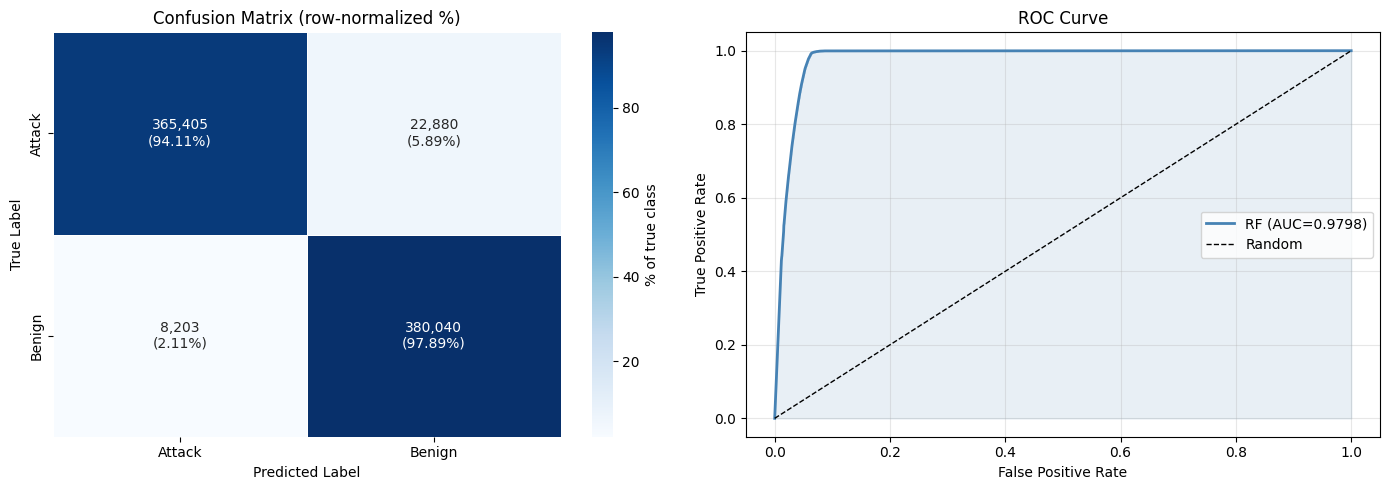

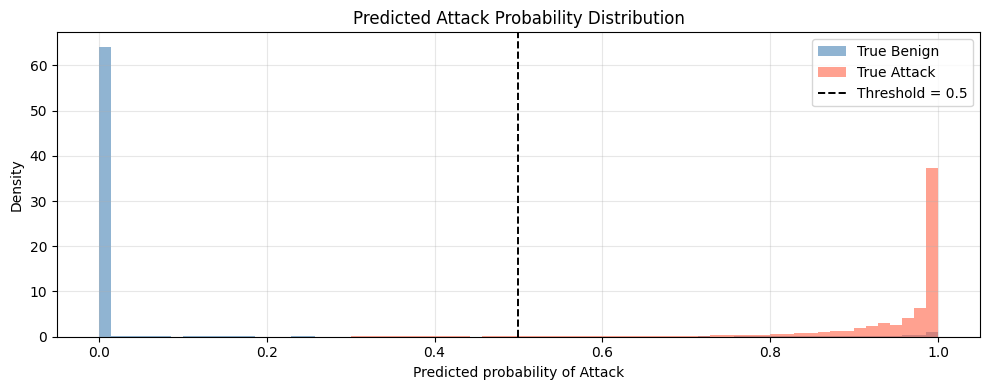

/tmp/ipykernel_12955/2981355808.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette="viridis")


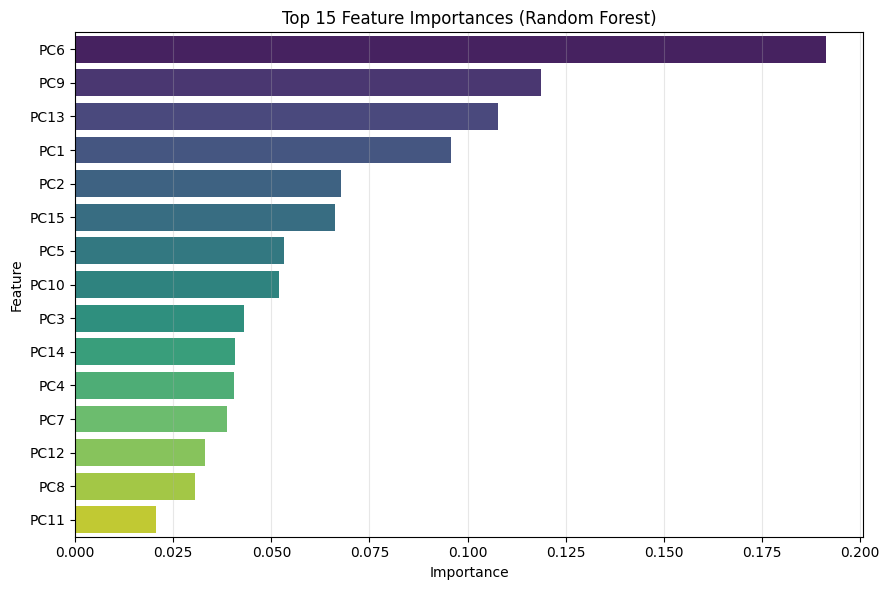


🎉 Done — insights and visualizations generated (no prediction file saved).


In [29]:
# ══════════════════════════════════════════════════════════════════════════
#  CONTINUE FROM SAVED MODEL (NO RETRAIN, NO PREDICTION FILE SAVE)
#  • Loads /content/rf_model.joblib
#  • Predicts full test.csv in chunks
#  • Shows metrics + insights + visualizations
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, time, joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

# ── CONFIG ────────────────────────────────────────────────────────────────
TEST_PATH      = "/content/test.csv"
MODEL_PATH     = "/content/rf_model.joblib"
CHUNK_SIZE     = 20_000
LABEL_COL      = "Label"

# ── LOAD MODEL ────────────────────────────────────────────────────────────
bundle = joblib.load(MODEL_PATH)
rf        = bundle["model"]
le        = bundle["label_encoder"]
FEAT_COLS = bundle["features"]
best_params = bundle.get("best_params", {})

print("✅ Loaded model:", MODEL_PATH)
print("   RF params:", best_params if best_params else "N/A")
print("   Features:", len(FEAT_COLS))

# ── STEP 4: PREDICT FULL TEST (CHUNKED) ──────────────────────────────────
all_y_true, all_y_pred, all_y_prob = [], [], []
chunks_done = 0
rows_done = 0
t0 = time.time()

for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'):
    chunk.columns = chunk.columns.str.strip()
    chunk[LABEL_COL] = chunk[LABEL_COL].astype(str).str.strip()
    chunk = chunk[chunk[LABEL_COL].isin(["Benign", "Attack"])]
    if len(chunk) == 0:
        continue

    X_c = chunk[FEAT_COLS].apply(pd.to_numeric, errors='coerce').astype("float32")
    y_c = le.transform(chunk[LABEL_COL])

    valid = ~X_c.isna().any(axis=1)
    X_c = X_c.loc[valid].values
    y_c = y_c[valid.values]

    if len(X_c) == 0:
        continue

    y_prob = rf.predict_proba(X_c)[:, 1]
    y_pred = (y_prob >= 0.5).astype(np.int32)

    all_y_true.extend(y_c.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_prob.extend(y_prob.tolist())

    rows_done += len(y_c)
    chunks_done += 1
    if chunks_done % 20 == 0:
        print(f"   Chunks predicted: {chunks_done} | Rows: {rows_done:,}")

    del chunk, X_c, y_c, y_pred, y_prob
    gc.collect()

pred_time = time.time() - t0
print(f"\n✅ Prediction complete in {pred_time:.1f}s")
print(f"✅ Total test rows evaluated: {rows_done:,}")

# ── Convert lists -> arrays (fixes NameError) ────────────────────────────
y_true = np.array(all_y_true, dtype=np.int32)
y_pred = np.array(all_y_pred, dtype=np.int32)
y_prob = np.array(all_y_prob, dtype=np.float32)
del all_y_true, all_y_pred, all_y_prob
gc.collect()

# ── STEP 5: METRICS + INSIGHTS ────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_true, y_prob)
cm        = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
fpr_val     = fp / (fp + tn) if (fp + tn) else 0.0

print("\n" + "="*60)
print("📊  RANDOM FOREST — TEST METRICS")
print("="*60)
print(f"Accuracy        : {acc:.6f}")
print(f"Precision       : {precision:.6f}")
print(f"Recall          : {recall:.6f}")
print(f"F1 Score        : {f1:.6f}")
print(f"ROC-AUC         : {roc_auc:.6f}")
print(f"Specificity     : {specificity:.6f}")
print(f"False Pos Rate  : {fpr_val:.6f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

# Insights
print("\n" + "="*60)
print("💡 INSIGHTS")
print("="*60)
print(f"• TN={tn:,}, FP={fp:,}, FN={fn:,}, TP={tp:,}")
print(f"• Attack detection rate (Recall): {recall*100:.3f}%")
print(f"• Benign correctly ignored (Specificity): {specificity*100:.3f}%")
print(f"• False alarms among benign (FPR): {fpr_val*100:.3f}%")
print(f"• If recall >> specificity, model is aggressive toward attack detection.")
print(f"• If specificity >> recall, model is conservative (fewer false alarms).")

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1","ROC-AUC","Specificity","FPR"],
    "Value": [acc, precision, recall, f1, roc_auc, specificity, fpr_val]
})
display(metrics_df)

# ── VISUALIZATIONS ────────────────────────────────────────────────────────
# 1) Confusion Matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = [f"{v:,}\n({p:.2f}%)" for v, p in zip(cm.ravel(), cm_pct.ravel())]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(cm_pct, annot=labels, fmt="", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.6, ax=axes[0], cbar_kws={"label": "% of true class"})
axes[0].set_title("Confusion Matrix (row-normalized %)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr_arr, tpr_arr, lw=2, color="steelblue", label=f"RF (AUC={roc_auc:.4f})")
axes[1].plot([0,1], [0,1], "k--", lw=1, label="Random")
axes[1].fill_between(fpr_arr, tpr_arr, alpha=0.12, color="steelblue")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Probability distribution
plt.figure(figsize=(10, 4))
plt.hist(y_prob[y_true == 0], bins=70, alpha=0.60, density=True, label="True Benign", color="steelblue")
plt.hist(y_prob[y_true == 1], bins=70, alpha=0.60, density=True, label="True Attack", color="tomato")
plt.axvline(0.5, color="black", linestyle="--", linewidth=1.4, label="Threshold = 0.5")
plt.title("Predicted Attack Probability Distribution")
plt.xlabel("Predicted probability of Attack")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Feature Importance (top 15)
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:15]
top_features = [FEAT_COLS[i] for i in idx]
top_importances = importances[idx]

plt.figure(figsize=(9, 6))
sns.barplot(x=top_importances, y=top_features, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 Done — insights and visualizations generated (no prediction file saved).")

In [28]:
# =========================================================
# COPY MODEL FILE RESULTS TO DRIVE
# =========================================================

# from google.colab import drive
# drive.mount('/content/drive')

DEST = "/content/drive/MyDrive/FDS_CIC-dataset-2018/rf_model"

!cp -r /content/rf_model.joblib "$DEST"

print("✅ Results copied to Drive:", DEST)

✅ Results copied to Drive: /content/drive/MyDrive/FDS_CIC-dataset-2018/rf_model


# **MODEL COMPARISON — KNN vs LOGISTIC REGRESSION vs RANDOM FOREST**


📦  STEP 1: Loading saved models
   ✅  KNN                    loaded  (38.6 MB)  →  /content/knn_model.joblib
   ✅  Logistic Regression    loaded  (0.0 MB)  →  /content/logreg_sgd_full.joblib
   ✅  Random Forest          loaded  (1720.6 MB)  →  /content/rf_model.joblib

   Feature columns : 15
   Label classes   : ['Attack' 'Benign']

🔮  STEP 2: Generating predictions on full test set

   Predicting with KNN...
      ✅  Done in 919.7s  |  Total rows: 776,528

   Predicting with Logistic Regression...
      ✅  Done in 12.0s  |  Total rows: 776,528

   Predicting with Random Forest...
      ✅  Done in 78.4s  |  Total rows: 776,528

📐  STEP 3: Computing metrics

  ── KNN ──
              precision    recall  f1-score   support

      Attack       0.91      0.24      0.38    388285
      Benign       0.56      0.98      0.71    388243

    accuracy                           0.61    776528
   macro avg       0.74      0.61      0.55    776528
weighted avg       0.74      0.61      0.55    77

,Metric,KNN,Logistic Regression,Random Forest
0,Accuracy,0.6084,0.4999,0.9599
1,Precision,0.5624,0.3963,0.9433
2,Recall,0.9767,0.0003,0.9785
3,F1 Score,0.7138,0.0007,0.9606
4,ROC-AUC,0.6386,0.4781,0.9798
5,Avg Precision,0.5809,0.4823,0.9662
6,Specificity,0.2402,0.9995,0.9412
7,False Pos. Rate,0.7598,0.0005,0.0588
8,False Neg. Rate,0.0233,0.9997,0.0215
9,Predict Time (s),919.7500,11.9800,78.4300



🎨  STEP 4: Generating visualizations


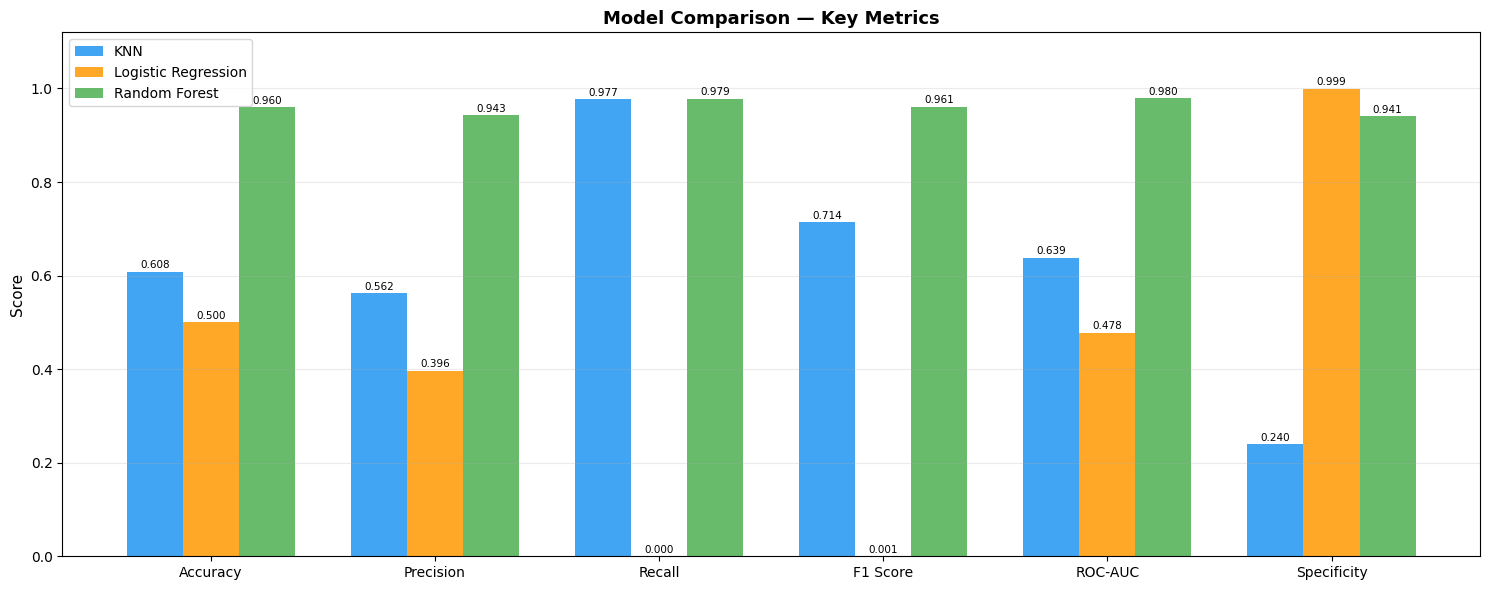

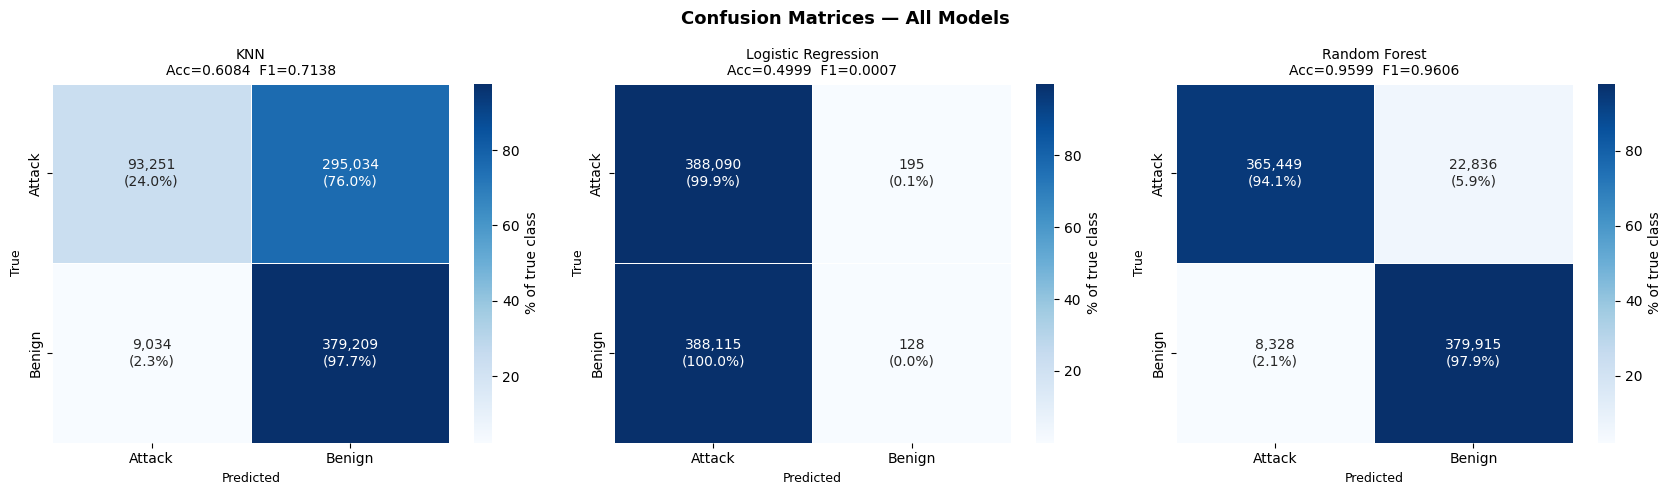

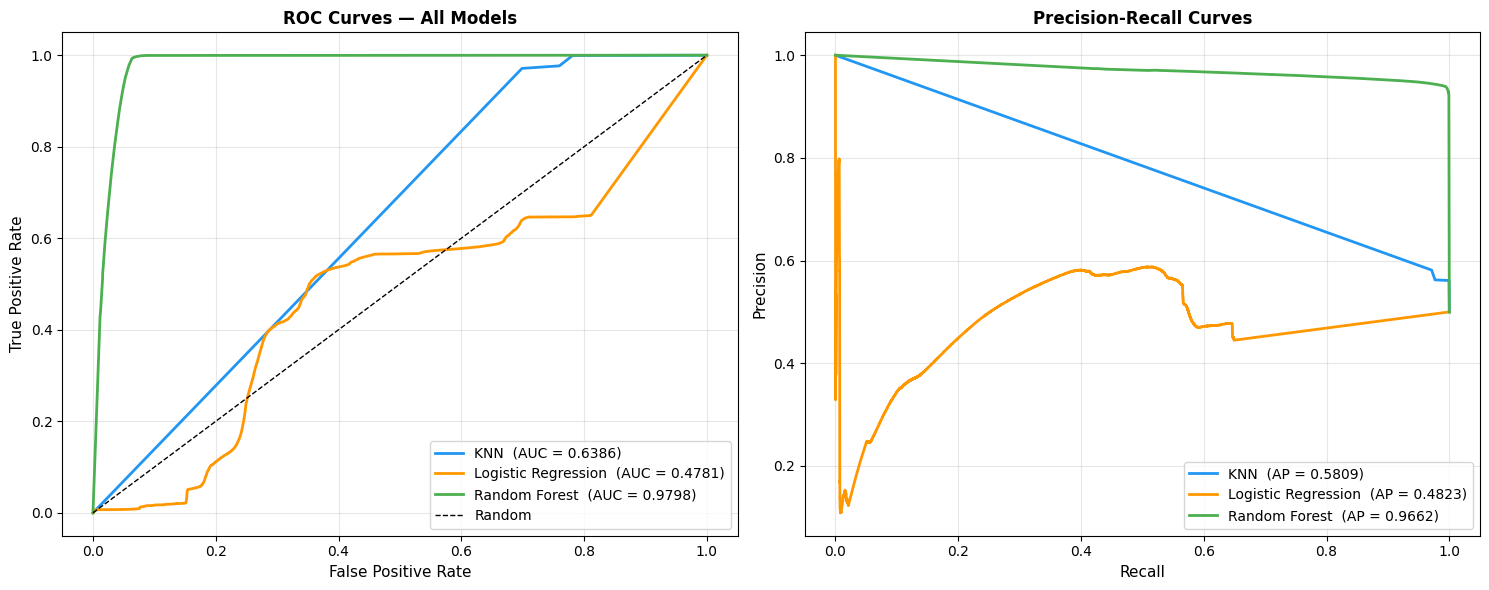

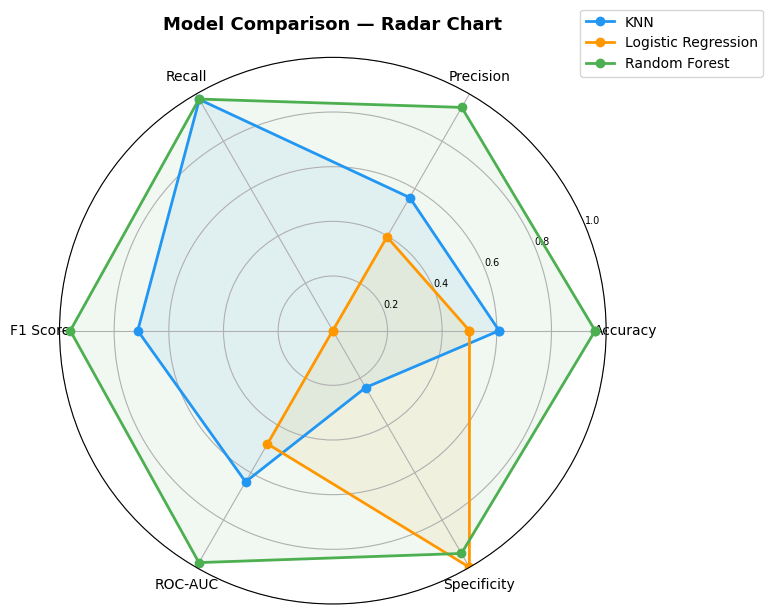

/tmp/ipykernel_12955/1421604641.py:337: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


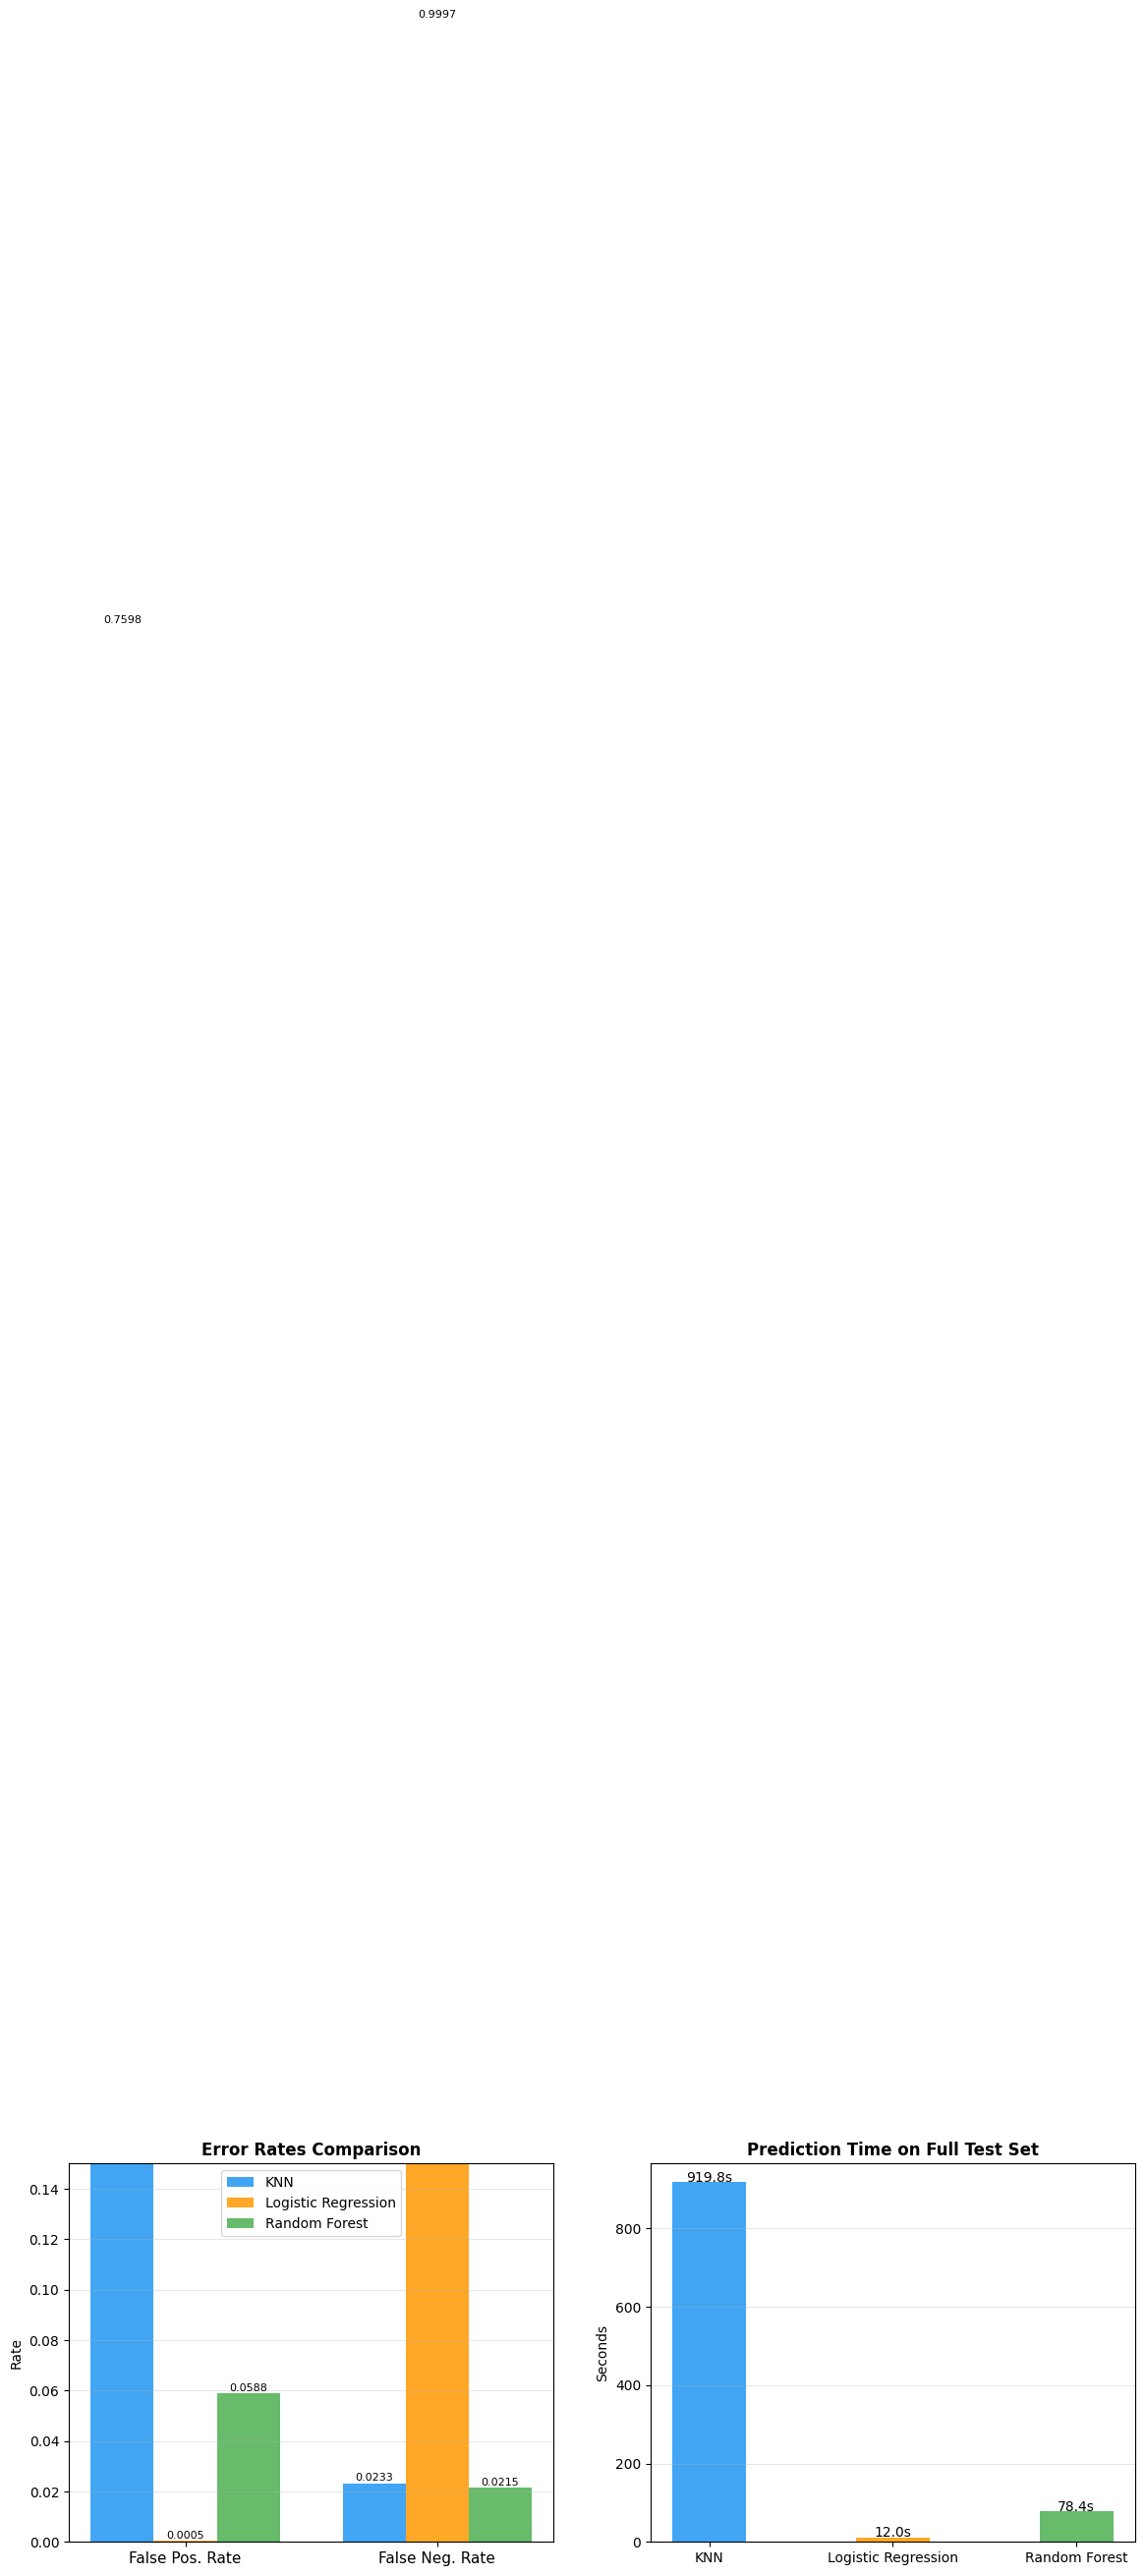

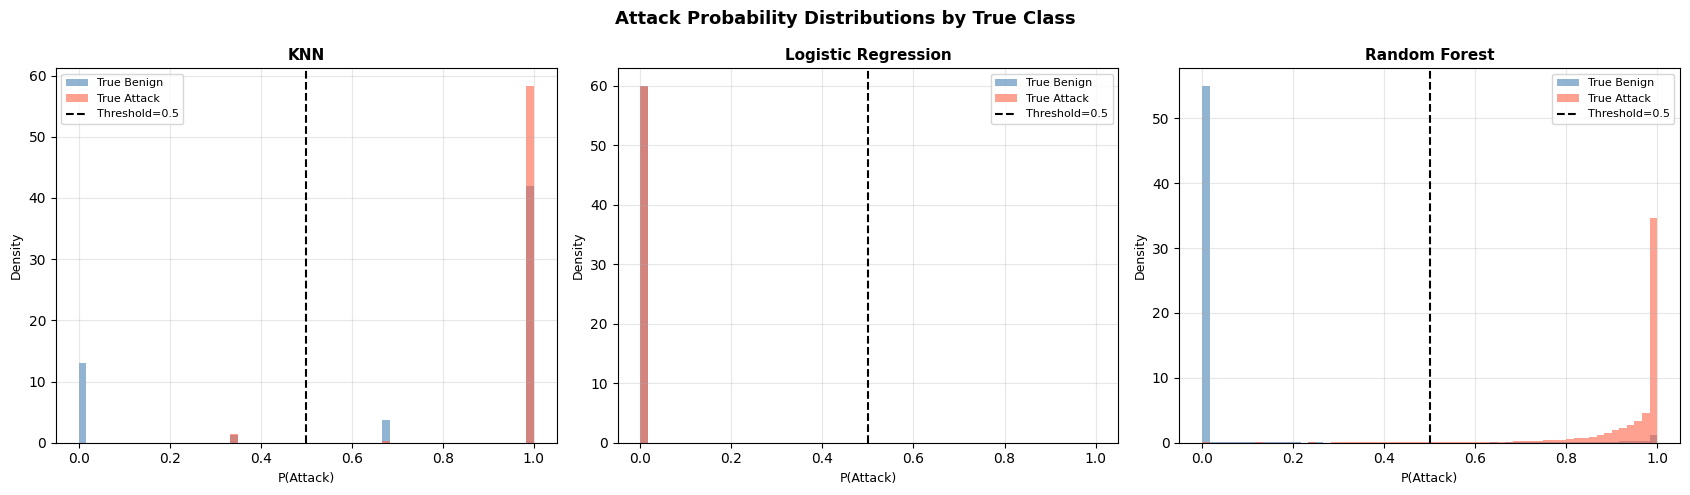

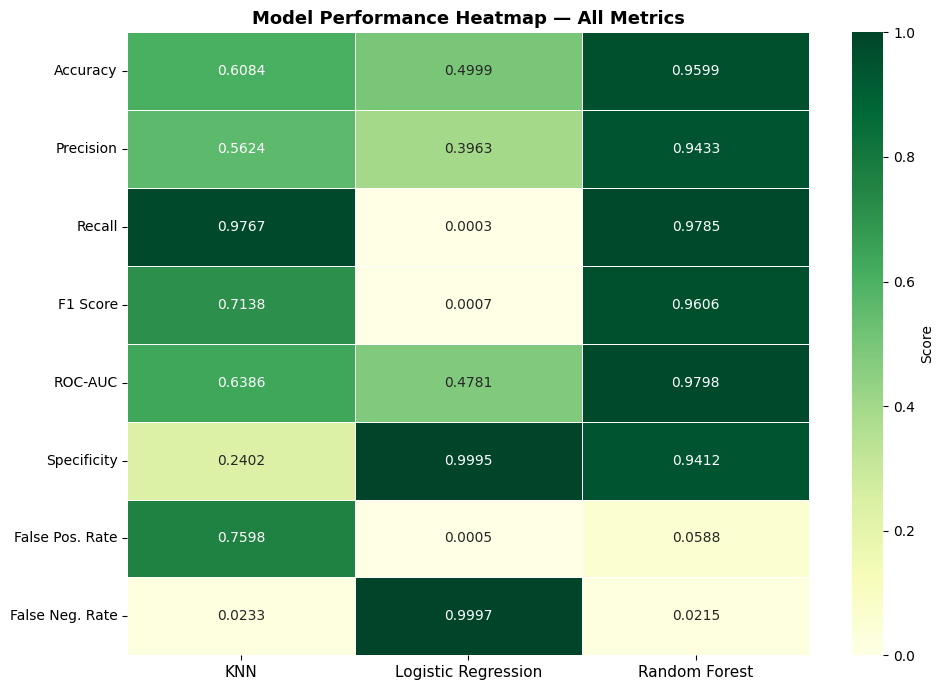


🏆  STEP 5: Model Ranking

  Ranked by sum of (Accuracy + F1 + ROC-AUC + Precision + Recall):

  🥇  #1  Random Forest             combined score = 4.8221
          Accuracy             : 0.9599
          F1 Score             : 0.9606
          ROC-AUC              : 0.9798
          Precision            : 0.9433
          Recall               : 0.9785

  🥈  #2  KNN                       combined score = 3.5000
          Accuracy             : 0.6084
          F1 Score             : 0.7138
          ROC-AUC              : 0.6386
          Precision            : 0.5624
          Recall               : 0.9767

  🥉  #3  Logistic Regression       combined score = 1.3754
          Accuracy             : 0.4999
          F1 Score             : 0.0007
          ROC-AUC              : 0.4781
          Precision            : 0.3963
          Recall               : 0.0003

  ✅  Best overall model: Random Forest
      F1    = 0.9606
      AUC   = 0.9798
      Acc   = 0.9599

🎉  Model comparison co

In [30]:
# ══════════════════════════════════════════════════════════════════════════
#  MODEL COMPARISON — KNN vs LOGISTIC REGRESSION vs RANDOM FOREST
#  Loads all 3 saved models, evaluates on full test.csv, compares results
#  with comprehensive visualizations
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os, gc, time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from collections import defaultdict

import joblib
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder

# ── CONFIG ────────────────────────────────────────────────────────────────
TEST_PATH   = "/content/test.csv"
CHUNK_SIZE  = 15_000
LABEL_COL   = "Label"

MODEL_FILES = {
    "KNN"                 : "/content/knn_model.joblib",
    "Logistic Regression" : "/content/logreg_sgd_full.joblib",
    "Random Forest"       : "/content/rf_model.joblib",
}

COLORS = {
    "KNN"                 : "#2196F3",
    "Logistic Regression" : "#FF9800",
    "Random Forest"       : "#4CAF50",
}

# ══════════════════════════════════════════════════════════════════════════
#  STEP 1 — LOAD ALL MODELS
# ══════════════════════════════════════════════════════════════════════════
print("="*60)
print("📦  STEP 1: Loading saved models")
print("="*60)

models     = {}
feat_cols  = None
le         = None

for name, path in MODEL_FILES.items():
    bundle = joblib.load(path)
    models[name] = bundle
    # Extract feature list and label encoder from any model that has them
    if feat_cols is None and "features" in bundle:
        feat_cols = bundle["features"]
    if le is None and "label_encoder" in bundle:
        le = bundle["label_encoder"]
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"   ✅  {name:<22} loaded  ({size_mb:.1f} MB)  →  {path}")

# Fallback label encoder if none stored
if le is None:
    le = LabelEncoder()
    le.fit(["Benign", "Attack"])

print(f"\n   Feature columns : {len(feat_cols)}")
print(f"   Label classes   : {le.classes_}")

# ── Helper: extract sklearn estimator from any bundle format ──────────────
def get_estimator(bundle):
    for key in ["model", "estimator", "classifier"]:
        if key in bundle:
            return bundle[key]
    # if bundle IS the model directly
    if hasattr(bundle, "predict"):
        return bundle
    raise ValueError(f"Cannot find estimator in bundle keys: {list(bundle.keys())}")

# ══════════════════════════════════════════════════════════════════════════
#  STEP 2 — PREDICT ON FULL TEST SET FOR EACH MODEL (chunked)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔮  STEP 2: Generating predictions on full test set")
print("="*60)

results = {}   # name → {y_true, y_pred, y_prob, time}

for name, bundle in models.items():
    print(f"\n   Predicting with {name}...")
    clf        = get_estimator(bundle)
    y_true_all = []
    y_pred_all = []
    y_prob_all = []
    chunks_done = 0
    t0          = time.time()

    for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNK_SIZE,
                             low_memory=False, on_bad_lines='skip'):
        chunk.columns = chunk.columns.str.strip()

        X_c = chunk[feat_cols].apply(pd.to_numeric, errors='coerce').astype("float32").values
        y_c = le.transform(chunk[LABEL_COL].astype(str).str.strip())

        valid = ~np.isnan(X_c).any(axis=1)
        X_c   = X_c[valid]
        y_c   = y_c[valid]
        if len(X_c) == 0:
            del chunk; continue

        y_pred = clf.predict(X_c)

        # Get probabilities (handles models that use predict_proba or decision_function)
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_c)[:, 1]
        elif hasattr(clf, "decision_function"):
            df_scores = clf.decision_function(X_c)
            # Sigmoid to convert to [0,1]
            y_prob = 1 / (1 + np.exp(-df_scores))
        else:
            y_prob = y_pred.astype(float)

        y_true_all.extend(y_c.tolist())
        y_pred_all.extend(y_pred.tolist())
        y_prob_all.extend(y_prob.tolist())

        chunks_done += 1
        if chunks_done % 100 == 0:
            print(f"      Chunks: {chunks_done}  |  Rows: {len(y_true_all):,}")

        del chunk, X_c, y_c, y_pred, y_prob; gc.collect()

    elapsed = time.time() - t0
    results[name] = {
        "y_true" : np.array(y_true_all),
        "y_pred" : np.array(y_pred_all),
        "y_prob" : np.array(y_prob_all),
        "time"   : elapsed,
    }
    print(f"      ✅  Done in {elapsed:.1f}s  |  Total rows: {len(y_true_all):,}")
    del y_true_all, y_pred_all, y_prob_all; gc.collect()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 3 — COMPUTE ALL METRICS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📐  STEP 3: Computing metrics")
print("="*60)

metrics_all = {}

for name, r in results.items():
    yt, yp, yb = r["y_true"], r["y_pred"], r["y_prob"]
    cm          = confusion_matrix(yt, yp)
    tn, fp, fn, tp_val = cm.ravel()

    metrics_all[name] = {
        "Accuracy"          : accuracy_score(yt, yp),
        "Precision"         : precision_score(yt, yp, zero_division=0),
        "Recall"            : recall_score(yt, yp, zero_division=0),
        "F1 Score"          : f1_score(yt, yp, zero_division=0),
        "ROC-AUC"           : roc_auc_score(yt, yb),
        "Avg Precision"     : average_precision_score(yt, yb),
        "Specificity"       : tn / (tn + fp) if (tn+fp) > 0 else 0,
        "False Pos. Rate"   : fp / (fp + tn) if (fp+tn) > 0 else 0,
        "False Neg. Rate"   : fn / (fn + tp_val) if (fn+tp_val) > 0 else 0,
        "Predict Time (s)"  : round(r["time"], 2),
        "confusion_matrix"  : cm,
    }

# Print per-model classification report
for name, r in results.items():
    print(f"\n  ── {name} ──")
    print(classification_report(r["y_true"], r["y_pred"],
          target_names=le.classes_))

# ── Metrics summary table ─────────────────────────────────────────────────
DISPLAY_METRICS = ["Accuracy","Precision","Recall","F1 Score",
                   "ROC-AUC","Avg Precision","Specificity",
                   "False Pos. Rate","False Neg. Rate","Predict Time (s)"]

table_data = {"Metric": DISPLAY_METRICS}
for name in models:
    table_data[name] = [
        f"{metrics_all[name][m]:.4f}" if isinstance(metrics_all[name][m], float)
        else str(metrics_all[name][m])
        for m in DISPLAY_METRICS
    ]

summary_df = pd.DataFrame(table_data)
print("\n  📋  Full Metrics Comparison:")
display(summary_df)

# ══════════════════════════════════════════════════════════════════════════
#  STEP 4 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🎨  STEP 4: Generating visualizations")
print("="*60)

model_names = list(models.keys())

# ── VIZ 1: Metrics bar chart comparison ───────────────────────────────────
plot_metrics = ["Accuracy","Precision","Recall","F1 Score","ROC-AUC","Specificity"]
x      = np.arange(len(plot_metrics))
width  = 0.25
fig, ax = plt.subplots(figsize=(15, 6))

for i, name in enumerate(model_names):
    vals = [metrics_all[name][m] for m in plot_metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=name, color=COLORS[name], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{v:.3f}", ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("Model Comparison — Key Metrics", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

# ── VIZ 2: Confusion matrices (3 side by side) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, name in zip(axes, model_names):
    cm       = metrics_all[name]["confusion_matrix"]
    cm_pct   = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot    = np.array([f"{v:,}\n({p:.1f}%)"
                         for v, p in zip(cm.ravel(), cm_pct.ravel())]).reshape(2,2)
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, ax=ax,
                cbar_kws={"label": "% of true class"})
    acc = metrics_all[name]["Accuracy"]
    f1  = metrics_all[name]["F1 Score"]
    ax.set_title(f"{name}\nAcc={acc:.4f}  F1={f1:.4f}", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True",      fontsize=9)

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── VIZ 3: ROC curves (all on one plot) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name in model_names:
    r         = results[name]
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    auc       = metrics_all[name]["ROC-AUC"]
    axes[0].plot(fpr, tpr, color=COLORS[name], lw=2,
                 label=f"{name}  (AUC = {auc:.4f})")

axes[0].plot([0,1],[0,1],'k--',lw=1,label="Random")
axes[0].fill_between([], [], alpha=0)
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate",  fontsize=11)
axes[0].set_title("ROC Curves — All Models", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# ── VIZ 4: Precision-Recall curves ────────────────────────────────────────
for name in model_names:
    r           = results[name]
    prec, rec, _ = precision_recall_curve(r["y_true"], r["y_prob"])
    ap          = metrics_all[name]["Avg Precision"]
    axes[1].plot(rec, prec, color=COLORS[name], lw=2,
                 label=f"{name}  (AP = {ap:.4f})")

axes[1].set_xlabel("Recall",    fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── VIZ 5: Radar / spider chart ───────────────────────────────────────────
radar_metrics = ["Accuracy","Precision","Recall","F1 Score",
                 "ROC-AUC","Specificity"]
N     = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw=dict(polar=True))

for name in model_names:
    vals = [metrics_all[name][m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=COLORS[name], label=name)
    ax.fill(angles, vals, alpha=0.08, color=COLORS[name])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=7)
ax.set_title("Model Comparison — Radar Chart",
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout(); plt.show()

# ── VIZ 6: Error rates comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_metrics = ["False Pos. Rate", "False Neg. Rate"]
x = np.arange(len(error_metrics)); width = 0.25

for i, name in enumerate(model_names):
    vals = [metrics_all[name][m] for m in error_metrics]
    bars = axes[0].bar(x + i*width, vals, width,
                       label=name, color=COLORS[name], alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f"{v:.4f}", ha='center', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(error_metrics, fontsize=11)
axes[0].set_ylabel("Rate"); axes[0].set_ylim(0, 0.15)
axes[0].set_title("Error Rates Comparison", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')

# Prediction time comparison
times = [metrics_all[n]["Predict Time (s)"] for n in model_names]
bar_c = [COLORS[n] for n in model_names]
bars  = axes[1].bar(model_names, times, color=bar_c, alpha=0.85, width=0.4)
for bar, v in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{v:.1f}s", ha='center', fontsize=10)
axes[1].set_ylabel("Seconds")
axes[1].set_title("Prediction Time on Full Test Set",
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ── VIZ 7: Probability distribution per model ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, name in zip(axes, model_names):
    r  = results[name]
    yt = r["y_true"]
    yb = r["y_prob"]
    ax.hist(yb[yt==0], bins=60, alpha=0.6,
            color='steelblue', label='True Benign', density=True)
    ax.hist(yb[yt==1], bins=60, alpha=0.6,
            color='tomato',    label='True Attack',  density=True)
    ax.axvline(x=0.5, color='black', linestyle='--',
               linewidth=1.5, label='Threshold=0.5')
    ax.set_xlabel("P(Attack)", fontsize=9)
    ax.set_ylabel("Density",   fontsize=9)
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Attack Probability Distributions by True Class",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── VIZ 8: Final summary heatmap ──────────────────────────────────────────
heat_metrics = ["Accuracy","Precision","Recall","F1 Score",
                "ROC-AUC","Specificity","False Pos. Rate","False Neg. Rate"]

heat_data = pd.DataFrame(
    [[metrics_all[n][m] for n in model_names] for m in heat_metrics],
    index=heat_metrics,
    columns=model_names
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Score"},
            vmin=0, vmax=1)
ax.set_title("Model Performance Heatmap — All Metrics",
             fontsize=13, fontweight='bold')
ax.set_xticklabels(model_names, fontsize=11)
ax.set_yticklabels(heat_metrics, rotation=0, fontsize=10)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  STEP 5 — WINNER SUMMARY
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏆  STEP 5: Model Ranking")
print("="*60)

rank_metrics = ["Accuracy","F1 Score","ROC-AUC","Precision","Recall"]
scores_sum   = {n: sum(metrics_all[n][m] for m in rank_metrics)
                for n in model_names}
ranked       = sorted(scores_sum.items(), key=lambda x: -x[1])

print(f"\n  Ranked by sum of (Accuracy + F1 + ROC-AUC + Precision + Recall):\n")
for rank, (name, score) in enumerate(ranked, 1):
    medal = ["🥇","🥈","🥉"][rank-1]
    print(f"  {medal}  #{rank}  {name:<24}  combined score = {score:.4f}")
    for m in rank_metrics:
        print(f"          {m:<20} : {metrics_all[name][m]:.4f}")
    print()

best_model = ranked[0][0]
print(f"  ✅  Best overall model: {best_model}")
print(f"      F1    = {metrics_all[best_model]['F1 Score']:.4f}")
print(f"      AUC   = {metrics_all[best_model]['ROC-AUC']:.4f}")
print(f"      Acc   = {metrics_all[best_model]['Accuracy']:.4f}")

print("\n🎉  Model comparison complete!")